# Results

# Intermediate trials

## SC Trials 03/02-12/02 (`data/sanity_checks`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/complete_physics4/model_1.008e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.687880039215088, -2....",0.023147,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.405747413635254, 1.69102...",0.002726,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.658685445785522, -1.9...",0.004142,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.621750831604003, -1....",0.039594,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.426576972007751, 1.1514...",0.002743,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480870962142944, 2.8691...",0.012223,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6037119626998901, -1....",0.003548,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.710173368453979, 2.2700...",0.021869,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.542604684829712, -2....",0.054782,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.495648145675659, -1.6...",0.002041,0.0


In [2]:
# physics only 
import jax.numpy as jnp
from networks import DampedPendulumParamPDE
from forecasters import Forecaster
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")


In [3]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


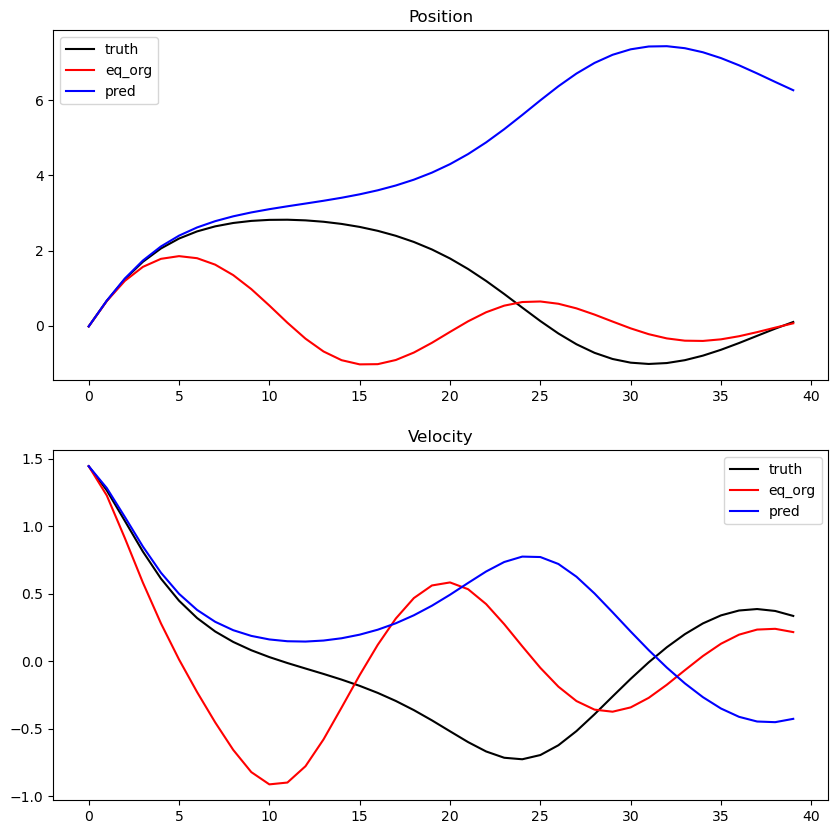

In [4]:
plot_trajectory(12)

[0.52782559 1.32926977]
(1, 2, 40)


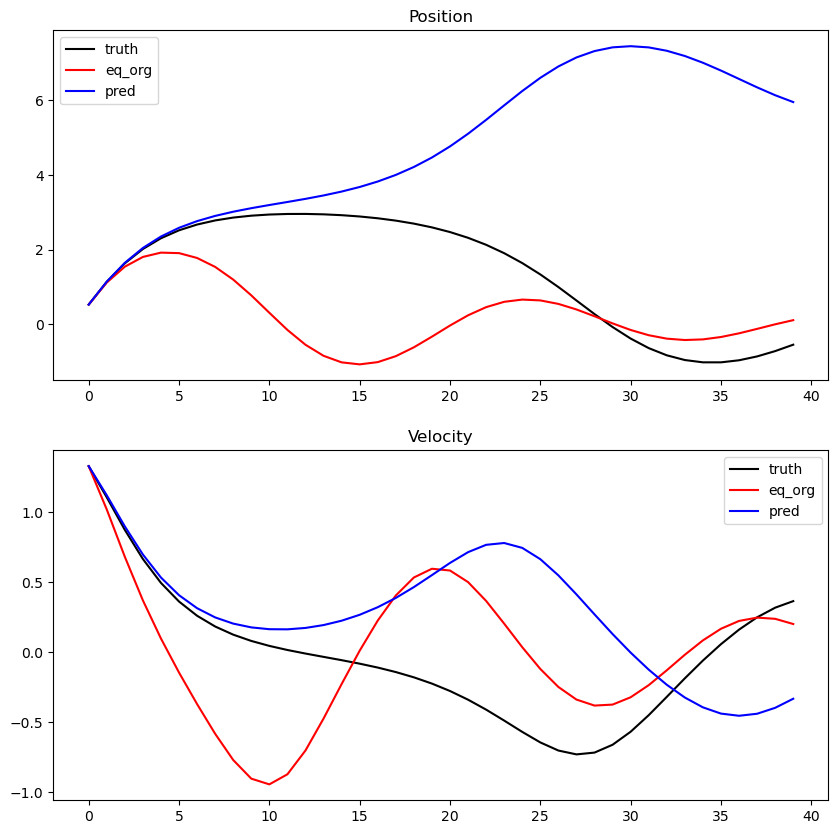

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 40)


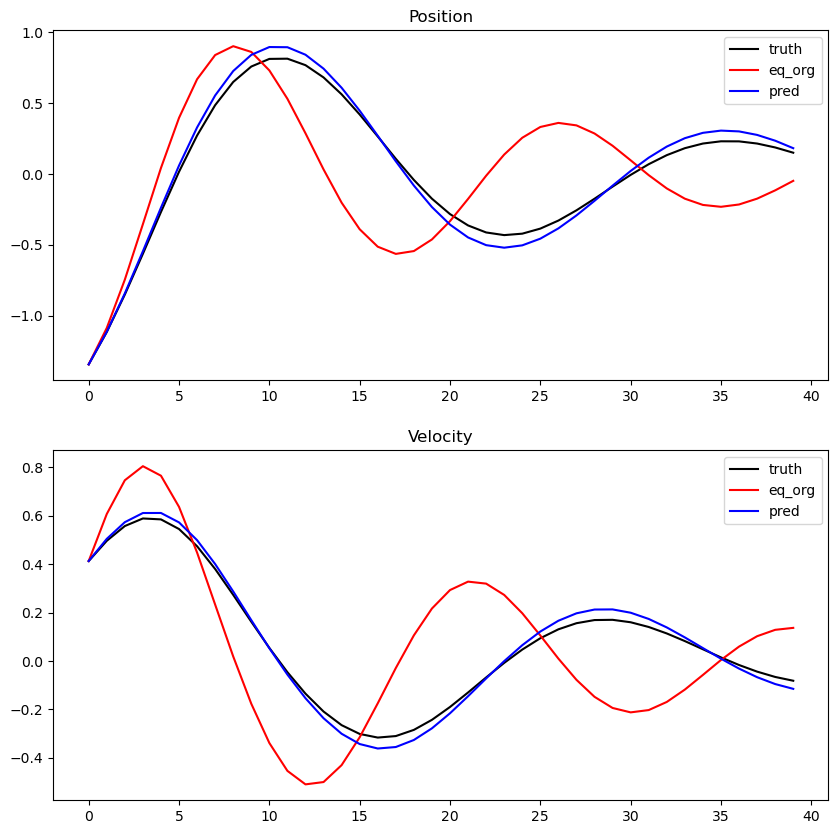

In [6]:
plot_trajectory(24)

In [10]:
import matplotlib.pyplot as plt
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/incomplete_aug3/model_1.508e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.626970410346984, -2....",0.211602,0.002573
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.424392223358154, 1.74875...",0.378943,0.001084
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.628757238388061, -1.9...",0.237589,0.001309
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.6408729553222651, -1...",0.143368,0.002837
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.430660128593444, 1.1600...",0.170913,0.000969
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.480446577072143, 2.8727...",0.112306,0.000886
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.574680805206298, -1.8...",0.24868,0.001296
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.737329006195068, 2.3514...",0.099819,0.000981
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.492254257202148, -2....",0.204859,0.002653
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.48915433883667, -1.61...",0.217697,0.001045


In [11]:
model_phy = DampedPendulumParamPDE(is_complete=False, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [12]:
import jax.numpy as jnp 
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


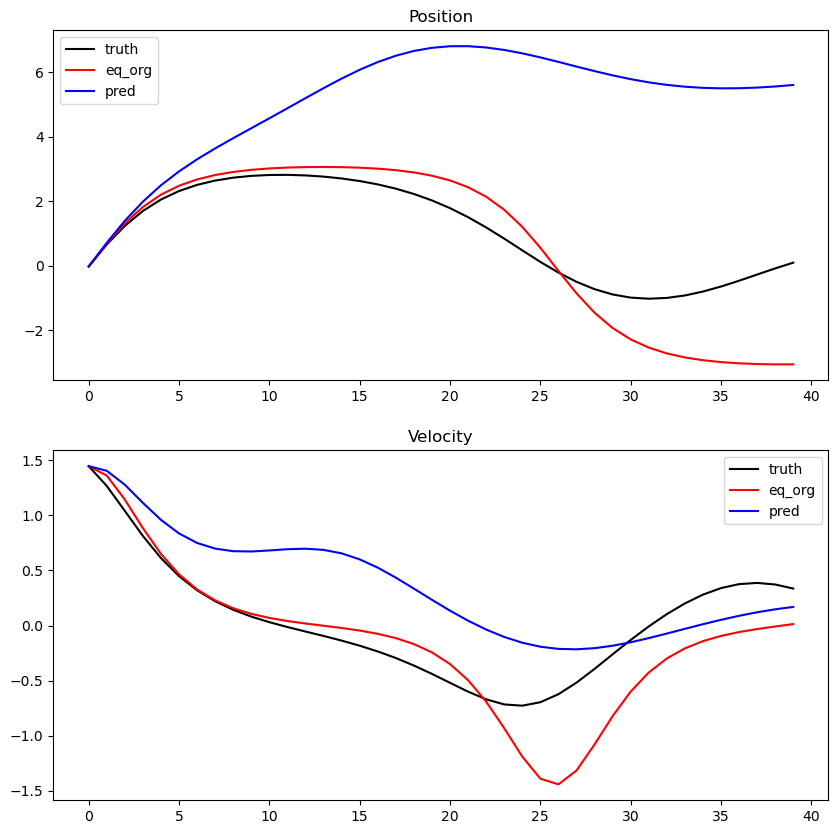

In [13]:
plot_trajectory(12)

[0.52782559 1.32926977]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


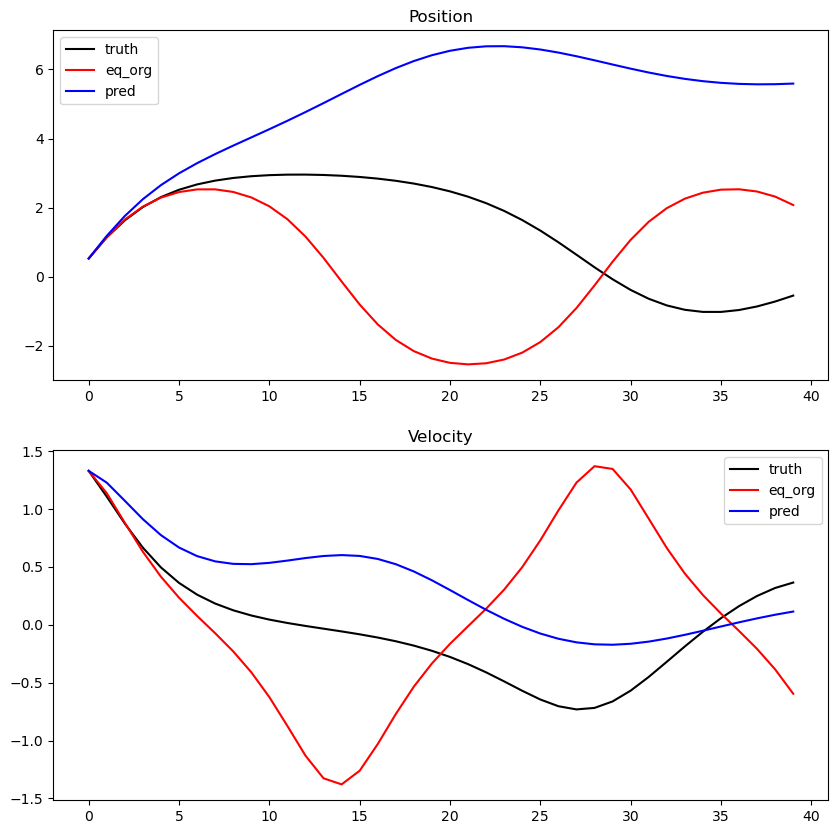

In [14]:
plot_trajectory(22)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


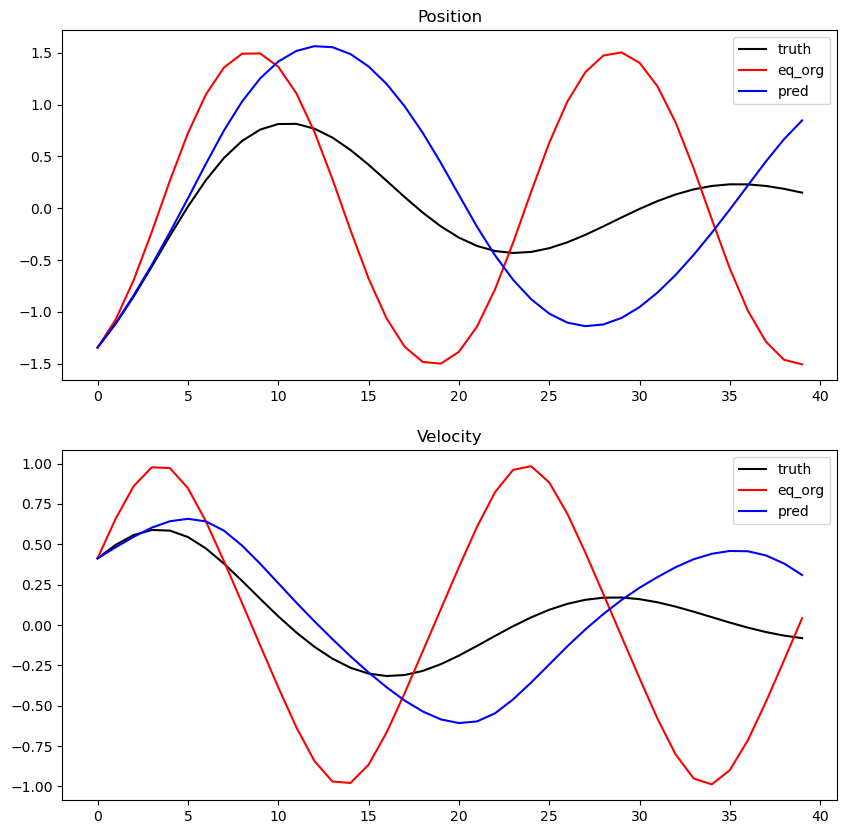

In [15]:
plot_trajectory(24)

### None aug5


In [16]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug5/model_1.006e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6181092262268062, -2...",0.18581,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.340431213378906, 1.58105...",0.101088,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.637307405471801, -1.9...",0.098446,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.559412360191345, -1....",0.156073,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.369356155395507, 1.0821...",0.047644,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.45348310470581, 2.84081...",0.09176,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.582802057266235, -1.8...",0.092699,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.651341915130615, 2.2217...",0.062379,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.469146966934204, -2....",0.25517,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.483283877372741, -1.5...",0.04442,0.0


In [17]:
model_phy = DampedPendulumParamPDE(is_complete=True, real_params={"omega0_square": 2*jnp.pi/12, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete", method="RK4")

In [18]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = net_phy(np.array([results["states"][index]]), jnp.arange(0,20,0.5)) 
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


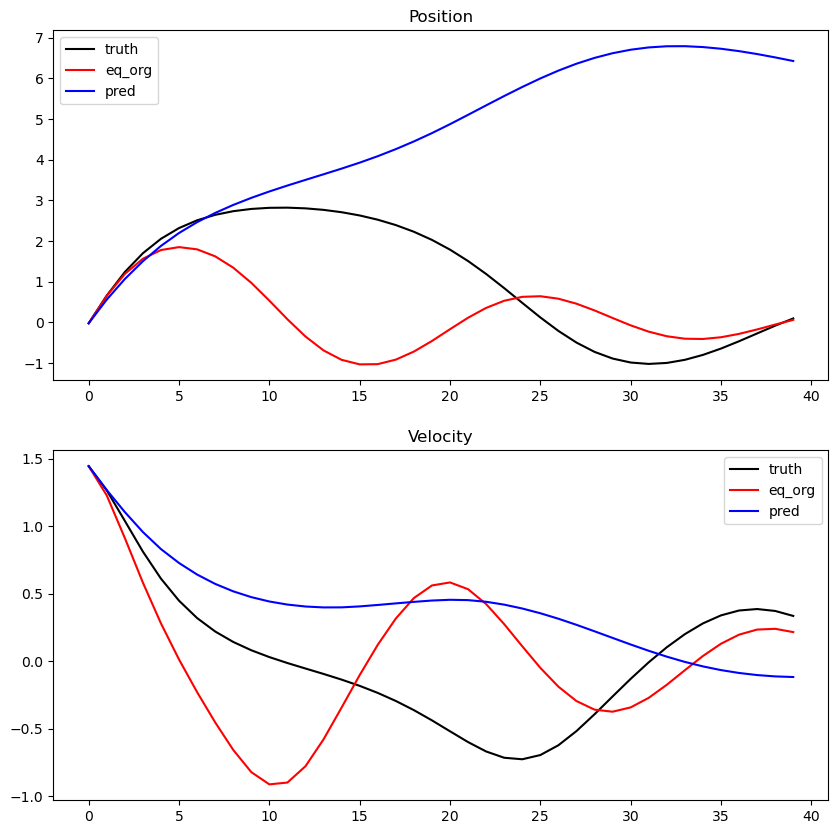

In [19]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


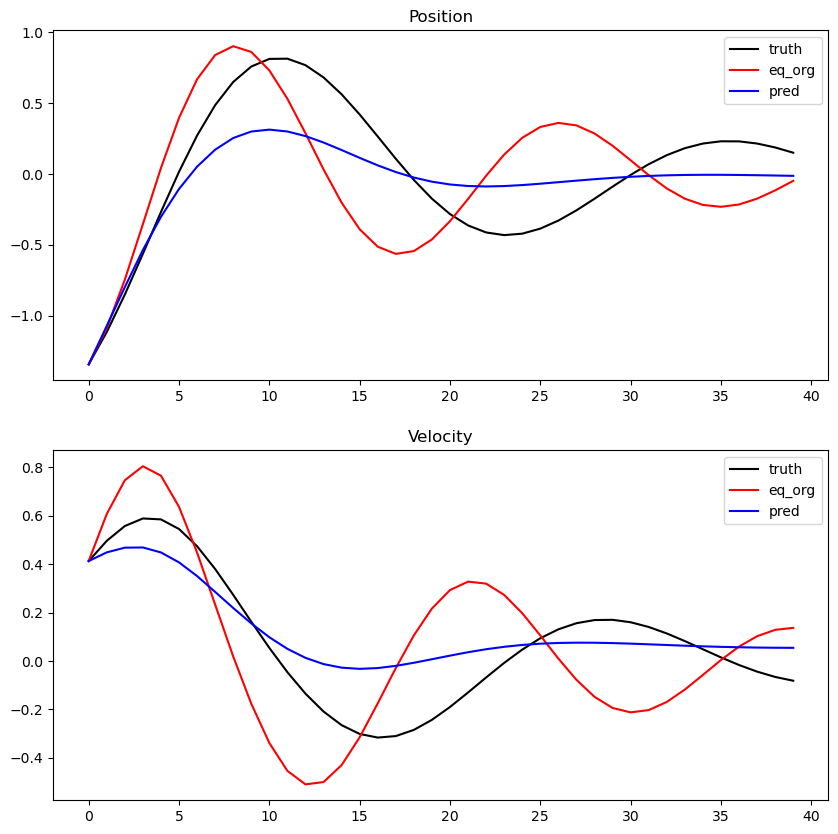

In [20]:
plot_trajectory(24)

### none aug6 

In [22]:
results_pth = "/Users/mayajanvier/jax-phynity/data/sanity_checks/none_aug6/model_1.784e+00..json"
results = pd.read_json(results_pth).T
results

,states,pred,loss_val,loss_op
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.545371651649475, -2....",0.423295,0.0
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.3244702816009521, 1.6016...",1.66484,0.0
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.612063407897949, -1.9...",1.102503,0.0
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.47063967585563604, -...",0.314862,0.0
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.383215904235839, 1.1161...",0.088045,0.0
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.423594713211059, 2.8058...",0.327988,0.0
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.557781219482421, -1.8...",1.027345,0.0
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.577638626098632, 2.1117...",0.171073,0.0
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.380985379219055, -2....",0.483737,0.0
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.486307859420776, -1.6...",0.317323,0.0


[-0.02109816  1.44624829]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


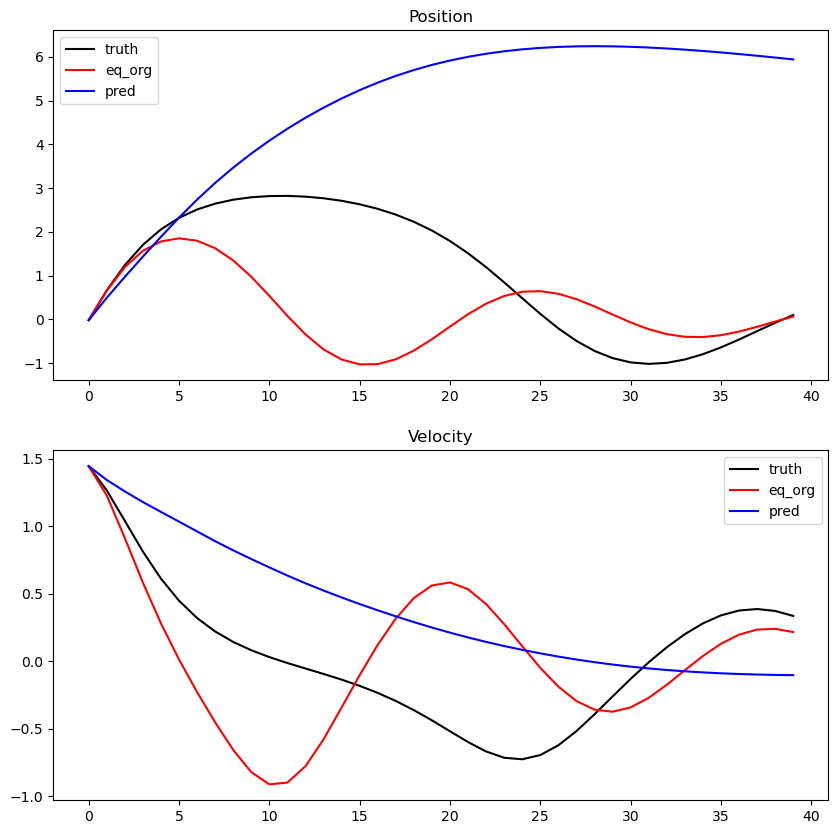

In [24]:
plot_trajectory(12)

[-1.34345663  0.41287747]


/Users/mayajanvier/jax-phynity/solvers/runge_kutta.py:358: UserWarning: Explicitly requested dtype float64 requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  y = jnp.zeros((len(t_eval),) + y0.shape, dtype=y0.dtype)


(1, 2, 40)


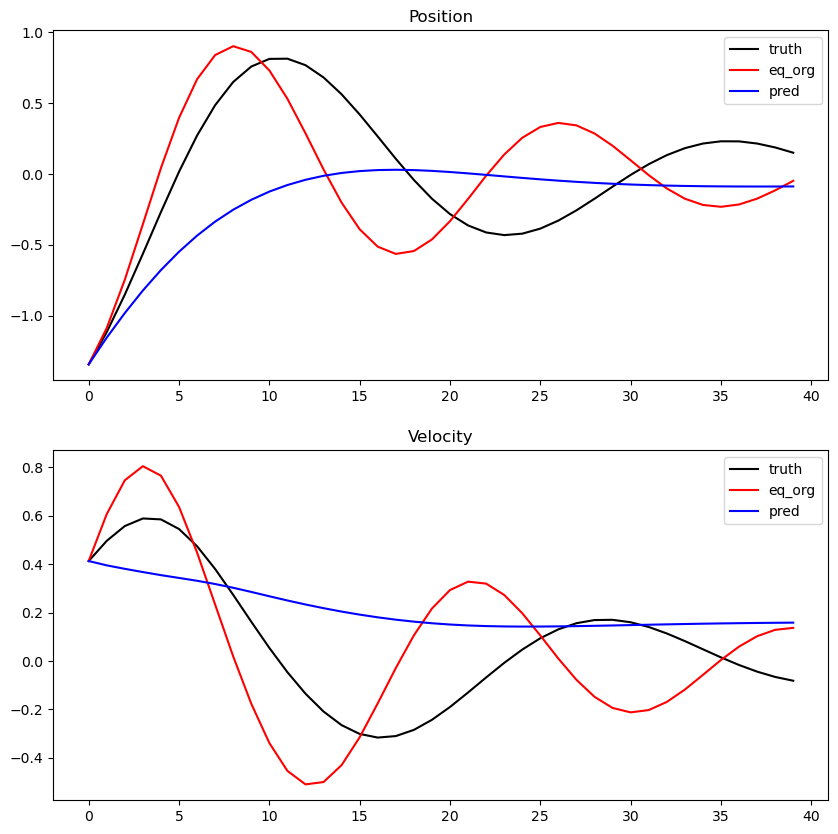

In [25]:
plot_trajectory(24)

## SC Trials debug (`data/tests`)

### None 11

In [20]:
import pandas as pd
results_pth = "/Users/mayajanvier/jax-phynity/data/tests/none_aug_9_se3z528o/model_1.422e-02..json"
results = pd.read_json(results_pth).T
results

ValueError: Trailing data

In [2]:
from networks import PendulumParamPDE
from forecasters import *
model_phy = PendulumParamPDE(is_damped=True, params={"omega0_square": (2*jnp.pi/12)**2, "alpha":0.2})
net_phy = Forecaster(model_phy=model_phy, model_aug=None, is_augmented=False, is_phy="complete",dt=0.5, num_steps=40, integration_method="RK4")

In [3]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
import numpy as np


In [4]:
def plot_trajectory(index):
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    y0 = np.array(results["states"][index])[:,0]
    print(y0)
    phy_out = jax.vmap(net_phy)(np.array([results["states"][index]])[:,:,0])
    print(phy_out.shape)

    ax[0].set_title("Position") 
    ax[0].plot(np.array(results["states"][index][0]), label="truth", color="black")
    ax[0].plot(np.array(phy_out[0,0,:]), label="eq_org", color="red")
    ax[0].plot(np.array(results["pred"][index][0]), label="pred", color="blue")
    ax[0].legend()

    ax[1].set_title("Velocity")
    ax[1].plot(np.array(results["states"][index][1]), label="truth", color="black")
    ax[1].plot(np.array(phy_out[0,1,:]), label="eq_org", color="red")
    ax[1].plot(np.array(results["pred"][index][1]), label="pred", color="blue")
    ax[1].legend()
    plt.show()

In [9]:
phy_out = jax.vmap(net_phy)(np.array([results["states"][1]])[:,:,0])
(np.array(results["states"][1][1]) - np.array(phy_out[0,1,:])).mean()

1.9989363480438227e-09

In [10]:
phy_out2 =jax.vmap(net_phy)(np.array([results["states"][1]])[:,:,0])
(np.array(phy_out[0,1,:]) - np.array(phy_out2[0,1,:])).mean()

0.0

In [14]:
phy_out2 = np.array(phy_out2)
phy_out_jnp = jnp.array(phy_out2)
(phy_out_jnp-phy_out).mean()

Array(0., dtype=float32)

[0.52782559 1.32926977]
(1, 2, 41)


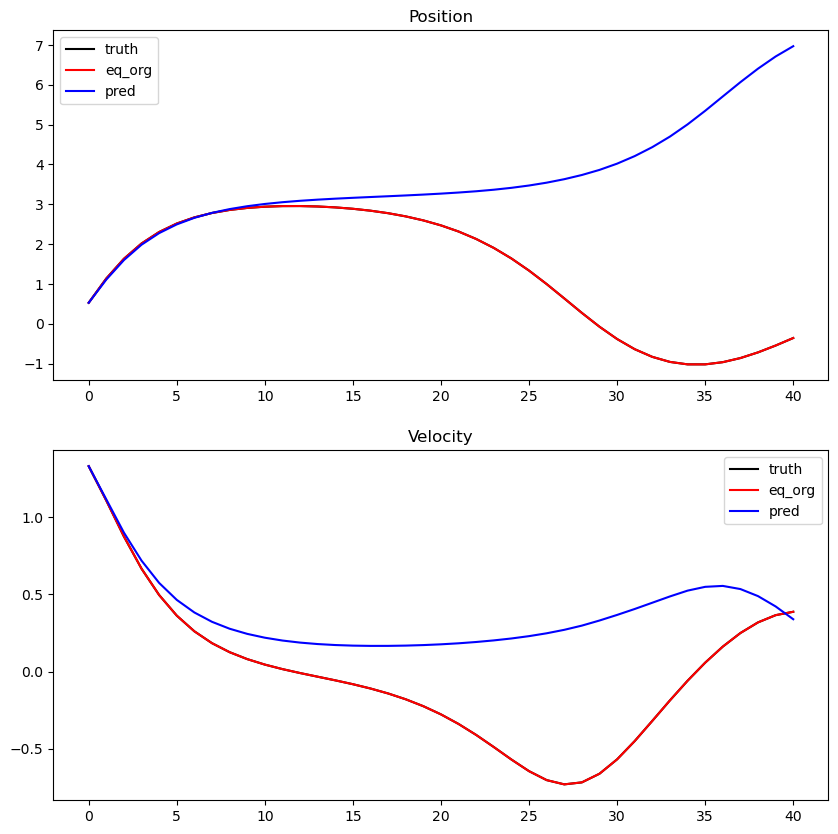

In [5]:
plot_trajectory(22)

[-1.34345663  0.41287747]
(1, 2, 41)


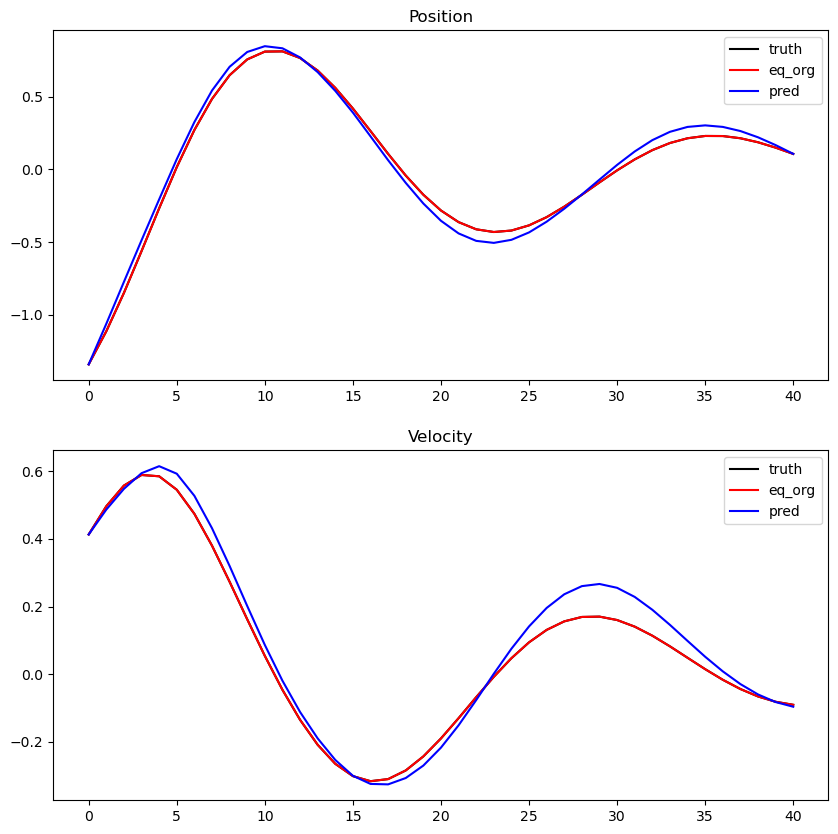

In [11]:
plot_trajectory(24)

## SC Trials 17/02 (`data/sanity_checks2`)

In [2]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  

In [3]:
def load_results(results_pth):
    results = pd.read_json(results_pth).T
    exp_name = results_pth.split("/")[-2]
    val_loss = float(results_pth.split("_")[-1][:-6])

    # add initial conditions to dataframe
    results["q0"] = results["states"].apply(lambda x: x[0][0])
    results["p0"] = results["states"].apply(lambda x: x[1][0])
    return results, exp_name, val_loss

In [4]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_14_d7l5vx50/model_1.132e-03.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('complete_physics_14_d7l5vx50', 1.132)

In [5]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682531356811523, -2....",0.000367,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403149604797363, 1.68172...",0.001082,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.65600299835205, -1.94...",0.001977,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.616124749183654, -1....",0.000474,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.427735567092895, 1.1563...",0.000238,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.47775387763977, 2.85766...",0.000416,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6010524034500122, -1....",0.001667,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.7057180404663081, 2.253...",0.000321,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.53653860092163, -2.3...",0.000355,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494138717651367, -1.6...",0.000535,0.0,-1.292473,-0.493132


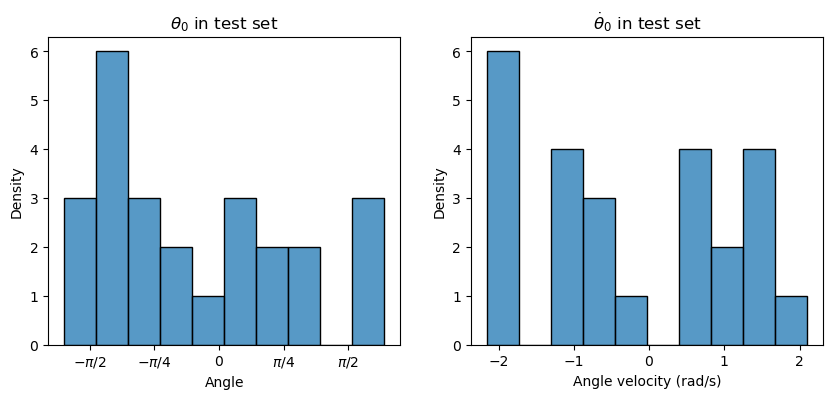

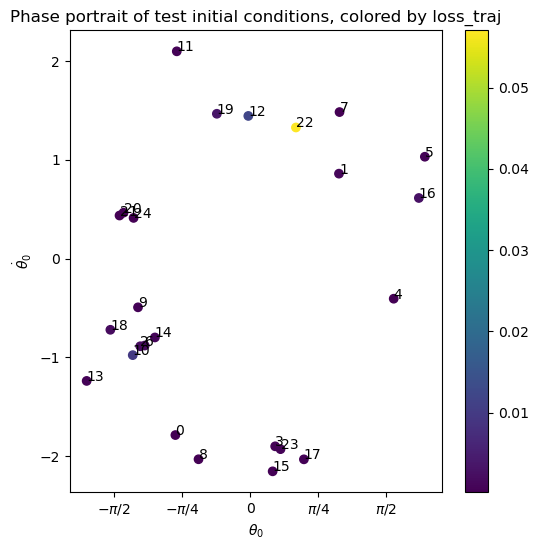

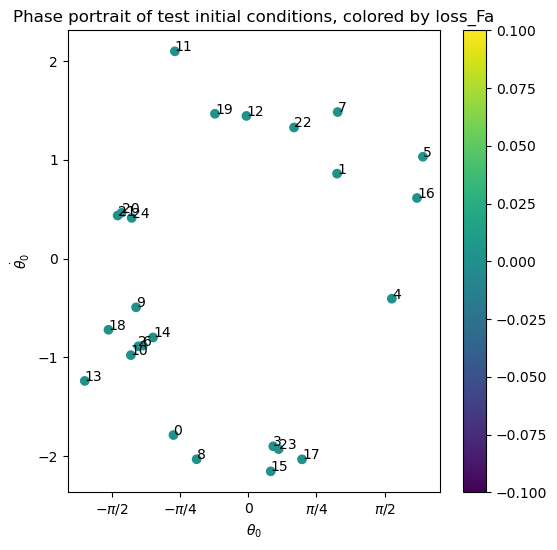

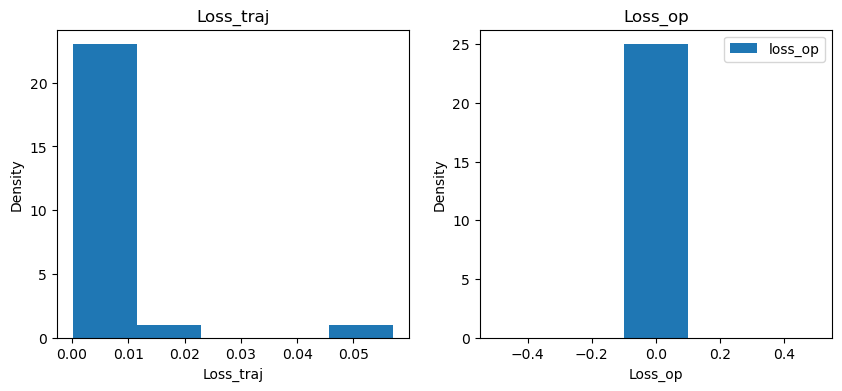

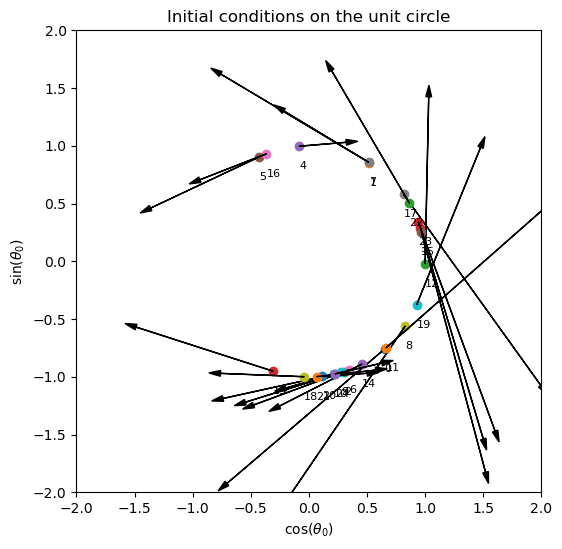

In [6]:
def viz_CI_regimes(res, type="test"):
    # subplot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # choose boxes of the histogram
    sns.histplot(res["q0"], ax=ax[0], bins=10)
    ax[0].set_title(rf"$\theta_0$ in {type} set")
    ax[0].set_xlabel("Angle")
    ax[0].set_ylabel("Density")
    ax[0].set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax[0].set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])

    sns.histplot(res["p0"], ax=ax[1], bins=10)
    ax[1].set_title(fr"$\dot\theta_0$ in {type} set")
    ax[1].set_xlabel("Angle velocity (rad/s)")
    ax[1].set_ylabel("Density")
    plt.show()

    # portrait de phase 
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    # put index of traj above the point
    for i, txt in enumerate(res.index):
        ax.annotate(txt, (res["q0"][i], res["p0"][i]))
    if type == "train":
        plt.scatter(res["q0"], res["p0"], label="Initial conditions")
        plt.title(f"Phase portrait of {type} initial conditions")
    else:
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_traj"], cmap="viridis")
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_traj")
        plt.colorbar()
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\dot{\theta}_0$")
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
    
    plt.show()

    # portrait de phase colored by loss_Fa
    if type != "train":
        fig, ax = plt.subplots(1,1,figsize=(6, 6))
        # put index of traj above the point
        for i, txt in enumerate(res.index):
            ax.annotate(txt, (res["q0"][i], res["p0"][i]))
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_op"], cmap="viridis")
        plt.xlabel(r"$\theta_0$")
        plt.ylabel(r"$\dot{\theta}_0$")
        ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
        ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
        plt.colorbar()
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_Fa")
        plt.show()

        # histograms of loss_traj and loss_op
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        res["loss_traj"].plot.hist(ax=ax[0], bins=5)
        ax[0].set_title(r"Loss_traj")
        ax[0].set_xlabel("Loss_traj")
        ax[0].set_ylabel("Density")
        res["loss_op"].plot.hist(ax=ax[1], bins=5)
        ax[1].set_title(r"Loss_op")
        ax[1].set_xlabel("Loss_op")
        ax[1].set_ylabel("Density")
        plt.legend()
        plt.show()


    # circular histogram
    # square figure
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    for i, txt in enumerate(res.index):
        # position
        theta = res["q0"][i]
        plt.scatter(np.cos(theta),np.sin(theta))
        ax.annotate(txt, (np.cos(theta),np.sin(theta)-0.2), fontsize=8)
        # add arrow for velocity
        norm = res["p0"][i]
        ax.arrow(np.cos(theta), np.sin(theta), -norm*np.sin(theta), norm*np.cos(theta), head_width=0.05, head_length=0.1, fc='k', ec='k')
    plt.ylim([-2,2])
    plt.xlim([-2,2])
    plt.xlabel(r"cos($\theta_0$)")
    plt.ylabel(r"sin($\theta_0$)")
    plt.title("Initial conditions on the unit circle")


viz_CI_regimes(results)

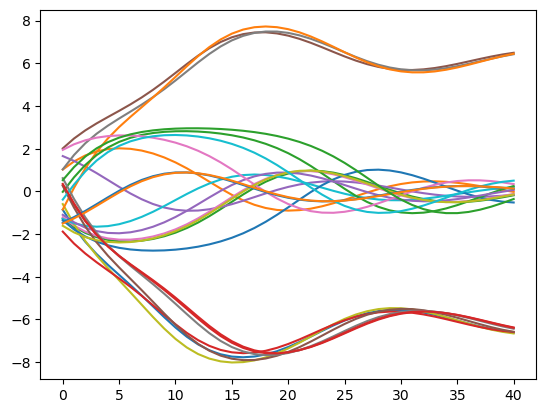

In [7]:
for index in range(24):
    states = np.array(results["states"][index])
    plt.plot(states[0], label="q")

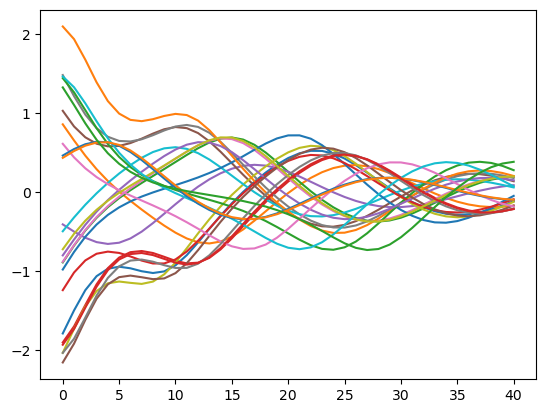

In [8]:
for index in range(24):
    states = np.array(results["states"][index])
    plt.plot(states[1], label="p")

In [9]:
def plot_trajectory(res, exp, index):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    y0 = np.array(res["states"][index])[:,0]
    # set y max
    ax[0].set_ylim([-8, 8])
    ax[1].set_ylim([-2.1,2.1])

    ax[0].set_title(f"Trajectory {index}: position, q0={round(float(y0[0]),3)}") 
    ax[0].plot(np.array(res["states"][index][0]), label="truth", color="gray")
    ax[0].plot(np.array(res["pred"][index][0]), label="pred", color="darkorange")
    # add regime areas
    # multiples de 2pi
    null_angles = [k*np.pi for k in range(-2, 3, 2)]
    i=0
    for angle in null_angles:
        if i ==0:
            ax[0].axhline(y=angle, color='black', linestyle='--', label="q=0", alpha=0.5)
        else:
            ax[0].axhline(y=angle, color='black', linestyle='--', alpha=0.5)
        i+=1
    ax[0].axhline(y=np.pi, color='orangered', linestyle='--', label="turn", alpha=0.5)
    ax[0].axhline(y=-np.pi, color='orangered', linestyle='--', alpha=0.5)
    # set ticks with labels
    ax[0].set_yticks(null_angles + [np.pi, -np.pi])
    # write pi in latex style
    ax[0].set_yticklabels(["-2$\pi$", "0",  "2$\pi$", "$\pi$", "-$\pi$"])
    ax[0].set_xlabel("Time steps")
    ax[0].set_ylabel("Angle (rad)")
    ax[0].legend()

    ax[1].set_title(f"Trajectory {index}: velocity, p0={round(float(y0[1]),3)}")
    ax[1].plot(np.array(res["states"][index][1]), label="truth", color="gray")
    ax[1].plot(np.array(res["pred"][index][1]), label="pred", color="darkorange")
    # null velocity line
    ax[1].axhline(y=0, color='black', linestyle='--', label="p=0", alpha=0.5)   
    ax[1].set_xlabel("Time steps")
    ax[1].set_ylabel("Angle velocity (rad/s)")
    ax[1].legend()

    fig.suptitle(f"Experiment: {exp}, loss_traj={round(res['loss_traj'][index],5)}, loss_op={round(res['loss_op'][index],5)}")
    plt.show()
    

## Train data 

In [10]:
# train data viz
from datasets import * 
import os
path = 'data/sanity_checks2'
dataset_name = 'pendulum'
train, _,_ = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

train.dataset

In [11]:
for i, train_data in enumerate(train):
    print(train_data["states"].shape)

torch.Size([25, 2, 41])


In [12]:
y0 = train_data["states"][:,:,0]
y0 = pd.DataFrame(y0, columns=["q0", "p0"])
y0

,q0,p0
0,-1.334527,0.894015
1,-0.144654,-2.158659
2,0.262720,1.561437
3,1.402906,1.221938
4,1.519548,-1.305323
5,2.101425,-0.089342
6,1.486833,-0.771030
7,1.659655,1.451410
8,1.759936,-0.704725
9,-0.974419,-1.359348


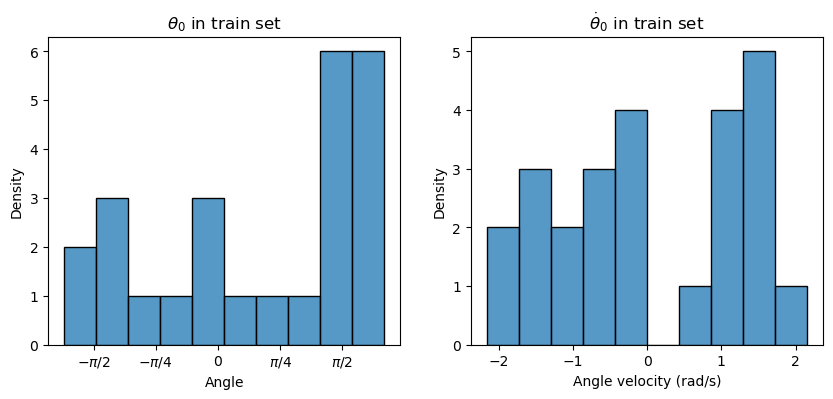

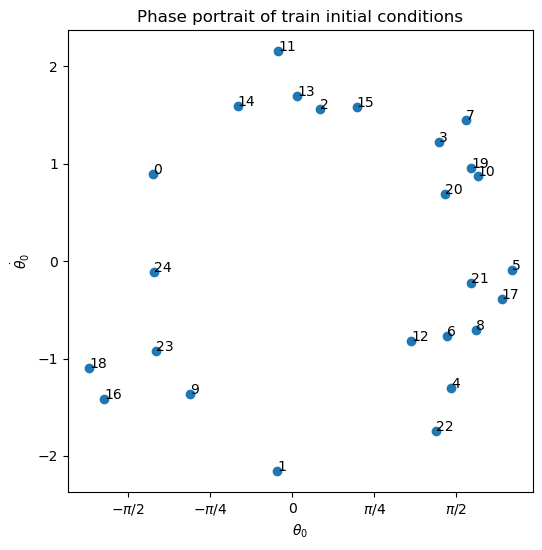

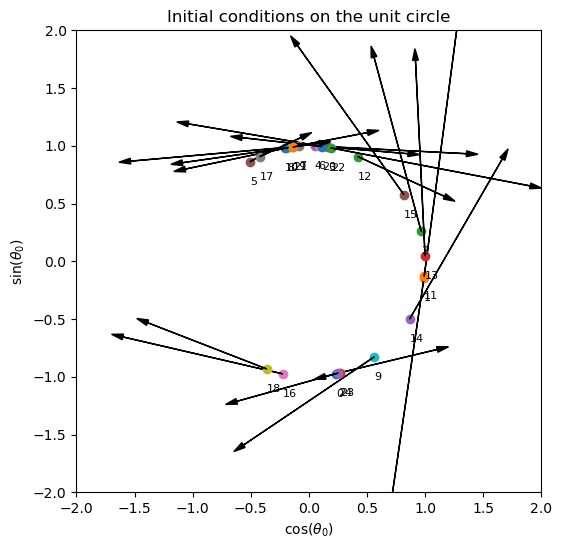

In [13]:
viz_CI_regimes(y0, type="train")

## None aug 16

In [298]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/none_aug_16_1m63z5th/model_6.047e-02..json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('none_aug_16_1m63z5th', 0.06047)

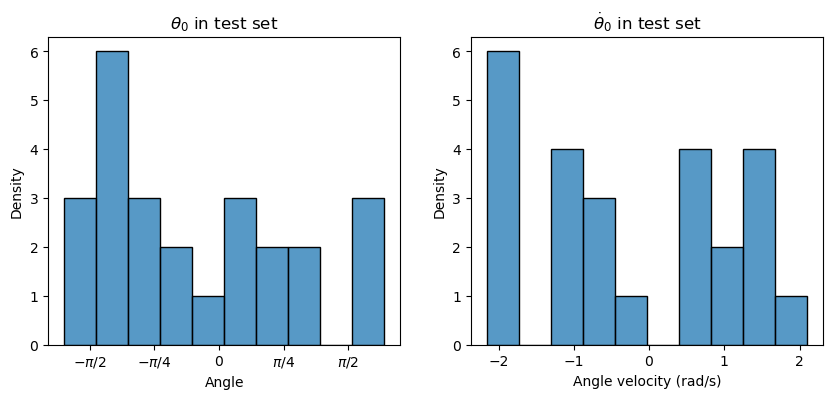

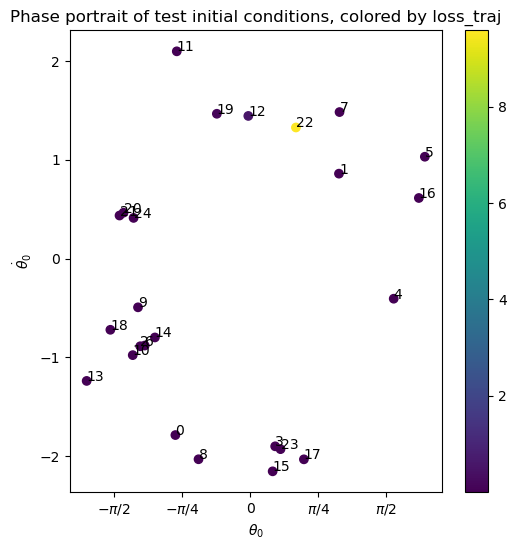

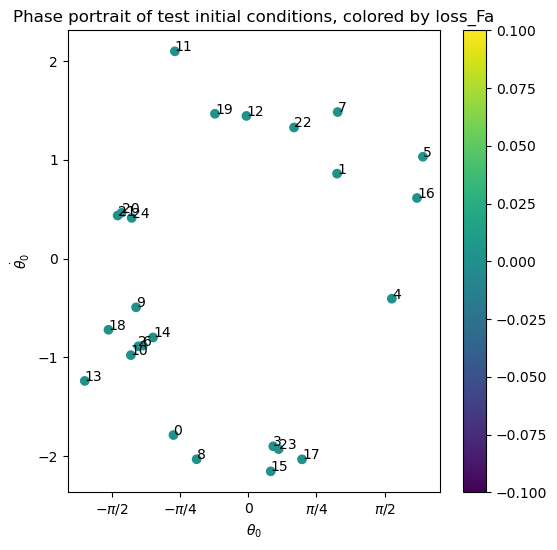

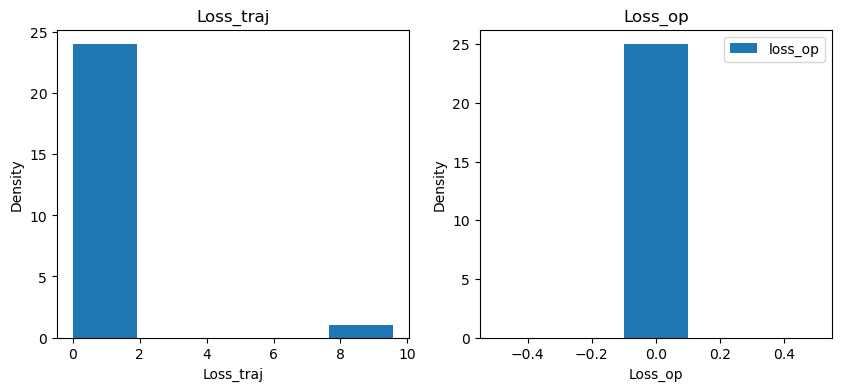

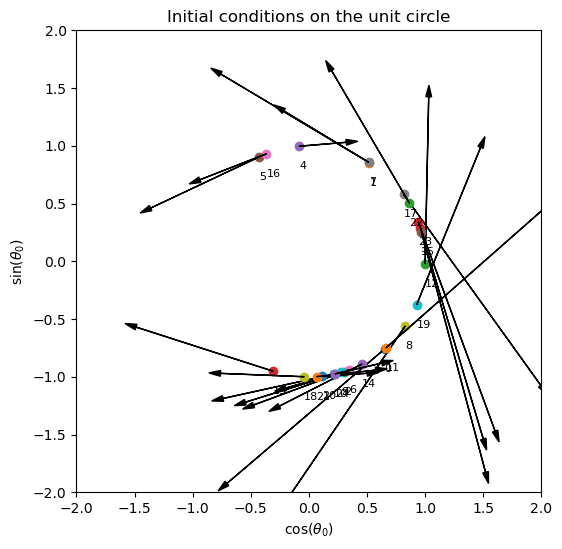

In [299]:
viz_CI_regimes(results)

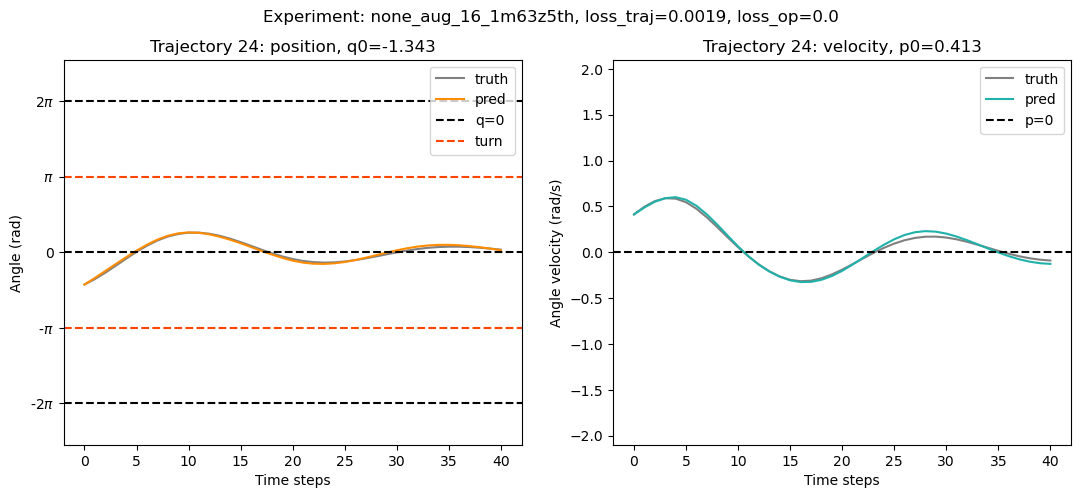

In [300]:
plot_trajectory(results, exp_name, 24)

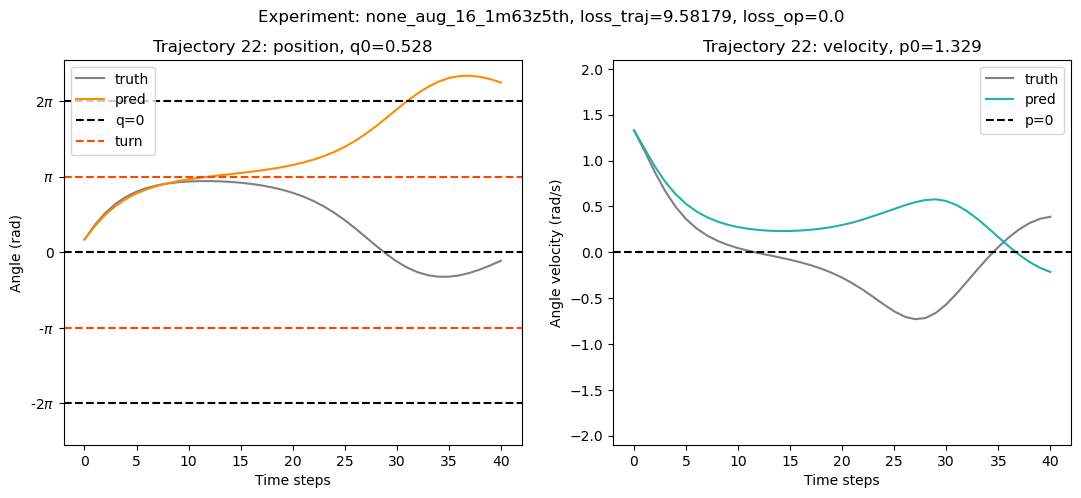

In [301]:
plot_trajectory(results, exp_name, 22)

## complete physics 14

Final omega: 0.28003543615341187, Final alpha: 0.196983486413955

In [302]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_14_d7l5vx50/model_1.132e-03.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('complete_physics_14_d7l5vx50', 1.132)

In [303]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682531356811523, -2....",0.000367,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403149604797363, 1.68172...",0.001082,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.65600299835205, -1.94...",0.001977,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.616124749183654, -1....",0.000474,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.427735567092895, 1.1563...",0.000238,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.47775387763977, 2.85766...",0.000416,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.6010524034500122, -1....",0.001667,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.7057180404663081, 2.253...",0.000321,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.53653860092163, -2.3...",0.000355,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494138717651367, -1.6...",0.000535,0.0,-1.292473,-0.493132


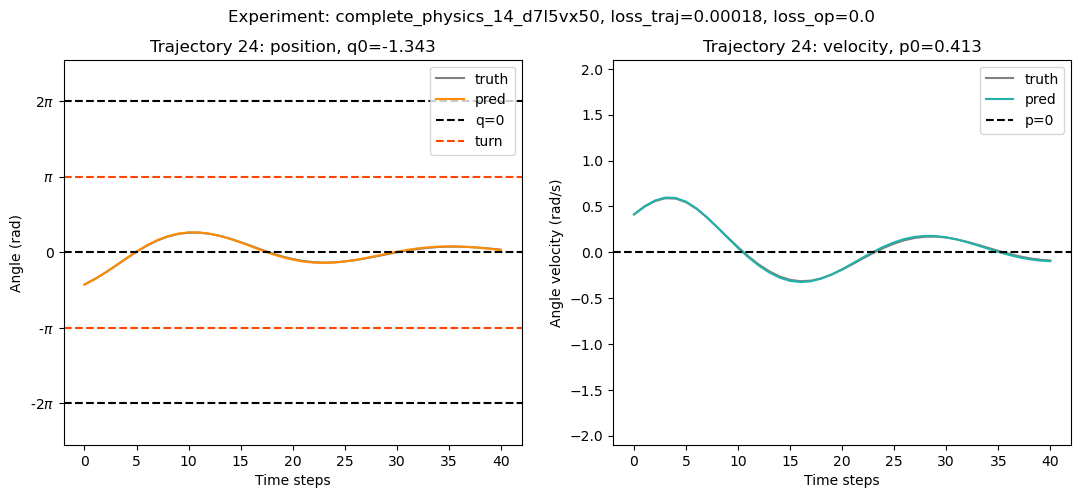

In [304]:
plot_trajectory(results, exp_name, 24)

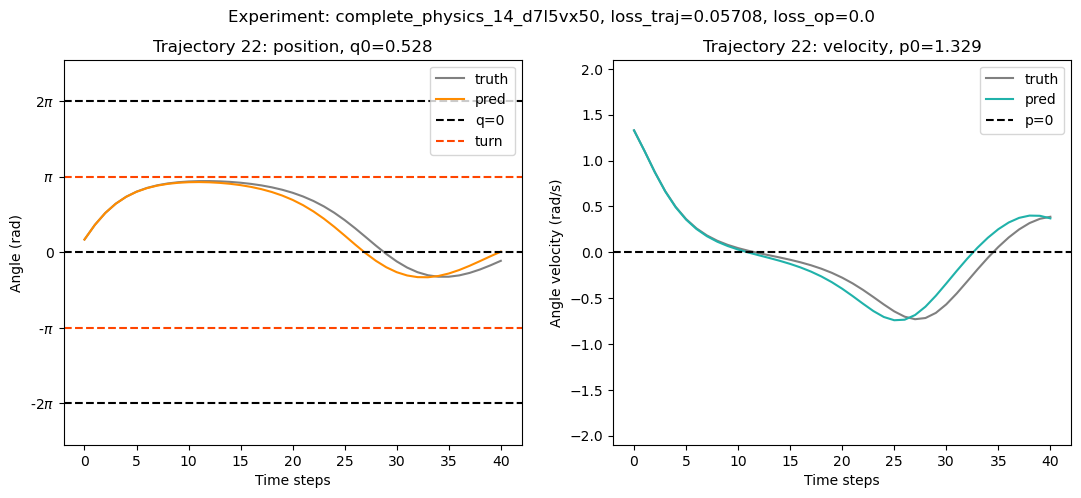

In [305]:
plot_trajectory(results, exp_name, 22)

### incomplete aug 17: wrong loss 
Final omega: 0.2073115110397339, Final alpha: 0.0

In [306]:
path = '/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_17_m9bz4n8c/model_2.790e+00.json'
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('incomplete_aug_17_m9bz4n8c', 2.79)

In [307]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.6506702899932861, -2...",0.143378,0.001966,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.429108142852783, 1.76517...",1.285091,0.000516,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.638038635253906, -1.9...",0.632978,0.001288,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.626850128173828, -1....",0.069507,0.001914,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.4389311075210571, 1.179...",0.347999,0.000442,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.484290599822998, 2.8936...",0.034732,0.000359,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.58401083946228, -1.87...",0.609975,0.001255,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.739323139190673, 2.3589...",0.145952,0.000423,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.510691046714782, -2....",0.1201,0.002042,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.494427680969238, -1.6...",0.399011,0.000848,-1.292473,-0.493132


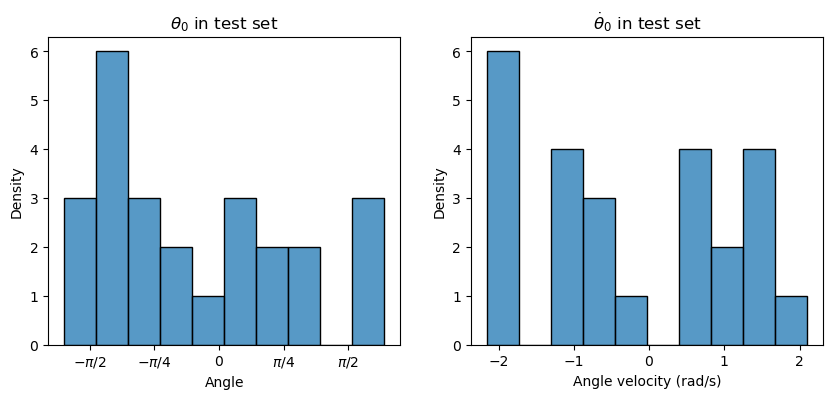

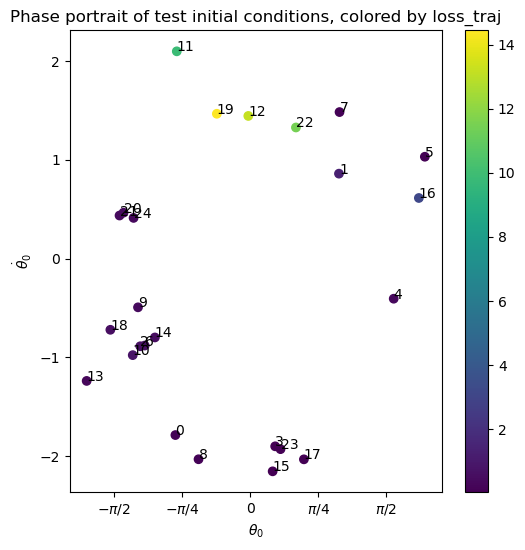

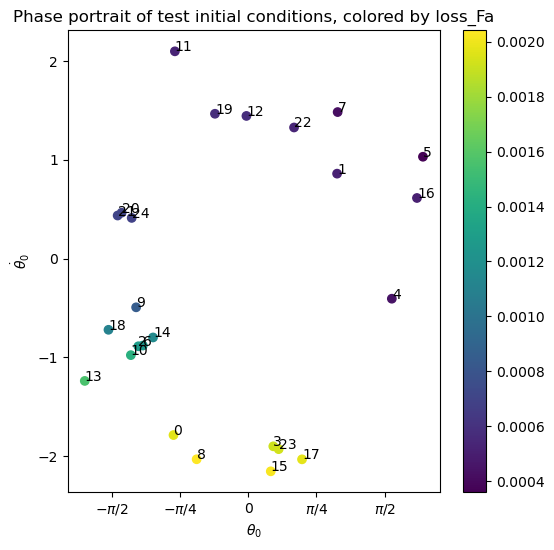

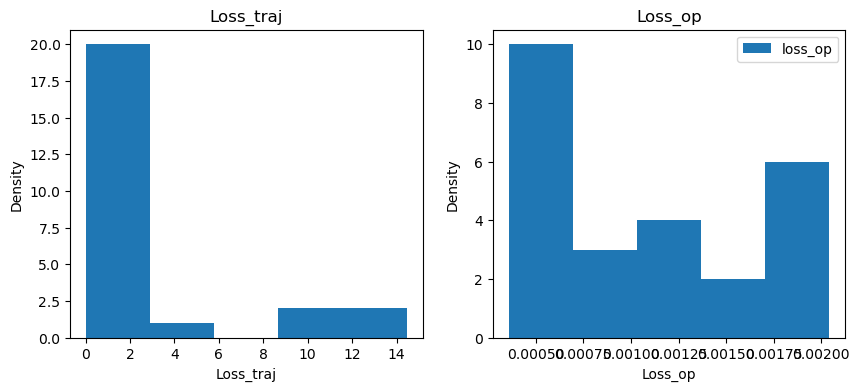

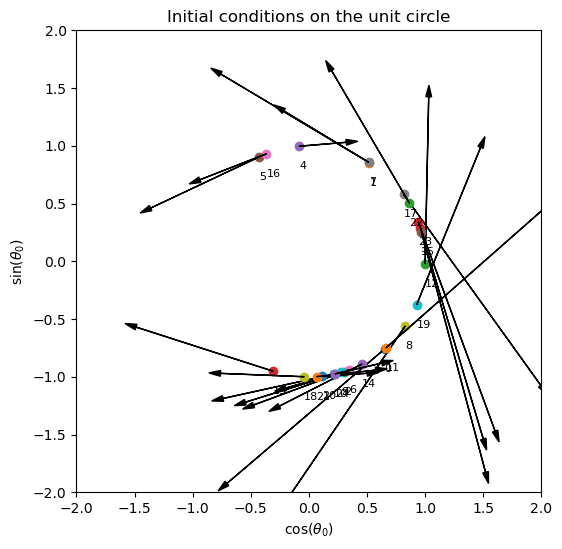

In [308]:
viz_CI_regimes(results)

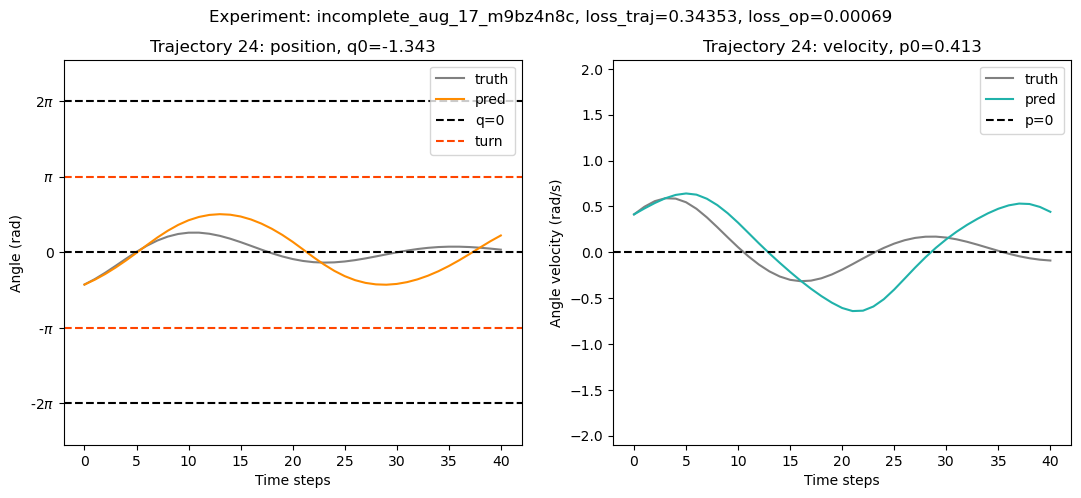

In [233]:
plot_trajectory(results, exp_name, 24)

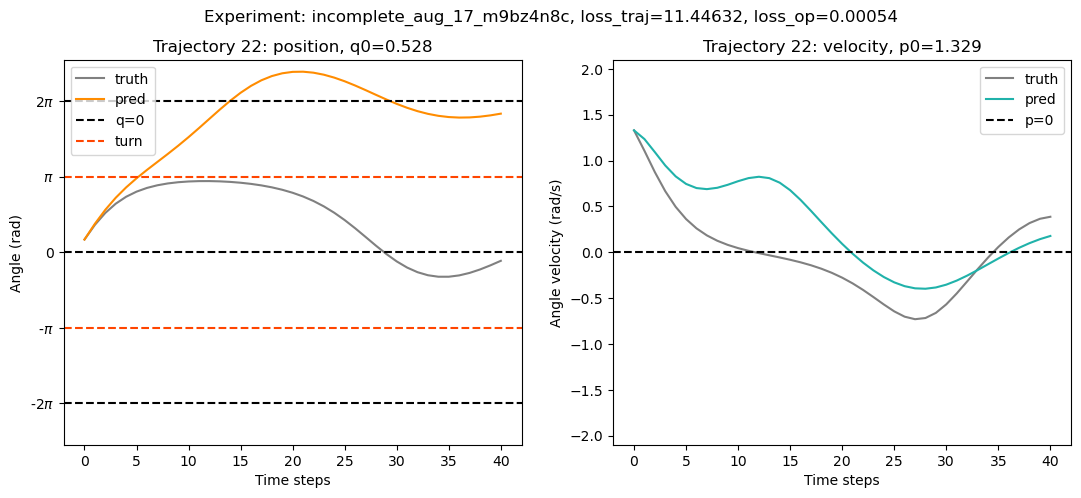

In [234]:
plot_trajectory(results, exp_name, 22)

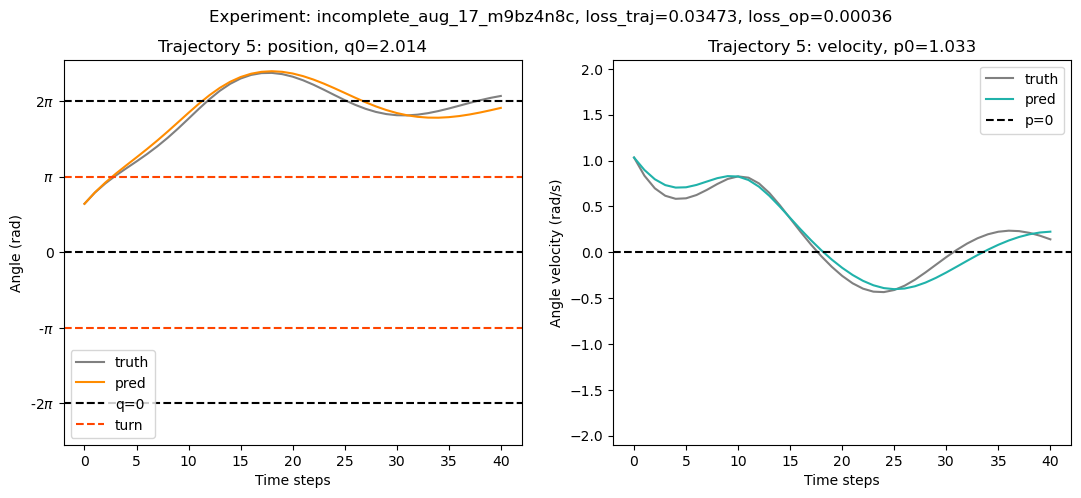

In [235]:
plot_trajectory(results, exp_name, 5)

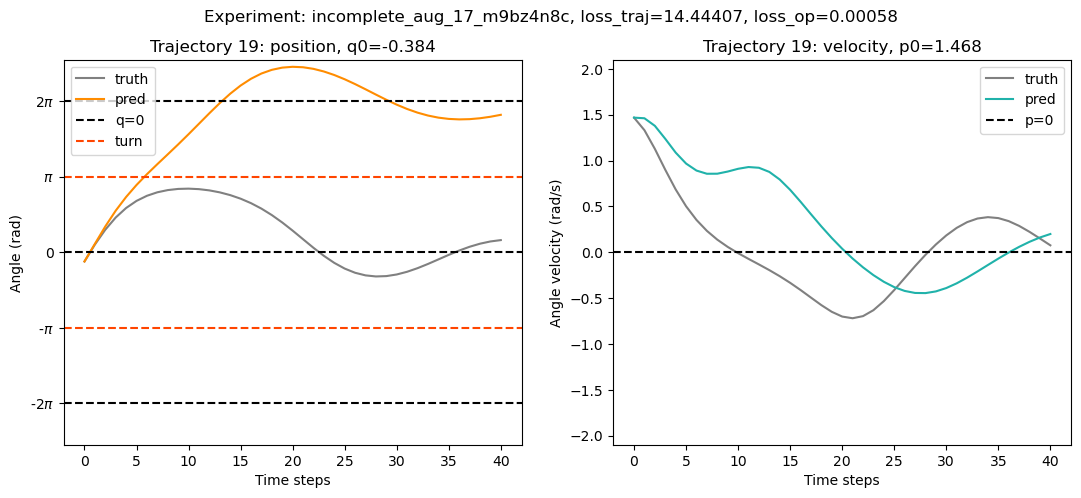

In [236]:
plot_trajectory(results, exp_name, 19)

## incomplete aug 19
Final omega: 0.22525587677955627, Final alpha: 0.0

In [309]:
path = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_19_korcnphf/model_2.400e+00.json"
results, exp_name, val_loss = load_results(path)
exp_name, val_loss

('incomplete_aug_19_korcnphf', 2.4)

In [310]:
results

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.277207612991333, -1....",10.760328,0.611657,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.263813138008117, 1.43468...",0.818055,3.079111,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.395644307136535, -1.4...",1.165683,2.029806,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.26815548539161604, -...",9.761674,0.691293,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.33664870262146, 1.00300...",0.94818,6.029916,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.424787759780884, 2.7662...",0.038825,0.000919,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.352573156356811, -1.3...",1.162419,2.388407,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.646154522895813, 2.1580...",0.031189,0.001775,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.120106697082519, -1....",11.397531,0.622855,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.359453797340393, -1.4...",1.19821,6.289103,-1.292473,-0.493132


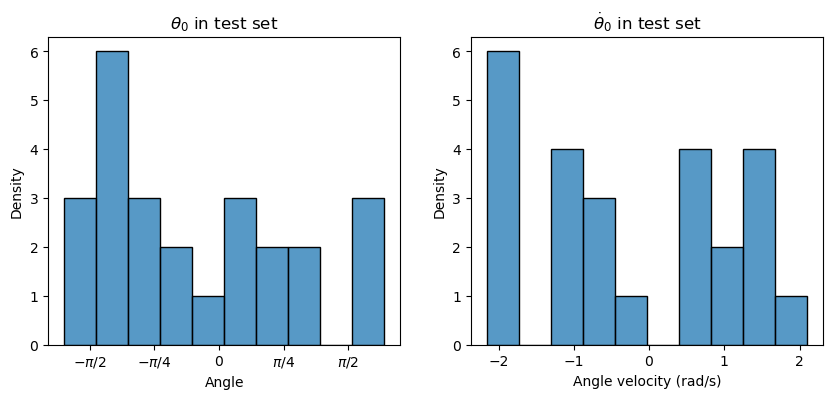

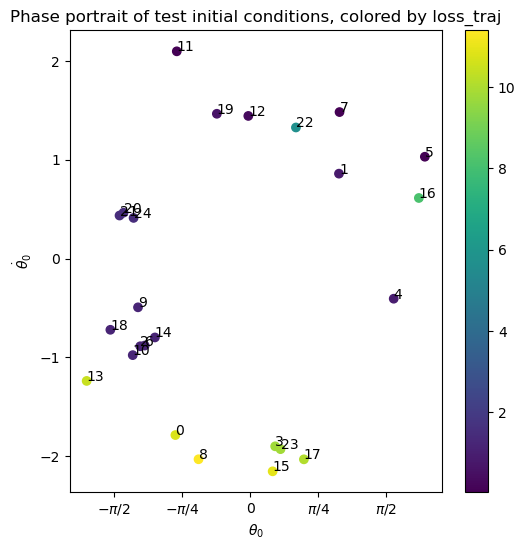

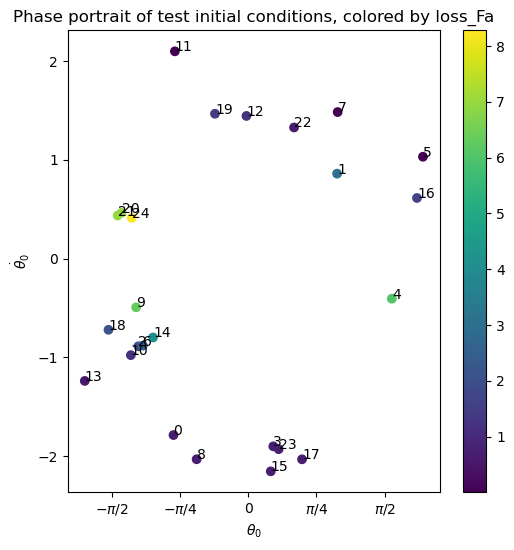

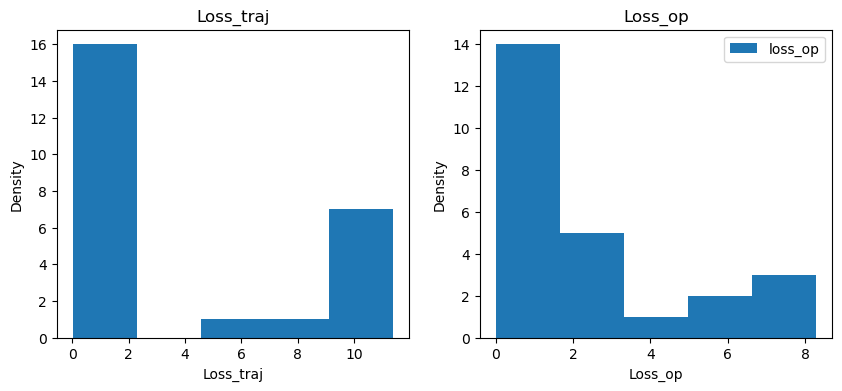

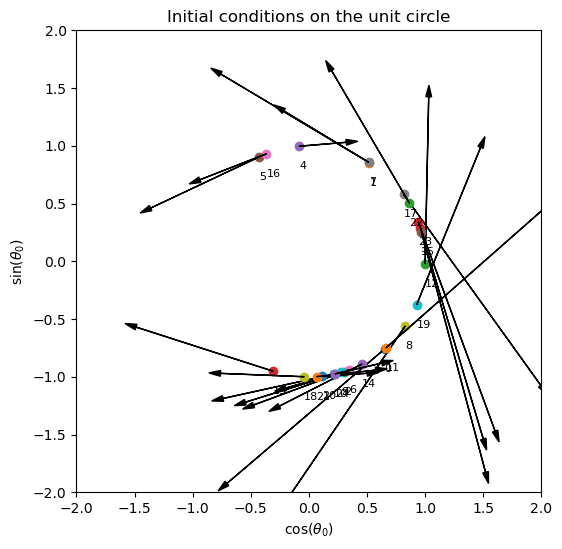

In [311]:
viz_CI_regimes(results)

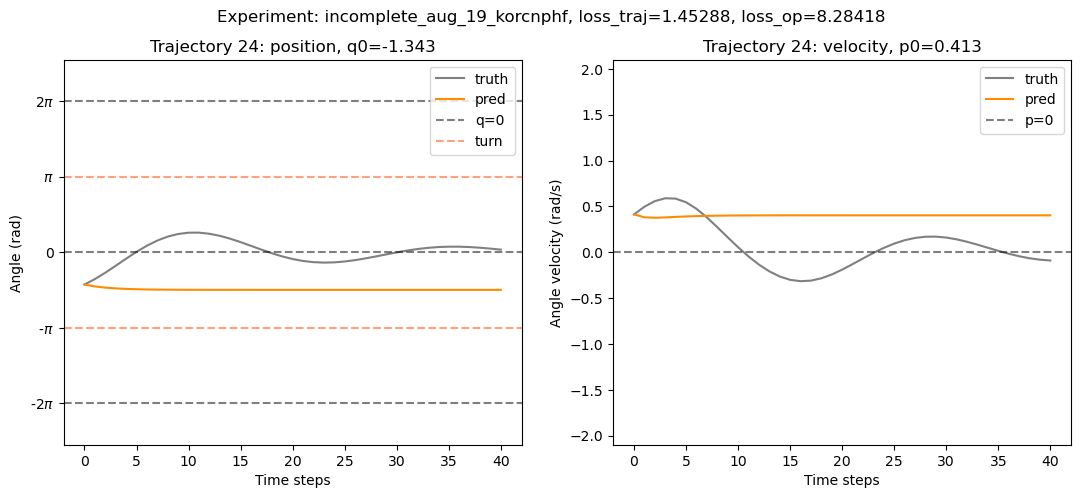

In [324]:
plot_trajectory(results, exp_name, 24)

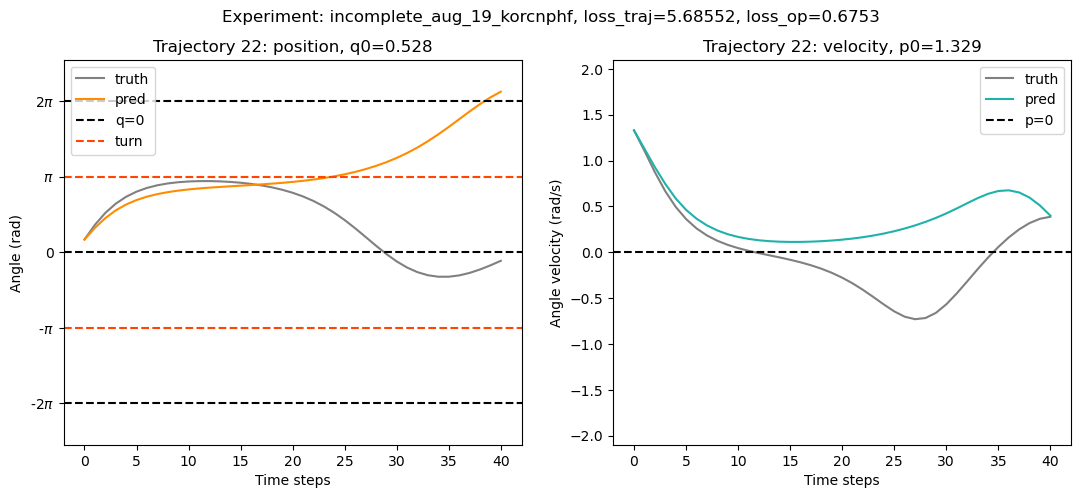

In [313]:
plot_trajectory(results, exp_name, 22)  

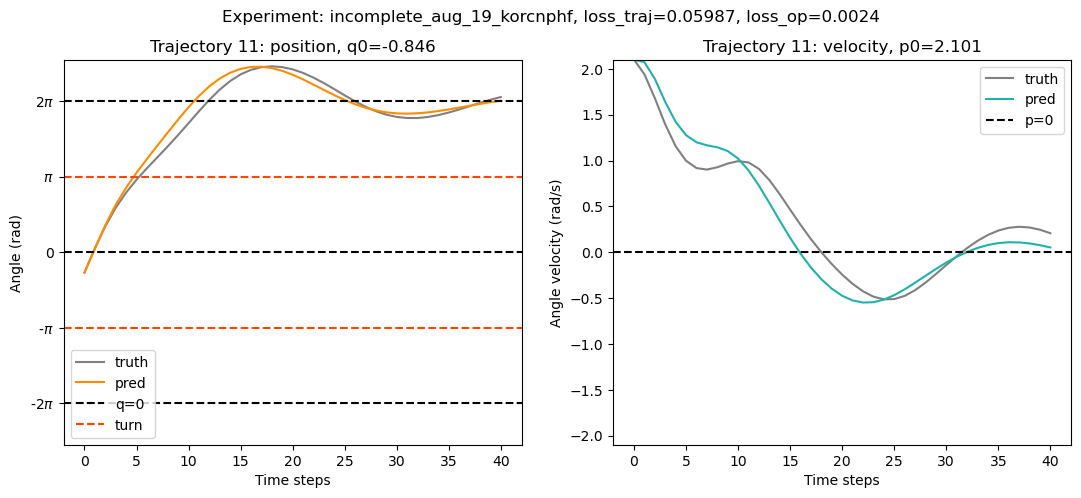

In [314]:
plot_trajectory(results, exp_name, 11)

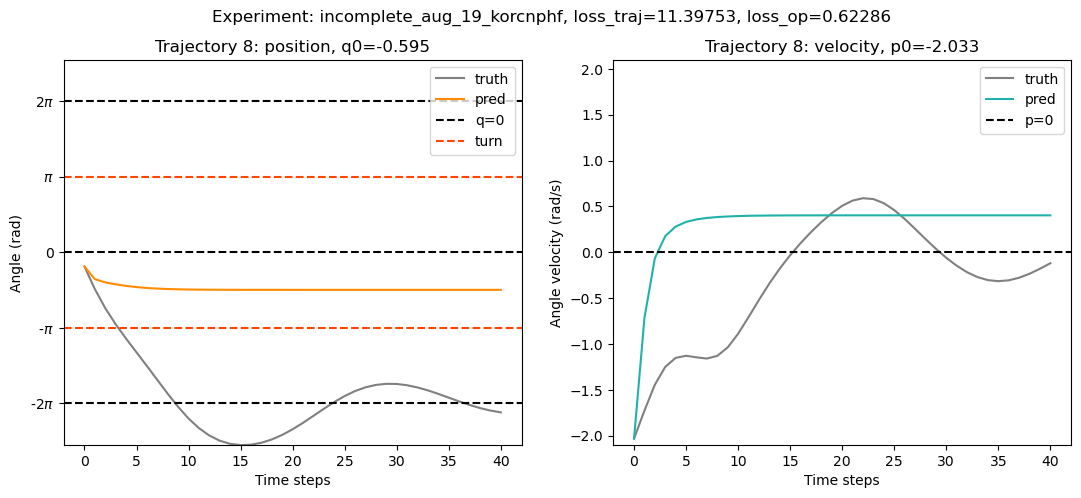

In [315]:
plot_trajectory(results, exp_name, 8)

# Final sanity checks
Jit corrected, 400 epochs

- SC1: complete_physics_26_f6dwvliv
- SC2: incomplete_aug_30_q5w7dej1
- SC2.2: incomplete_no_Fa_aug_28_riymbky6
- SC3: none_aug_24_of0iieil

Pour les SC2, avec min_op='l2', lambda_0=10, tau_2=100:
- SC2: incomplete_aug_34_lx8y2wmb


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from datasets import * 
import os
path = 'data/sanity_checks2'
dataset_name = 'pendulum'
train, _, test = init_dataloaders("pendulum", 'RK4', os.path.join(path, dataset_name))

for i, train_data in enumerate(train):
    print(train_data["states"].shape)
for i, test_data in enumerate(test):
    print(test_data["states"].shape)

y0 = train_data["states"][:,:,0]
y0 = pd.DataFrame(y0, columns=["q0", "p0"])
y0

torch.Size([25, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])
torch.Size([1, 2, 41])


,q0,p0
0,-1.334527,0.894015
1,-0.144654,-2.158659
2,0.262720,1.561437
3,1.402906,1.221938
4,1.519548,-1.305323
5,2.101425,-0.089342
6,1.486833,-0.771030
7,1.659655,1.451410
8,1.759936,-0.704725
9,-0.974419,-1.359348


In [4]:
def load_results(results_pth):
    results = pd.read_json(results_pth).T
    exp_name = results_pth.split("/")[-2]
    val_loss = float(results_pth.split("_")[-1][:-6])

    # add initial conditions to dataframe
    results["q0"] = results["states"].apply(lambda x: x[0][0])
    results["p0"] = results["states"].apply(lambda x: x[1][0])
    return results, exp_name, val_loss

In [5]:
def plot_trajectory(res, exp, index):
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    y0 = np.array(res["states"][index])[:,0]
    # set y max
    ax[0].set_ylim([-8, 8])
    ax[1].set_ylim([-2.1,2.1])

    ax[0].set_title(f"Trajectory {index}: position, q0={round(float(y0[0]),3)}") 
    ax[0].plot(np.array(res["states"][index][0]), label="truth", color="gray")
    ax[0].plot(np.array(res["pred"][index][0]), label="pred", color="darkorange")
    # add regime areas
    # multiples de 2pi
    null_angles = [k*np.pi for k in range(-2, 3, 2)]
    i=0
    for angle in null_angles:
        if i ==0:
            ax[0].axhline(y=angle, color='black', linestyle='--', label="q=0", alpha=0.5)
        else:
            ax[0].axhline(y=angle, color='black', linestyle='--', alpha=0.5)
        i+=1
    ax[0].axhline(y=np.pi, color='orangered', linestyle='--', label="turn", alpha=0.5)
    ax[0].axhline(y=-np.pi, color='orangered', linestyle='--', alpha=0.5)
    # set ticks with labels
    ax[0].set_yticks(null_angles + [np.pi, -np.pi])
    # write pi in latex style
    ax[0].set_yticklabels(["-2$\pi$", "0",  "2$\pi$", "$\pi$", "-$\pi$"])
    ax[0].set_xlabel("Time steps")
    ax[0].set_ylabel("Angle (rad)")
    ax[0].legend()

    ax[1].set_title(f"Trajectory {index}: velocity, p0={round(float(y0[1]),3)}")
    ax[1].plot(np.array(res["states"][index][1]), label="truth", color="gray")
    ax[1].plot(np.array(res["pred"][index][1]), label="pred", color="darkorange")
    # null velocity line
    ax[1].axhline(y=0, color='black', linestyle='--', label="p=0", alpha=0.5)   
    ax[1].set_xlabel("Time steps")
    ax[1].set_ylabel("Angle velocity (rad/s)")
    ax[1].legend()

    fig.suptitle(f"Experiment: {exp}, loss_traj={round(res['loss_traj'][index],5)}, loss_op={round(res['loss_op'][index],5)}")
    plt.show()
    

In [6]:
def viz_losses_regimes(res, y0train):
    fig, ax = plt.subplots(1,1,figsize=(10, 15))
    delta=0.1
    # put index of traj above the point
    for i, txt in enumerate(res.index):
        ax.annotate(txt, (res["q0"][i], res["p0"][i]+ delta))
    # Scatter plot for left half (loss_traj)
    sc1 = ax.scatter(res["q0"], res["p0"], c=res["loss_traj"], cmap="viridis", marker=8, label="Loss Traj", linewidths=3)

    # Scatter plot for right half (loss_op)
    sc2 = ax.scatter(res["q0"], res["p0"], c=res["loss_op"], cmap="cool", marker=9, label="Loss Op", linewidths=3)

    # add train samples 
    plt.scatter(y0train["q0"], y0train["p0"], label="Train y0", color="black", marker="x")

    # Add colorbars
    cbar1 = plt.colorbar(sc1, ax=ax, label="Loss Traj (left)", orientation="horizontal")
    cbar2 = plt.colorbar(sc2, ax=ax, label="Loss Op (right)", orientation="horizontal")

    plt.title(f"Phase portrait of test initial conditions, colored by loss_traj")
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\dot{\theta}_0$")
    plt.legend()
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
    plt.show()
    

In [9]:
def viz_CI_regimes(res, type="test"):
    # subplot
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    # choose boxes of the histogram
    sns.histplot(res["q0"], ax=ax[0], bins=10)
    ax[0].set_title(rf"$\theta_0$ in {type} set")
    ax[0].set_xlabel("Angle")
    ax[0].set_ylabel("Density")
    ax[0].set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax[0].set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])

    sns.histplot(res["p0"], ax=ax[1], bins=10)
    ax[1].set_title(fr"$\dot\theta_0$ in {type} set")
    ax[1].set_xlabel("Angle velocity (rad/s)")
    ax[1].set_ylabel("Density")
    plt.show()

    # portrait de phase 
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    # put index of traj above the point
    for i, txt in enumerate(res.index):
        ax.annotate(txt, (res["q0"][i], res["p0"][i]))
    if type == "train":
        plt.scatter(res["q0"], res["p0"], label="Initial conditions")
        plt.title(f"Phase portrait of {type} initial conditions")
    else:
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_traj"], cmap="viridis")
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_traj")
        plt.colorbar()
    plt.xlabel(r"$\theta_0$")
    plt.ylabel(r"$\dot{\theta}_0$")
    ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
    ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
    
    plt.show()

    # portrait de phase colored by loss_Fa
    if type != "train":
        fig, ax = plt.subplots(1,1,figsize=(6, 6))
        # put index of traj above the point
        for i, txt in enumerate(res.index):
            ax.annotate(txt, (res["q0"][i], res["p0"][i]))
        plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_op"], cmap="viridis")
        plt.xlabel(r"$\theta_0$")
        plt.ylabel(r"$\dot{\theta}_0$")
        ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
        ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
        plt.colorbar()
        plt.title(f"Phase portrait of {type} initial conditions, colored by loss_Fa")
        plt.show()

        # histograms of loss_traj and loss_op
        fig, ax = plt.subplots(1, 2, figsize=(10, 4))
        res["loss_traj"].plot.hist(ax=ax[0], bins=5)
        ax[0].set_title(r"Loss_traj")
        ax[0].set_xlabel("Loss_traj")
        ax[0].set_ylabel("Density")
        res["loss_op"].plot.hist(ax=ax[1], bins=5)
        ax[1].set_title(r"Loss_op")
        ax[1].set_xlabel("Loss_op")
        ax[1].set_ylabel("Density")
        plt.legend()
        plt.show()


    # circular histogram
    # square figure
    fig, ax = plt.subplots(1,1,figsize=(6, 6))
    for i, txt in enumerate(res.index):
        # position
        theta = res["q0"][i]
        plt.scatter(np.cos(theta),np.sin(theta))
        ax.annotate(txt, (np.cos(theta),np.sin(theta)-0.2), fontsize=8)
        # add arrow for velocity
        norm = res["p0"][i]
        ax.arrow(np.cos(theta), np.sin(theta), -norm*np.sin(theta), norm*np.cos(theta), head_width=0.05, head_length=0.1, fc='k', ec='k')
    plt.ylim([-2,2])
    plt.xlim([-2,2])
    plt.xlabel(r"cos($\theta_0$)")
    plt.ylabel(r"sin($\theta_0$)")
    plt.title("Initial conditions on the unit circle")


#viz_CI_regimes(results)

In [10]:
def plot_phase_trajectory(res, exp, index):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    y0 = np.array(res["states"][index])[:,0]
    # set y max
    ax.set_ylim([-8, 8])
    ax.set_ylim([-2.1,2.1])

    ax.set_title(f"Phase portrait {index}") 
    traj = res["states"][index]
    traj_pred = res["pred"][index]
    plt.plot(np.array(traj[0]), np.array(traj[1]), label="truth", color="gray")
    plt.plot(np.array(traj_pred[0]),np.array(traj_pred[1]), label="pred", color="darkorange")
    plt.xlabel("Angle (rad)")
    plt.ylabel("Angle velocity (rad/s)")
    plt.legend()
    plt.suptitle(f"Experiment: {exp}, loss_traj={round(res['loss_traj'][index],5)}, loss_op={round(res['loss_op'][index],5)}")
    plt.show()
    

In [11]:
def plot_Fp_Fa_out(res, index):
    # one index, after we plot for all
    fig, ax = plt.subplots(2, 2, figsize=(10, 8))
    input = np.array(res["states"][index])
    q, p = input[:,0], input[:,1]
    output_fa = np.array(res["Fa"][index])
    output_fp = np.array(res["Fp"][index])
    # recover phase portrait
    ax[0][0].plot(q,p,label="true phase portrait", color="black")
    ax[0][0].scatter(q, output_fp[:,0], color="red", label="Fp[0] ~ p")
    ax[0][0].scatter(q, output_fa[:,0], color="blue", label="Fa[0] ~ 0")
    ax[0][0].legend()
    ax[0][0].set_xlabel("q")
    ax[0][0].set_title("F[0] vs q, should be phase portrait")
    
    # recover p 
    ax[0][1].plot(p,p, label="p = p", color="black")
    ax[0][1].scatter(p, output_fp[:,0], label="Fp[0] ~ p", color="red")
    ax[0][1].scatter(p, output_fa[:,0], label="Fa[0] ~ 0", color="blue")
    ax[0][1].legend()
    ax[0][1].set_xlabel("p")
    ax[0][1].set_title("F[0] vs p ~ y=p")

    # recover sinusoidal
    ax[1][0].plot(q, -(2*jnp.pi/12)**2 * jnp.sin(q), label='truth', color="black")
    ax[1][0].scatter(q, output_fp[:,1], label='Fp[1] ~ sin', color="red")
    ax[1][0].scatter(q, output_fp[:,1]+ output_fa[:,1] + 0.2 * p, label=r'(Fp+Fa)[1] + $\alpha p$ ~ sin', color="purple")
    ax[1][0].legend()
    ax[1][0].set_xlabel("q")
    ax[1][0].set_title("F[1] vs q ~ sin(q)")

    # recover alpha
    ax[1][1].plot(p, -0.2 * p, label='truth', color="black")
    ax[1][1].scatter(p, output_fa[:,1], label='Fa[1] ~ -0.2p', color="blue")
    #ax[1][1].scatter(p, output_fp[:,1]+ ((2*jnp.pi/12)**2) * jnp.sin(q), color="red", label='Fp[1]+$\omega_0^2$ sin(q) ~ 0')
    #ax[1][1].scatter(p, output_fp[:,1] + output_fa[:,1] + ((2*jnp.pi/12)**2) * jnp.sin(q), label=r"(Fa+Fp)[1]+ $\omega_0^2$ sin(q) ~ -$\alpha$*p", color="purple")
    ax[1][1].legend()
    ax[1][1].set_xlabel("p")
    ax[1][1].set_title(r"F[1] + $\omega_0^2 sin(q)$  ~ -$\alpha$*p")  
    fig.suptitle(f"Fp+Fa dynamics for trajectory {index}")
    plt.show()    


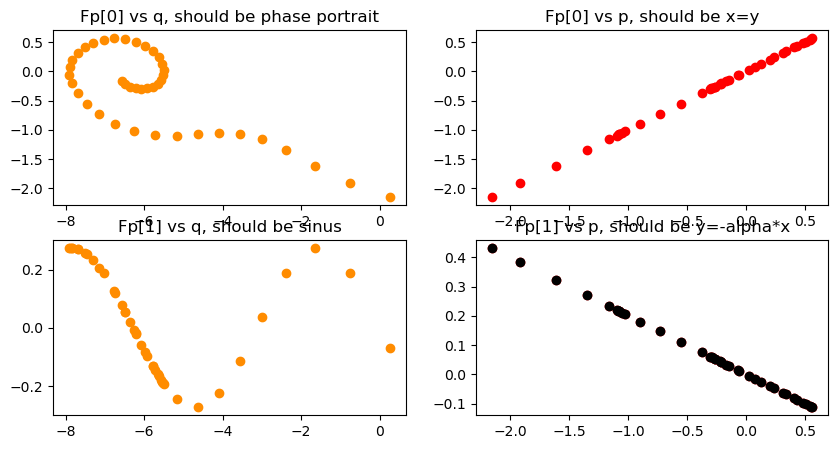

In [16]:
# complete physics for debug
def plot_Fp_out(res, index):
    # one index, after we plot for all
    fig, ax = plt.subplots(2, 2, figsize=(10, 5))
    input = np.array(res["states"][index])
    q, p = input[:,0], input[:,1]
    output_fa = np.array(res["Fa"][index])
    output_fp = np.array(res["Fp"][index])
    ax[0][0].scatter(q, output_fp[:,0], label="Fp[0] v q, should be phase portrait", color="darkorange")
    ax[0][1].scatter(p, output_fp[:,0], label="Fp[0] v p, should be x=y", color="red")
    ax[1][0].scatter(q, output_fp[:,1] + 0.2 * p, label='Fp[1] v q, should be sinusoidal', color="darkorange")
    ax[1][1].scatter(p, output_fp[:,1] + ((2*np.pi/12)**2) * np.sin(q), label="Fp[1] vs p, should be y=-alpha*x", color="red")
    ax[1][1].scatter(p, -0.2 *p, color="black", label="y=-alpha*x")
    ax[0][0].set_title("Fp[0] vs q, should be phase portrait")
    ax[0][1].set_title("Fp[0] vs p, should be x=y")
    ax[1][0].set_title("Fp[1] vs q, should be sinus")
    ax[1][1].set_title("Fp[1] vs p, should be y=-alpha*x")


    plt.show()    

path_sc1_fa = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_26_f6dwvliv/model_2.107e-08_Fa.json"
results_sc1_fa = pd.read_json(path_sc1_fa).T
results_sc1_fa
plot_Fp_out(results_sc1_fa, 15)



## SC1 
Final omega: 0.2741805911064148, Final alpha: 0.19998720288276672

In [14]:
path_sc1 = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/complete_physics_26_f6dwvliv/model_2.107e-08.json"
results_sc1, exp_name_sc1, val_loss_sc1 = load_results(path_sc1)
exp_name_sc1, val_loss_sc1

('complete_physics_26_f6dwvliv', 2.107)

In [15]:
results_sc1

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.682551622390747, -2....",0.0,0.0,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.403507828712463, 1.68330...",0.0,0.0,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.656402707099914, -1.9...",0.0,0.0,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.615477681159973, -1....",0.0,0.0,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.428601622581482, 1.1597...",0.0,0.0,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.477983951568603, 2.8583...",0.0,0.0,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.601447343826294, -1.8...",0.0,0.0,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.705878734588623, 2.2544...",0.0,0.0,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.5363882780075069, -2...",0.0,0.0,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.49467384815216, -1.61...",0.0,0.0,-1.292473,-0.493132


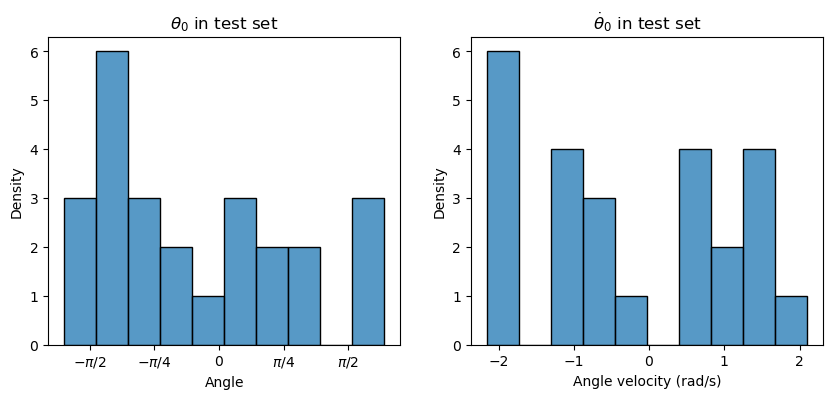

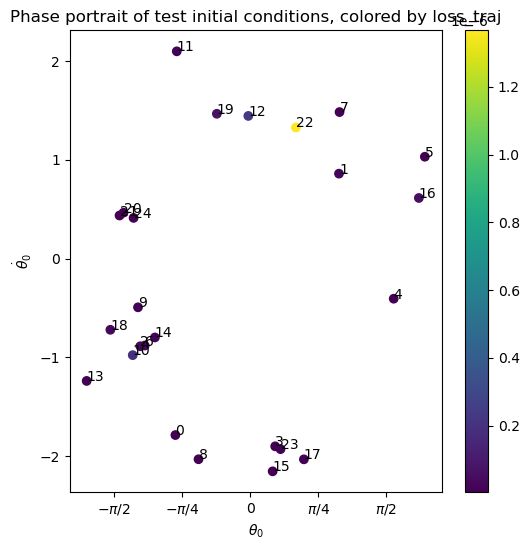

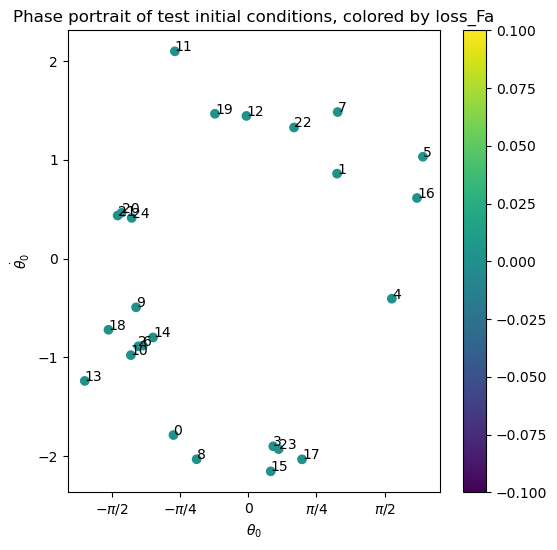

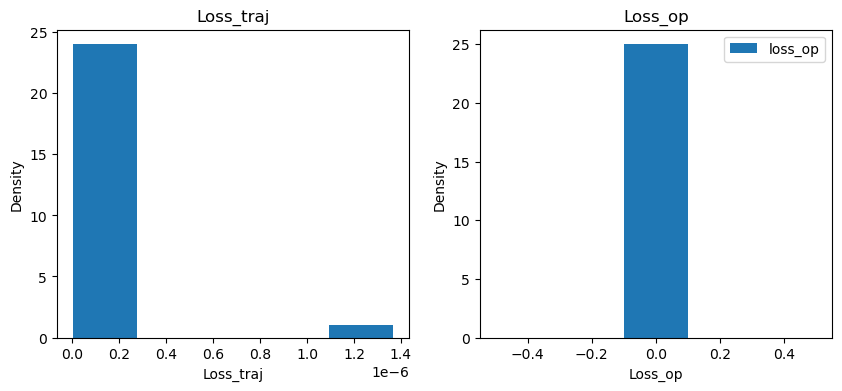

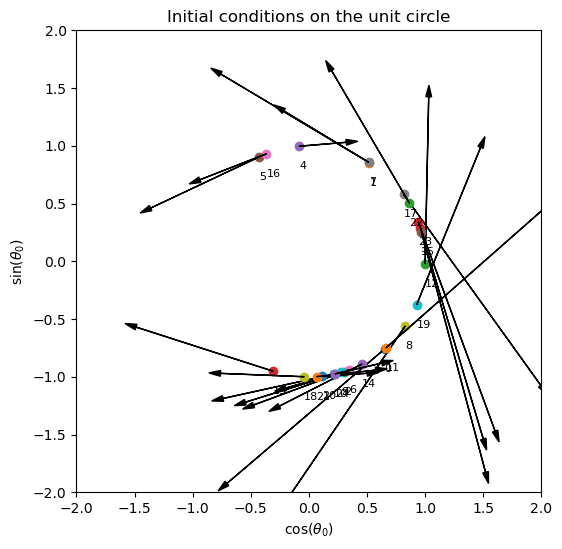

In [25]:
viz_CI_regimes(results_sc1, type="test")

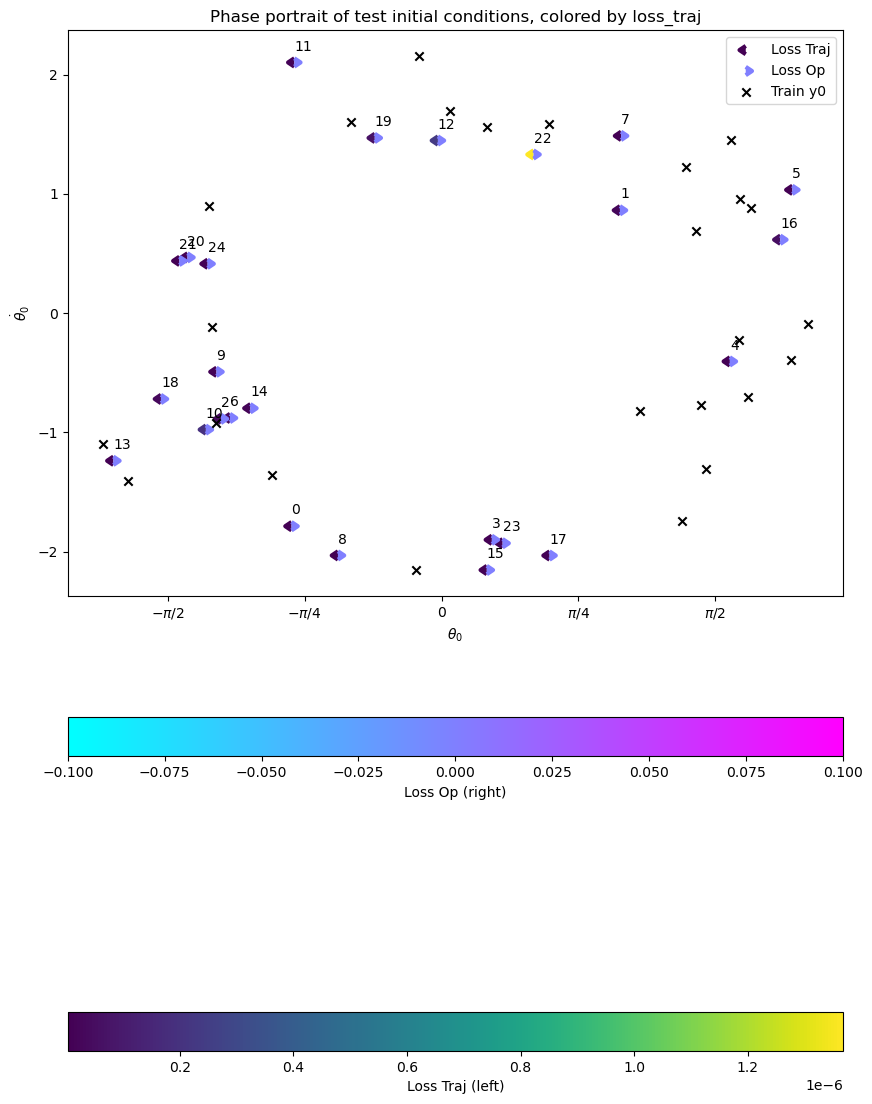

In [26]:
viz_losses_regimes(results_sc1, y0)

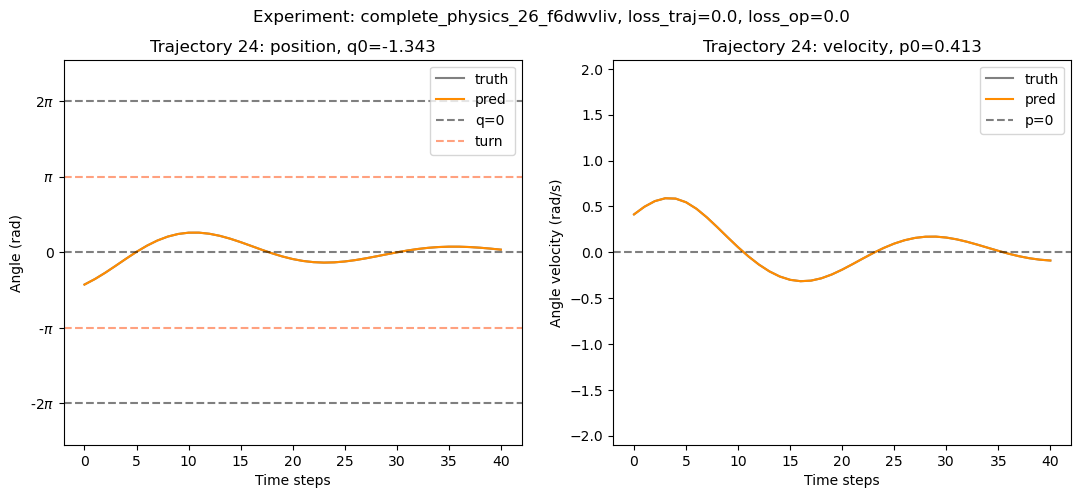

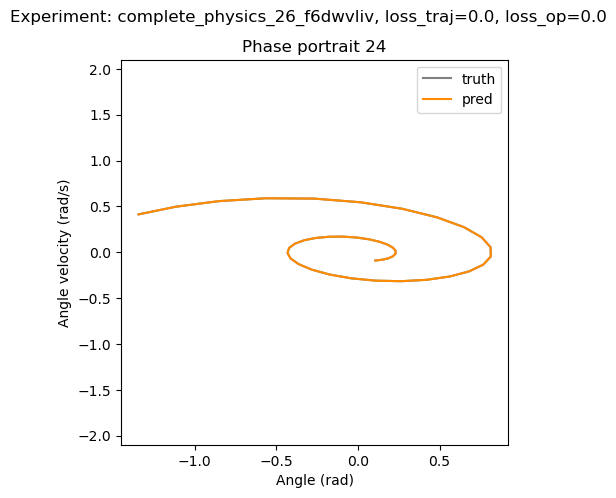

(None, None)

In [19]:
plot_trajectory(results_sc1, exp_name_sc1, 24), plot_phase_trajectory(results_sc1, exp_name_sc1, 24)

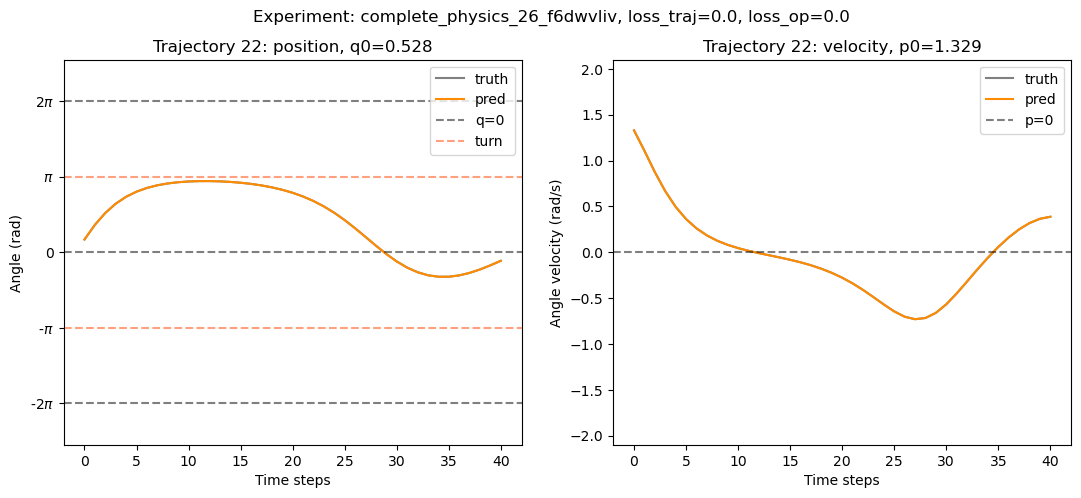

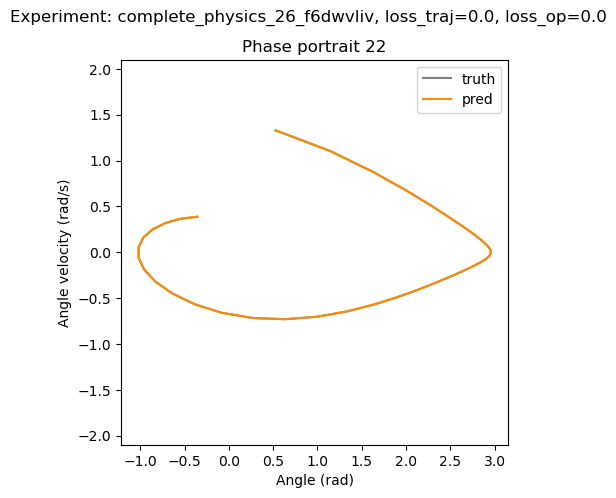

(None, None)

In [20]:
plot_trajectory(results_sc1, exp_name_sc1, 22), plot_phase_trajectory(results_sc1, exp_name_sc1, 22)

## SC2
Final omega: 0.21297499537467957, Final alpha: 0.0

In [29]:
path_sc2 = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_30_q5w7dej1/model_2.017e+00.json"
results_sc2, exp_name_sc2, val_loss_sc2 = load_results(path_sc2)
exp_name_sc2, val_loss_sc2

('incomplete_aug_30_q5w7dej1', 2.017)

In [30]:
results_sc2

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.617866516113281, -2....",0.711065,0.033757,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.322588324546814, 1.56581...",0.622355,1.164388,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.663885354995727, -1.9...",2.619721,0.67526,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.5882192850112911, -1...",0.621528,0.033912,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.326478719711303, 0.9668...",0.641329,2.4604,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.445233106613159, 2.8132...",0.047546,0.000842,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.614874839782714, -1.9...",2.177887,0.811577,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.672050714492797, 2.2272...",0.031738,0.001379,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.462558984756469, -2....",0.816079,0.034698,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.544344305992126, -1.7...",0.925543,2.439538,-1.292473,-0.493132


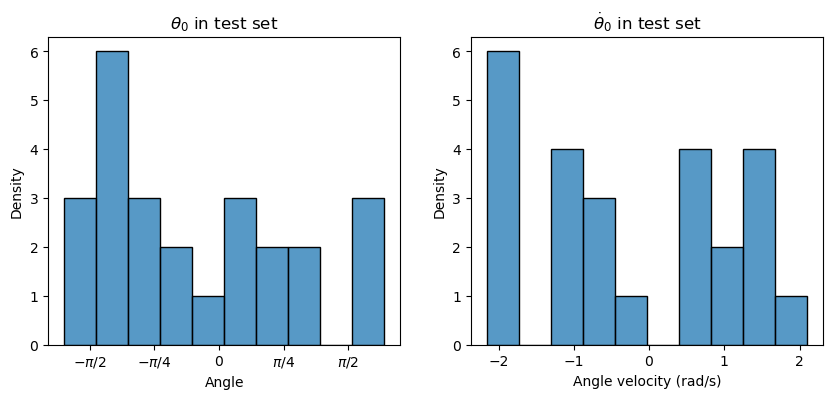

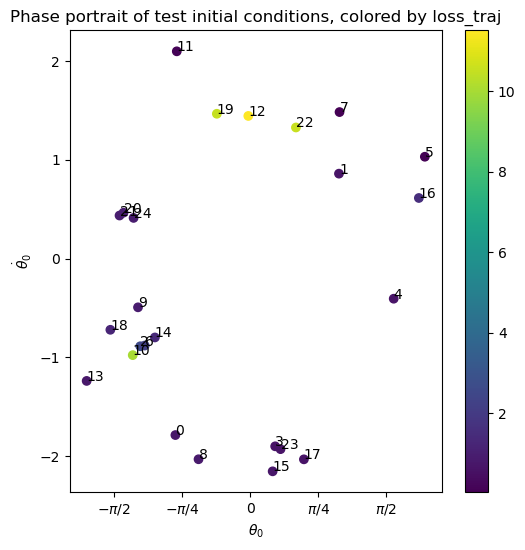

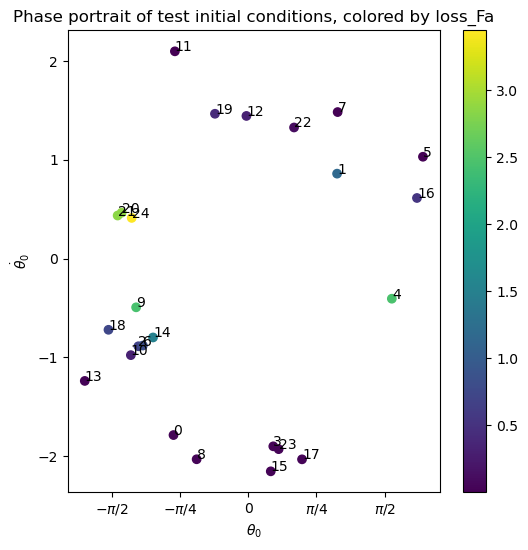

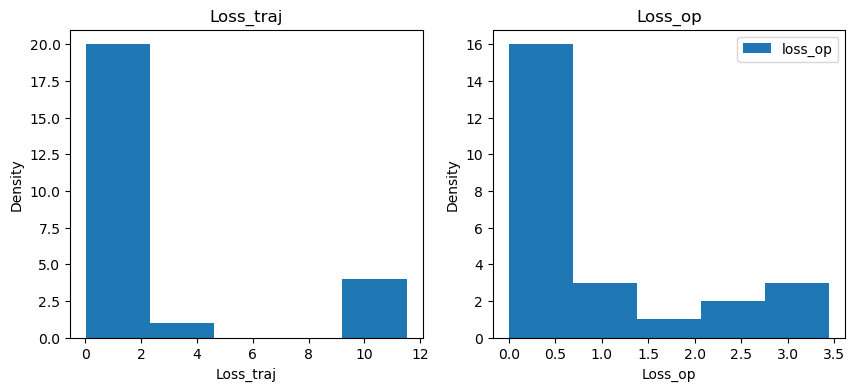

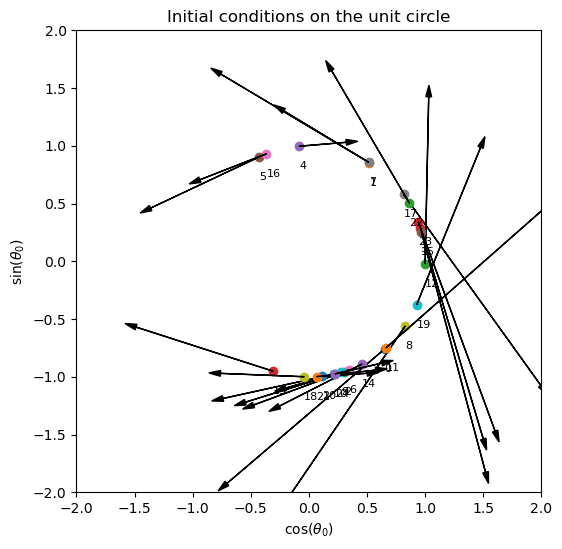

In [31]:
viz_CI_regimes(results_sc2)

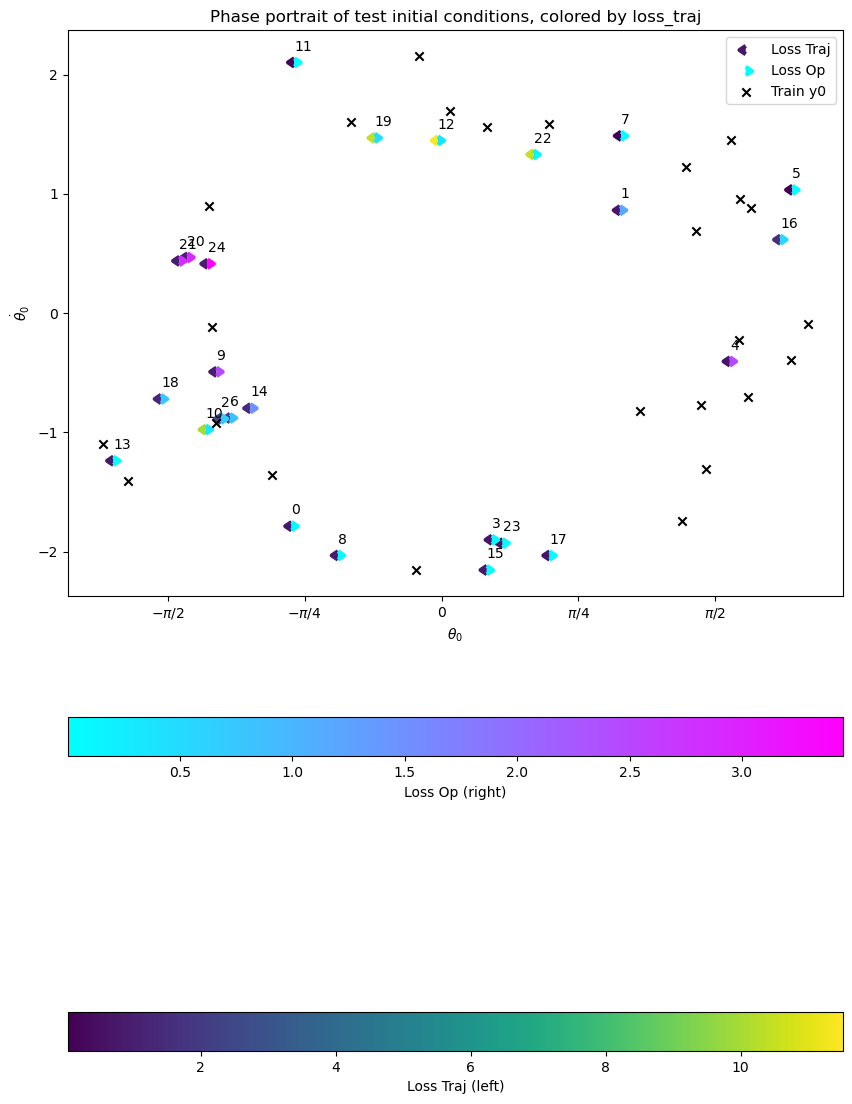

In [32]:
viz_losses_regimes(results_sc2, y0)

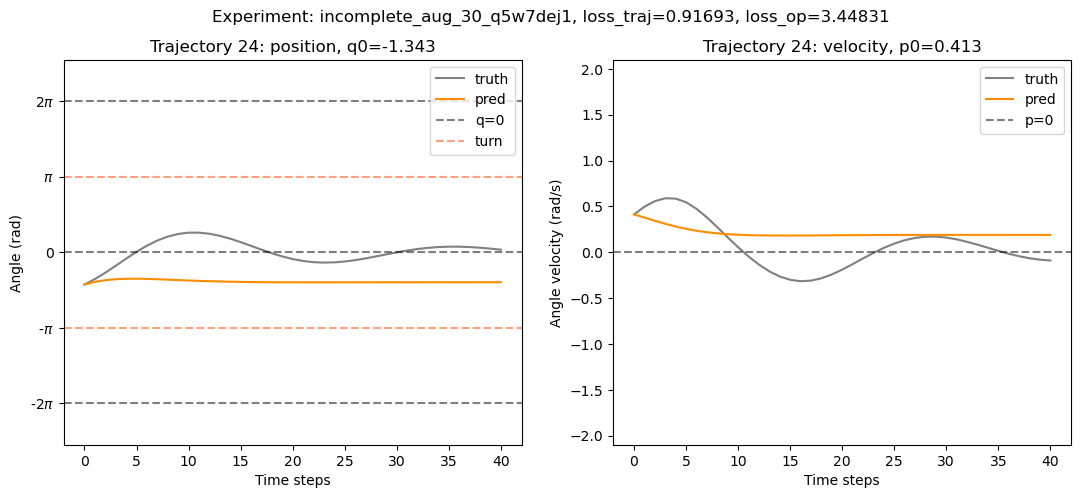

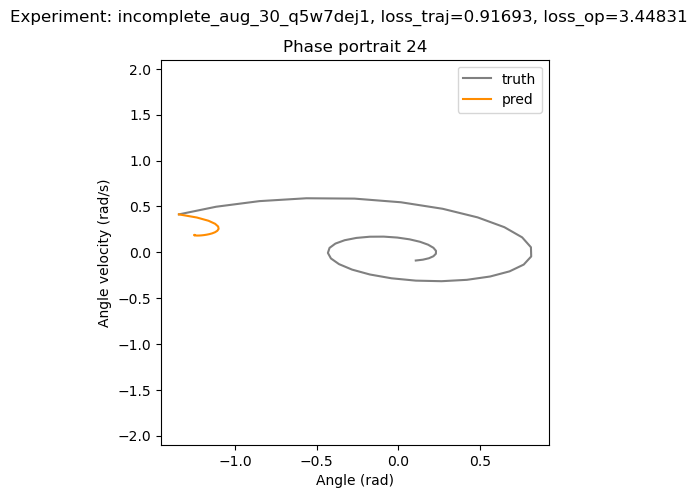

(None, None)

In [33]:
plot_trajectory(results_sc2, exp_name_sc2, 24), plot_phase_trajectory(results_sc2, exp_name_sc2, 24)

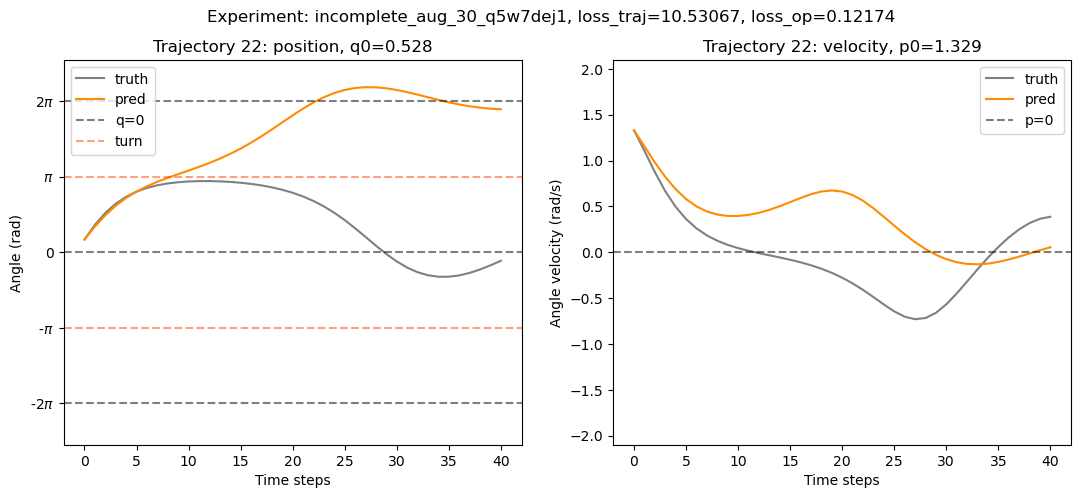

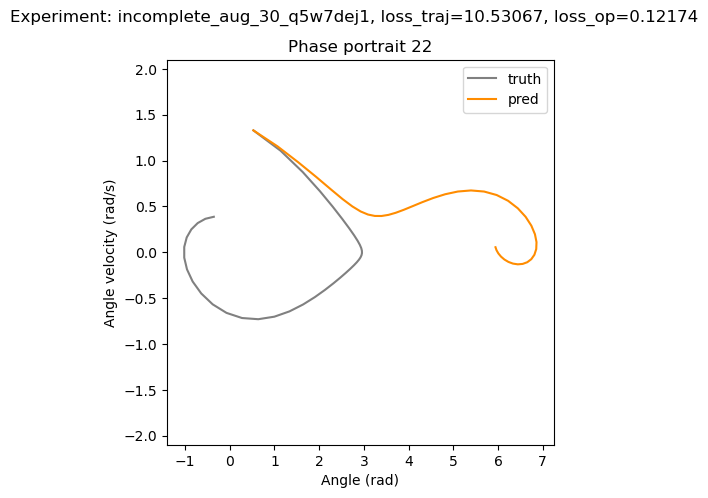

(None, None)

In [34]:
plot_trajectory(results_sc2, exp_name_sc2, 22), plot_phase_trajectory(results_sc2, exp_name_sc2, 22)

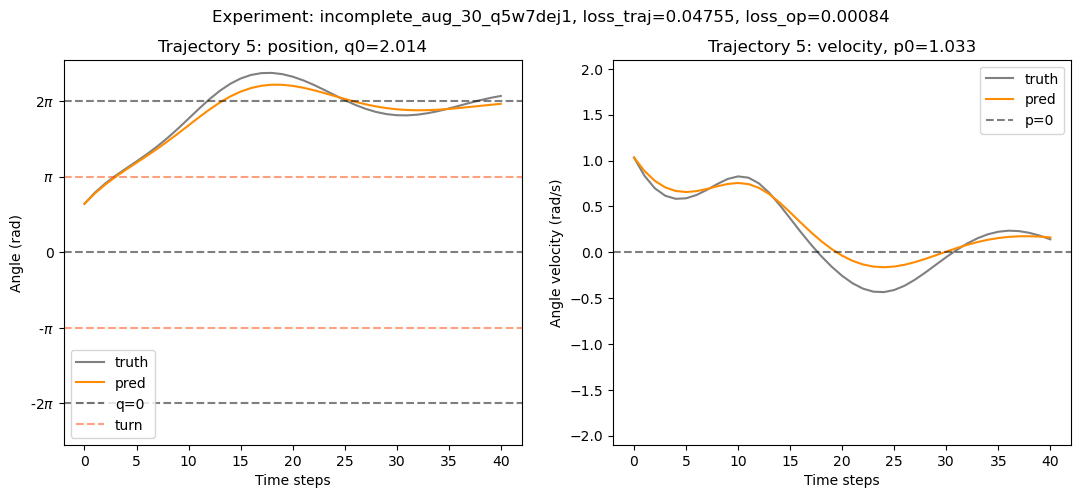

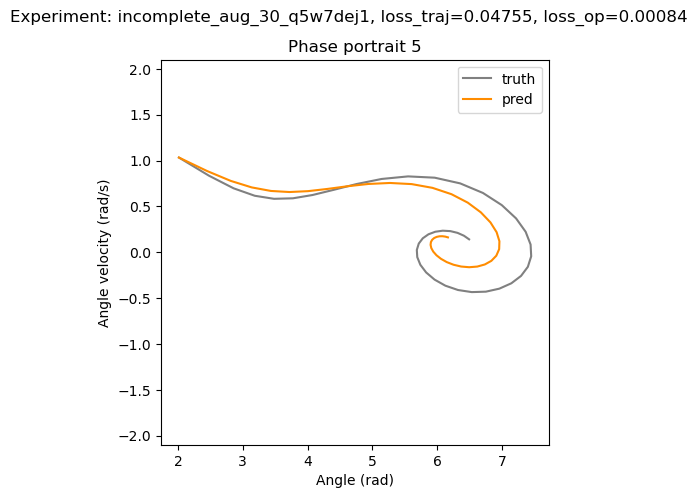

(None, None)

In [35]:
plot_trajectory(results_sc2, exp_name_sc2, 5), plot_phase_trajectory(results_sc2, exp_name_sc2, 5)

In [155]:
results_sc2_fa = pd.read_json("/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_30_q5w7dej1/model_2.017e+00_Fa.json").T

In [38]:
import jax.numpy as jnp

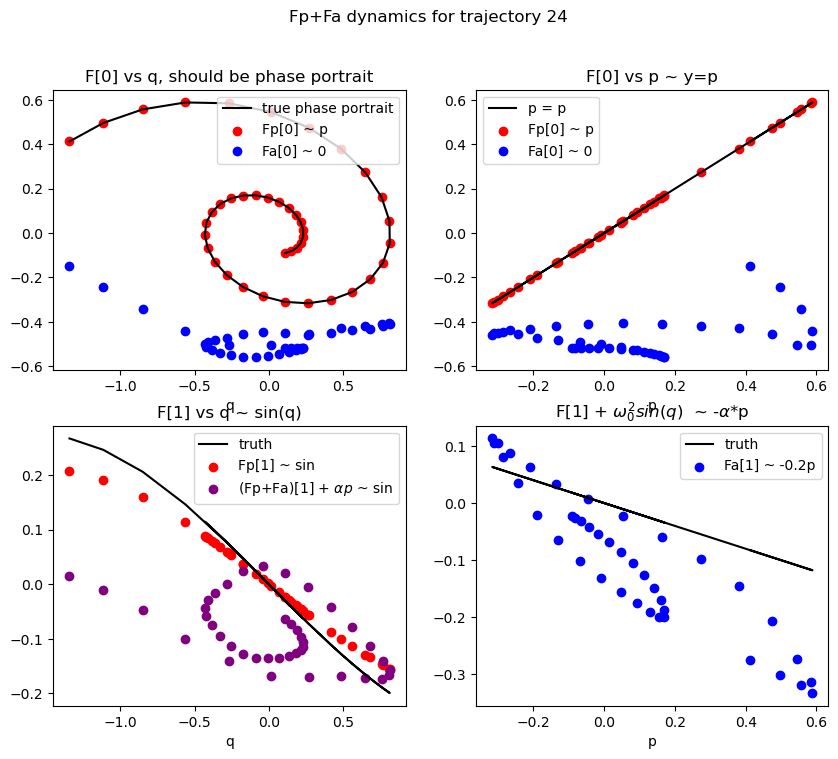

In [39]:
plot_Fp_Fa_out(results_sc2_fa, 24)

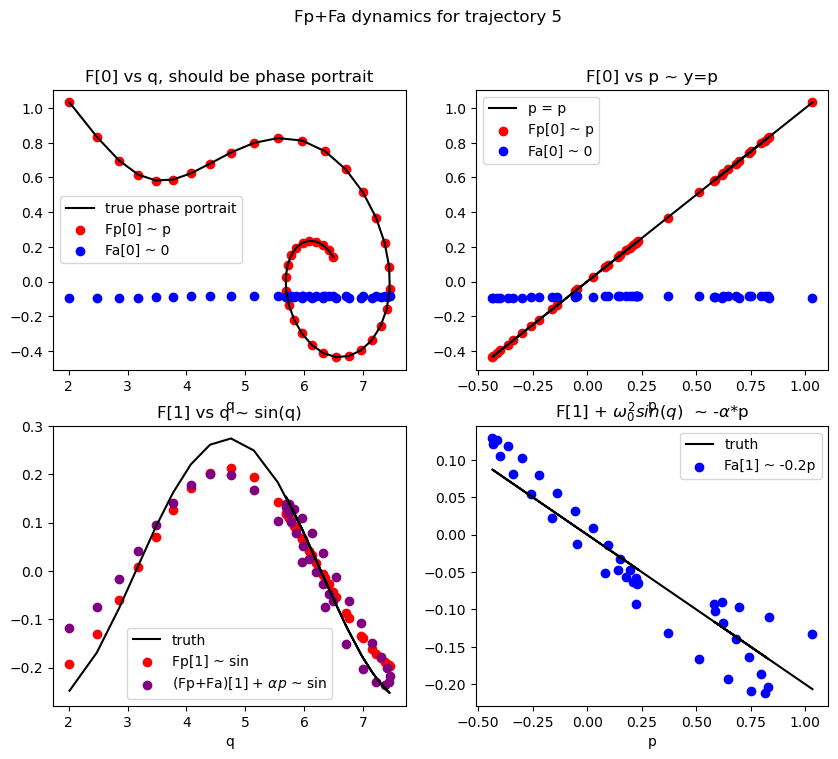

In [40]:
plot_Fp_Fa_out(results_sc2_fa, 5)

## SC2: min_op=l2, $\lambda_0=10$, $\tau_2=100$
Final omega: 0.2598634362220764, Final alpha: 0.0
Loss_op = 1.1e-2

In [28]:
path_sc2_l2_opt = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_34_lx8y2wmb/model_4.318e-03.json"
results_sc2_l2_opt, exp_name_sc2_l2_opt, val_loss_sc2_l2_opt = load_results(path_sc2_l2_opt)
exp_name_sc2_l2_opt, val_loss_sc2_l2_opt

('incomplete_aug_34_lx8y2wmb', 4.318)

In [31]:
results_sc2_l2_opt["loss_traj"].mean(), results_sc2_l2_opt["loss_op"].mean()

(0.12202625477802893, 0.01113047290593324)

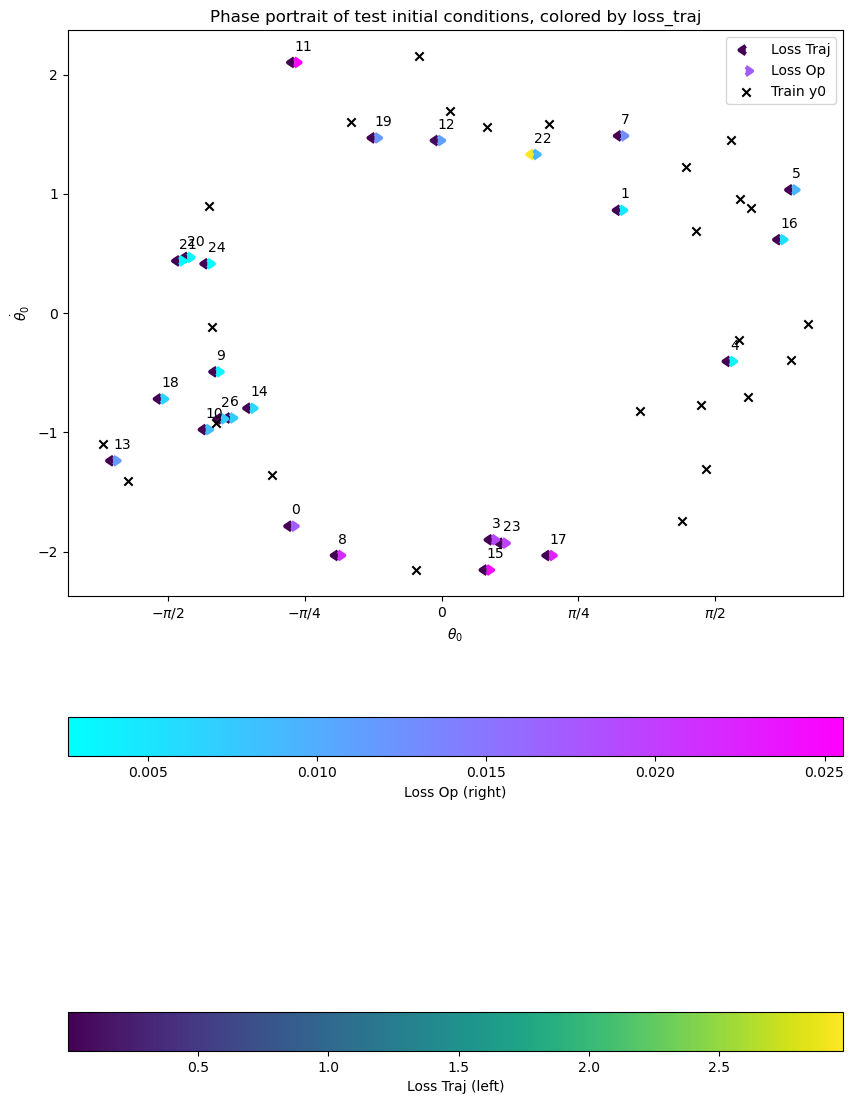

In [29]:
viz_losses_regimes(results_sc2_l2_opt, y0)

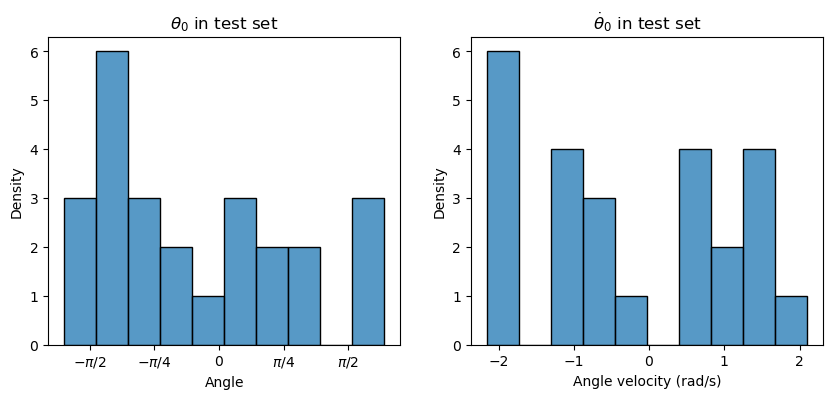

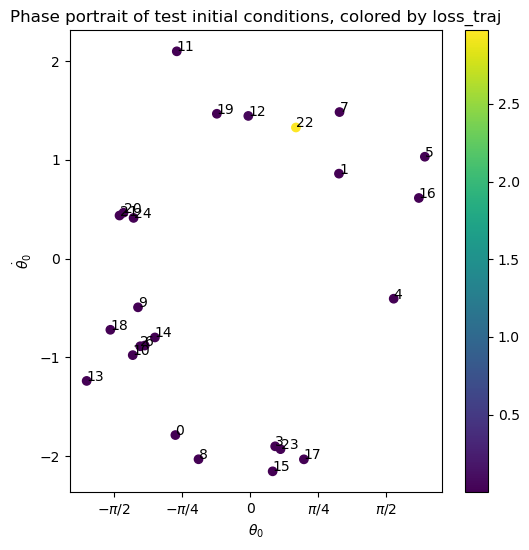

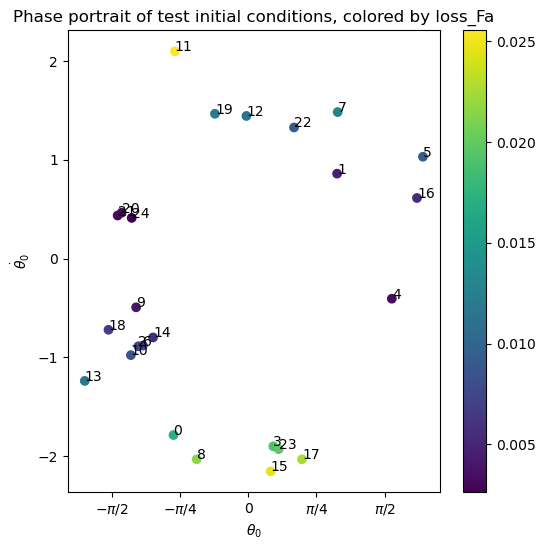

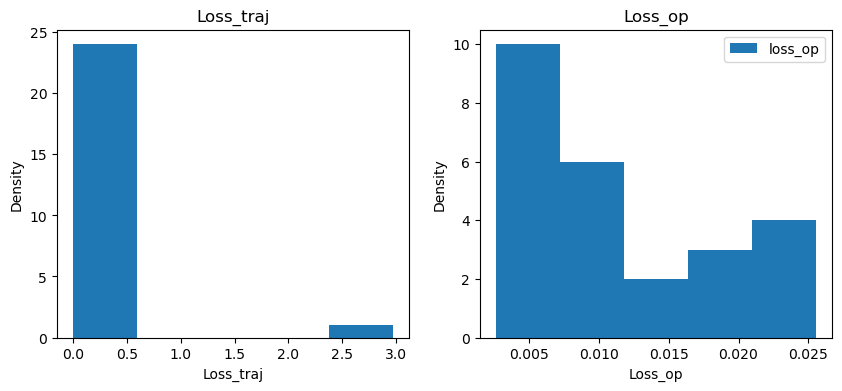

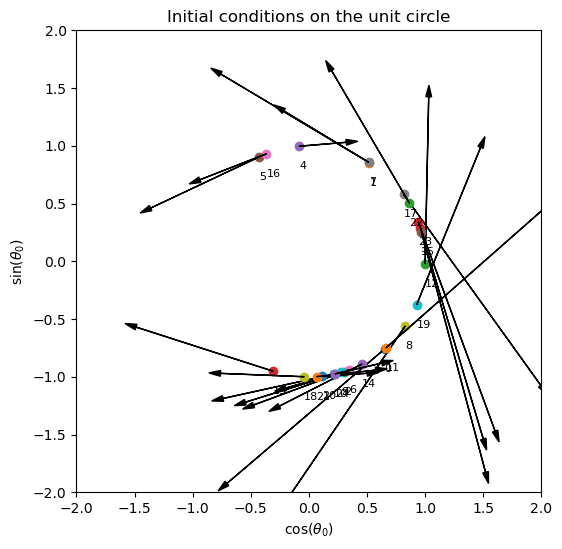

In [30]:
viz_CI_regimes(results_sc2_l2_opt)

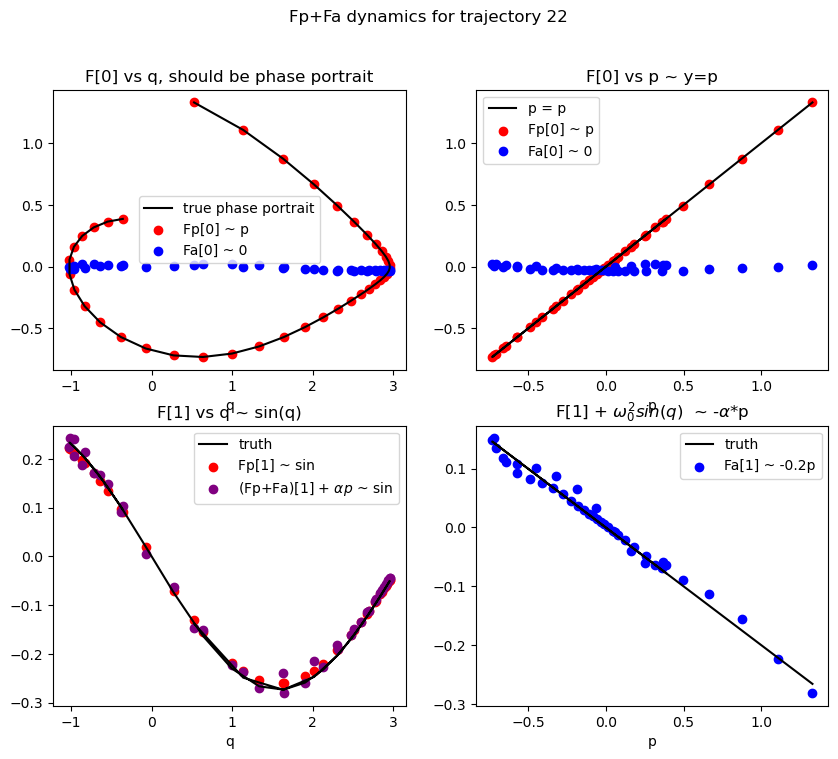

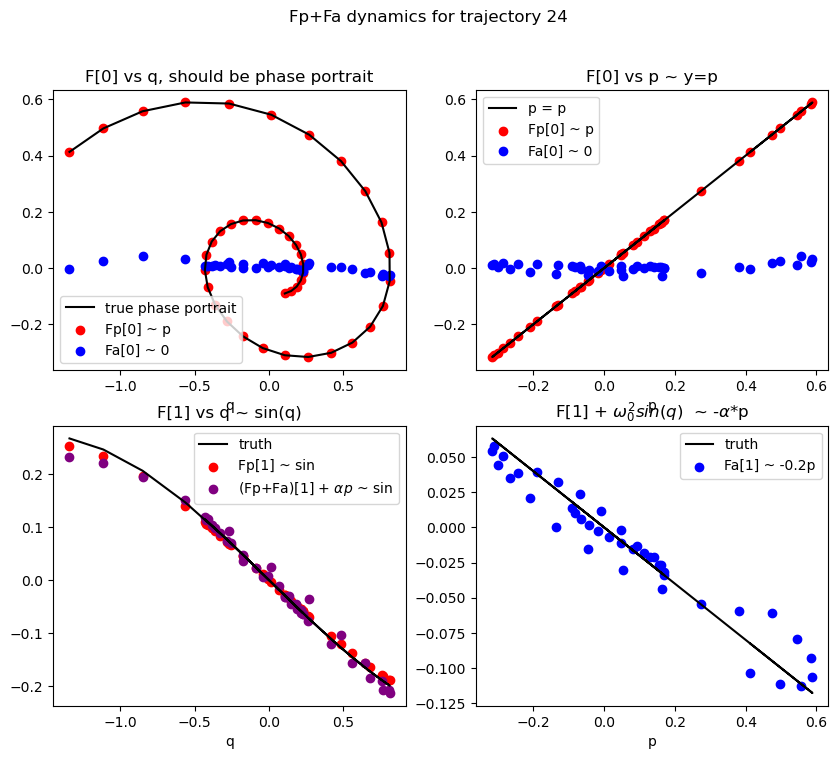

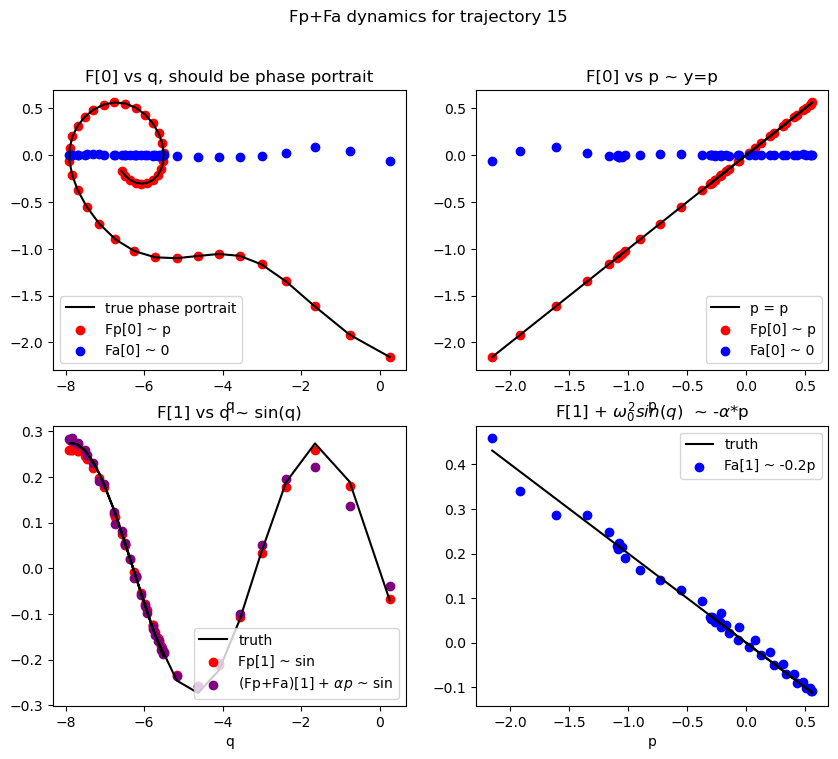

In [161]:
path_sc2_l2_opt_fa = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_aug_34_lx8y2wmb/model_4.318e-03_Fa.json"
results_sc2_l2_opt_fa = pd.read_json(path_sc2_l2_opt_fa).T
plot_Fp_Fa_out(results_sc2_l2_opt_fa, 22)
plot_Fp_Fa_out(results_sc2_l2_opt_fa, 24)
plot_Fp_Fa_out(results_sc2_l2_opt_fa, 15)

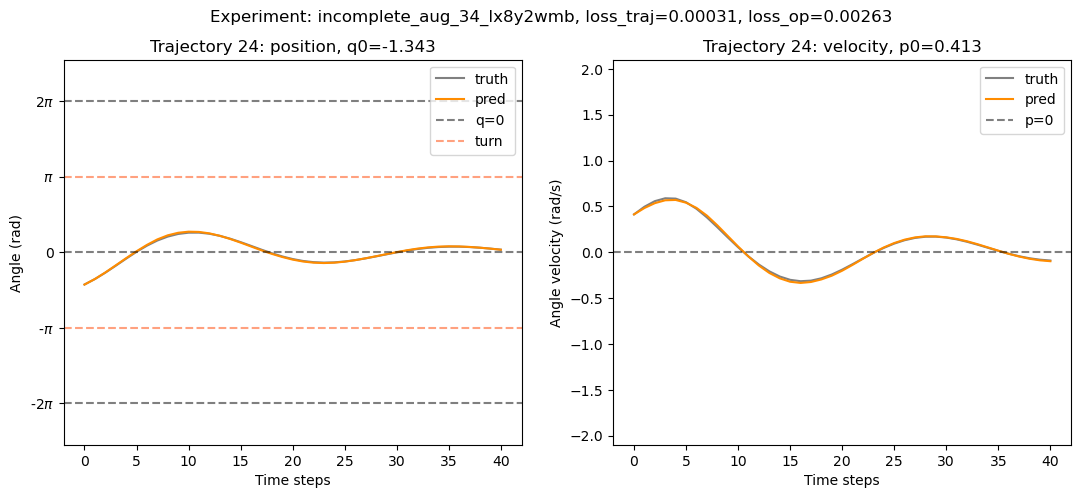

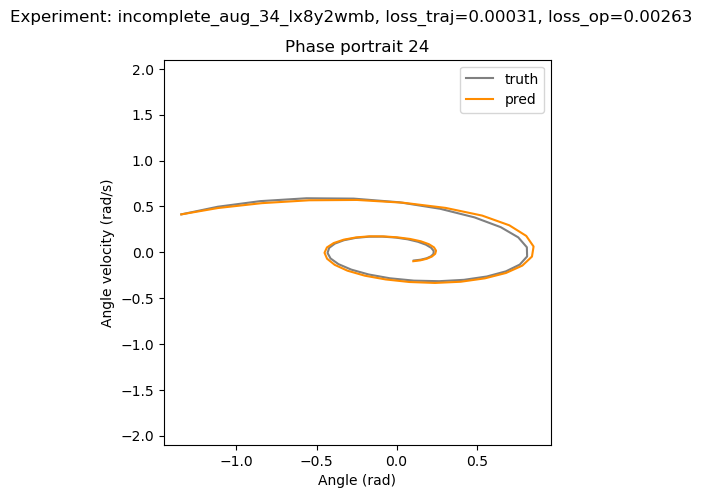

(None, None)

In [ ]:
plot_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 24), plot_phase_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 24)

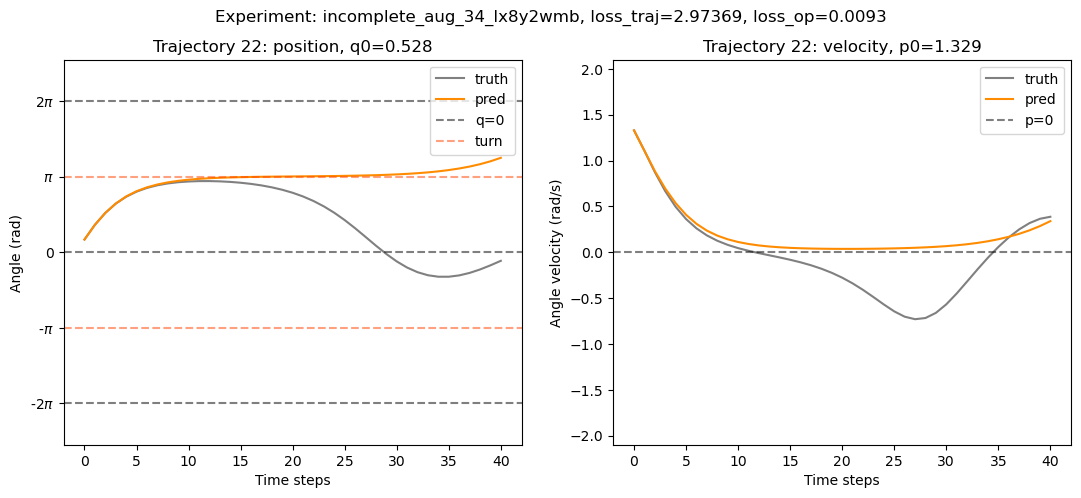

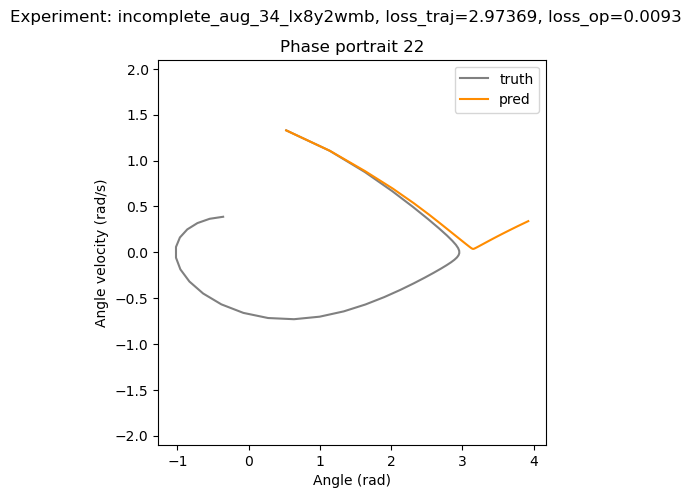

(None, None)

In [34]:
plot_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 22), plot_phase_trajectory(results_sc2_l2_opt, exp_name_sc2_l2_opt, 22)

## SC2.2
Final omega: 0.2089155912399292, Final alpha: 0.0
Loss_op = 9.9e-03

In [17]:
path_sc22 = "/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_no_Fa_aug_28_riymbky6/model_5.693e-03.json"
results_sc22, exp_name_sc22, val_loss_sc22 = load_results(path_sc22)
exp_name_sc22, val_loss_sc22

('incomplete_no_Fa_aug_28_riymbky6', 5.693)

In [18]:
results_sc22["loss_op"].mean()

0.00990516677033112

In [156]:
results_sc22_fa = pd.read_json("/Users/mayajanvier/jax-phynity/data/sanity_checks2/incomplete_no_Fa_aug_28_riymbky6/model_5.693e-03_Fa.json").T

In [20]:
results_sc22

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.593319177627563, -2....",0.001112,0.002196,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.39506983757019, 1.665999...",0.000269,0.015323,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.654339671134948, -1.9...",0.000358,0.012543,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.5541028976440431, -1...",0.004275,0.003332,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.421083211898803, 1.1506...",0.000265,0.015898,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.470595836639404, 2.8466...",0.000748,0.000727,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.598467230796814, -1.8...",0.000377,0.013109,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.705742359161377, 2.2512...",0.000345,0.001984,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.427940368652343, -2....",0.001998,0.002563,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.50156569480896, -1.62...",0.000359,0.01811,-1.292473,-0.493132


In [25]:
results_sc22["loss_traj"].mean()

0.019779989697271443

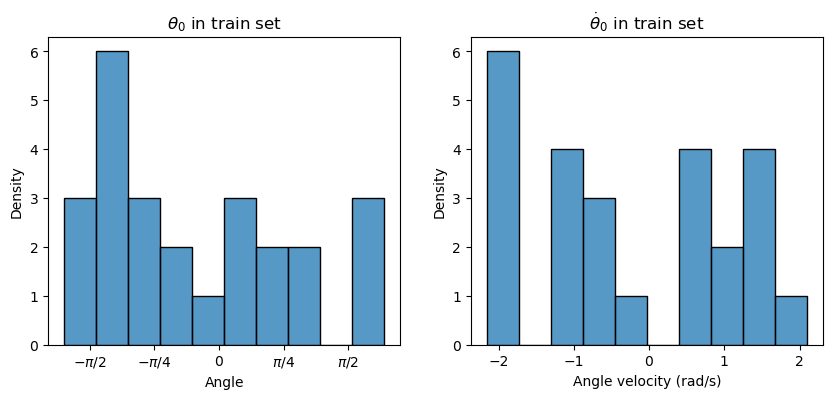

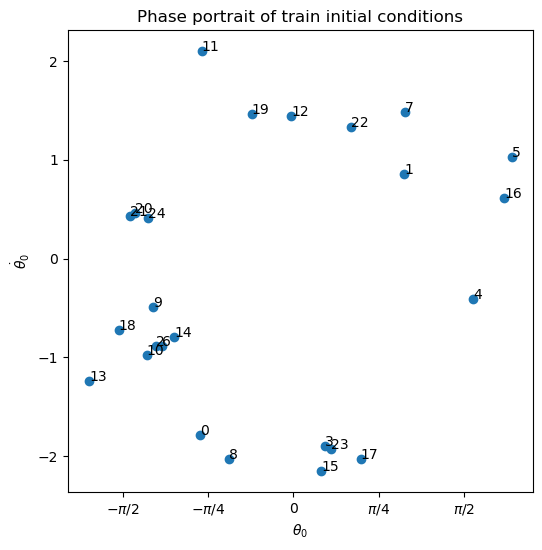

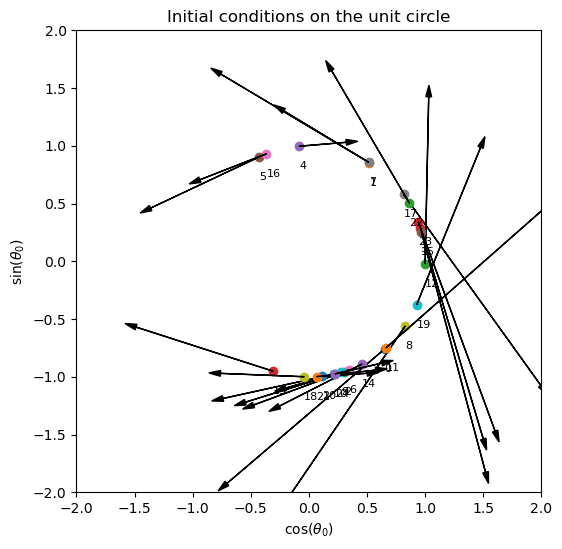

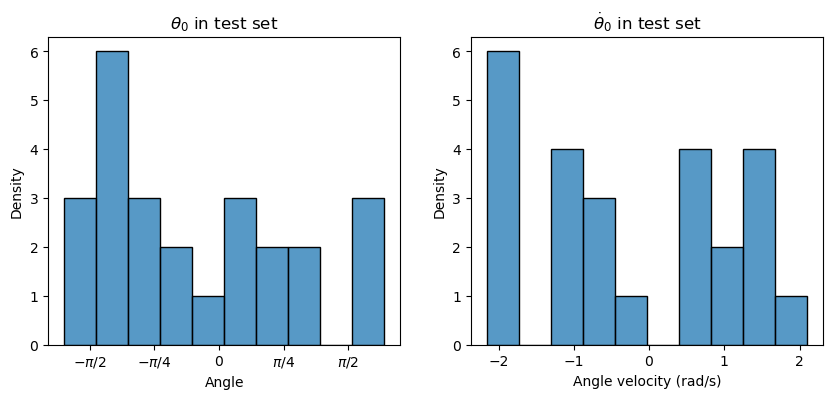

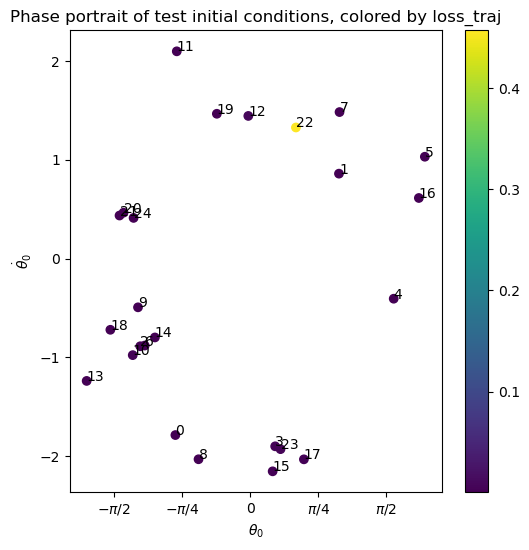

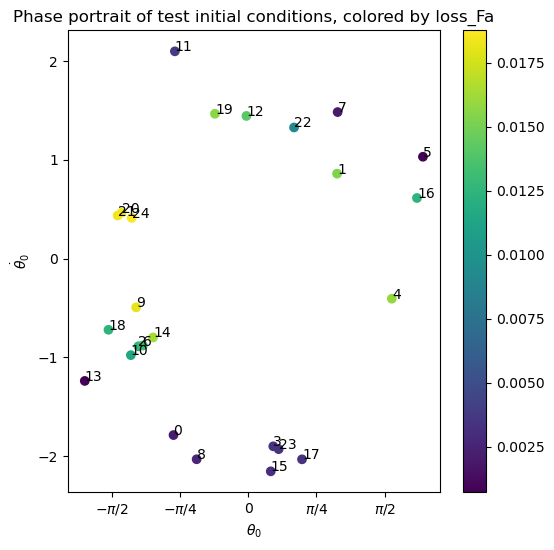

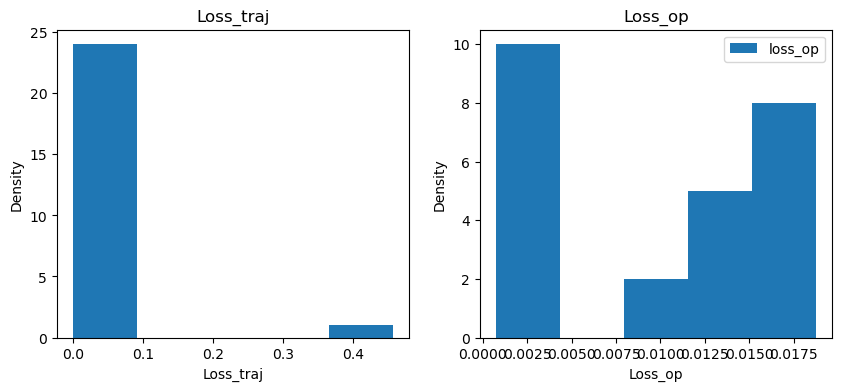

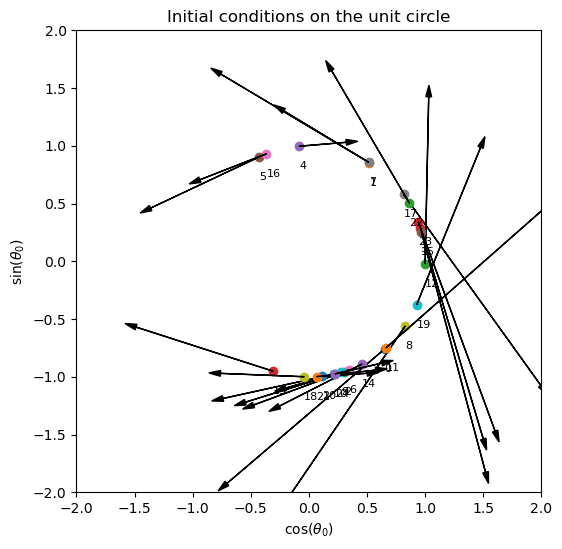

In [21]:
viz_CI_regimes(results_sc22, "train")
viz_CI_regimes(results_sc22, "test")

In [22]:
results_sc22_without22 = results_sc22.drop(22)
results_sc22_without22

,states,pred,loss_traj,loss_op,q0,p0
0,"[[-0.8616502881050111, -1.6825517416000362, -2...","[[-0.8616502881050111, -1.593319177627563, -2....",0.001112,0.002196,-0.861650,-1.787651
1,"[[1.02391505241394, 1.403509378433227, 1.68330...","[[1.02391505241394, 1.39506983757019, 1.665999...",0.000269,0.015323,1.023915,0.861401
2,"[[-1.266593933105468, -1.656404495239257, -1.9...","[[-1.266593933105468, -1.654339671134948, -1.9...",0.000358,0.012543,-1.266594,-0.887698
3,"[[0.28855118155479403, -0.615474939346313, -1....","[[0.28855118155479403, -0.5541028976440431, -1...",0.004275,0.003332,0.288551,-1.901630
4,"[[1.654847264289856, 1.428605318069458, 1.1597...","[[1.654847264289856, 1.421083211898803, 1.1506...",0.000265,0.015898,1.654847,-0.405910
5,"[[2.013660907745361, 2.47798490524292, 2.85836...","[[2.013660907745361, 2.470595836639404, 2.8466...",0.000748,0.000727,2.013661,1.032762
6,"[[-1.214775919914245, -1.6014490127563472, -1....","[[-1.214775919914245, -1.598467230796814, -1.8...",0.000377,0.013109,-1.214776,-0.880412
7,"[[1.030321478843689, 1.70587944984436, 2.25445...","[[1.030321478843689, 1.705742359161377, 2.2512...",0.000345,0.001984,1.030321,1.485462
8,"[[-0.5949302911758421, -1.5363876819610591, -2...","[[-0.5949302911758421, -1.427940368652343, -2....",0.001998,0.002563,-0.594930,-2.032865
9,"[[-1.292472839355468, -1.494676113128662, -1.6...","[[-1.292472839355468, -1.50156569480896, -1.62...",0.000359,0.01811,-1.292473,-0.493132


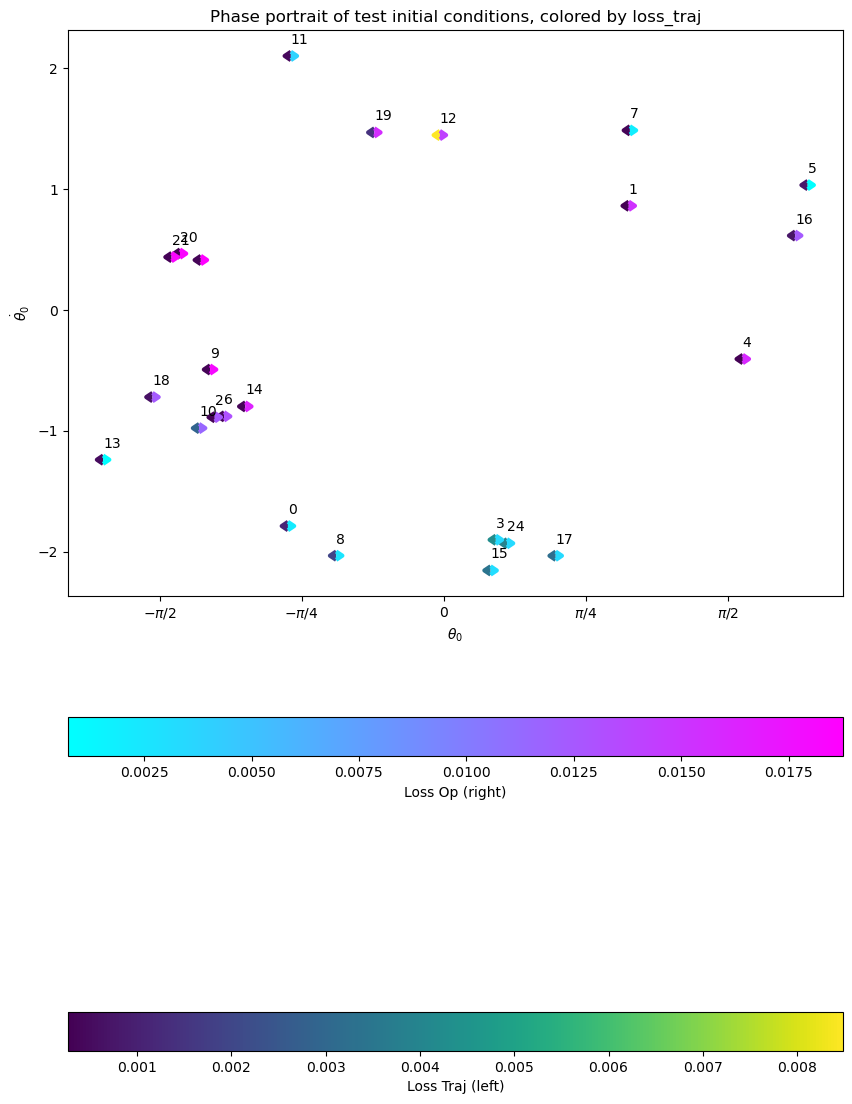

In [41]:
res = results_sc22_without22
type="test"
fig, ax = plt.subplots(1,1,figsize=(10, 15))
delta=0.1
# put index of traj above the point
for i, txt in enumerate(res.index):
    if i == 22:
        pass
    else:
        ax.annotate(txt, (res["q0"][i], res["p0"][i]+ delta))
# half circle with loss traj and other loss op
#plt.scatter(res["q0"], res["p0"], label="Initial conditions", c=res["loss_traj"], cmap="viridis")
# do same with 2 metrics on same scatter
# Scatter plot for left half (loss_traj)
sc1 = ax.scatter(res["q0"], res["p0"], c=res["loss_traj"], cmap="viridis", marker=8, label="Loss Traj", linewidths=3)

# Scatter plot for right half (loss_op)
sc2 = ax.scatter(res["q0"], res["p0"], c=res["loss_op"], cmap="cool", marker=9, label="Loss Op", linewidths=3)

# Add colorbars
cbar1 = plt.colorbar(sc1, ax=ax, label="Loss Traj (left)", orientation="horizontal")
cbar2 = plt.colorbar(sc2, ax=ax, label="Loss Op (right)", orientation="horizontal")

plt.title(f"Phase portrait of {type} initial conditions, colored by loss_traj")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\dot{\theta}_0$")
ax.set_xticks([-np.pi/2, -np.pi/4, 0, np.pi/4, np.pi/2])
ax.set_xticklabels(["$-\pi/2$", "$-\pi/4$", "0","$\pi/4$", "$\pi/2$"])
plt.show()

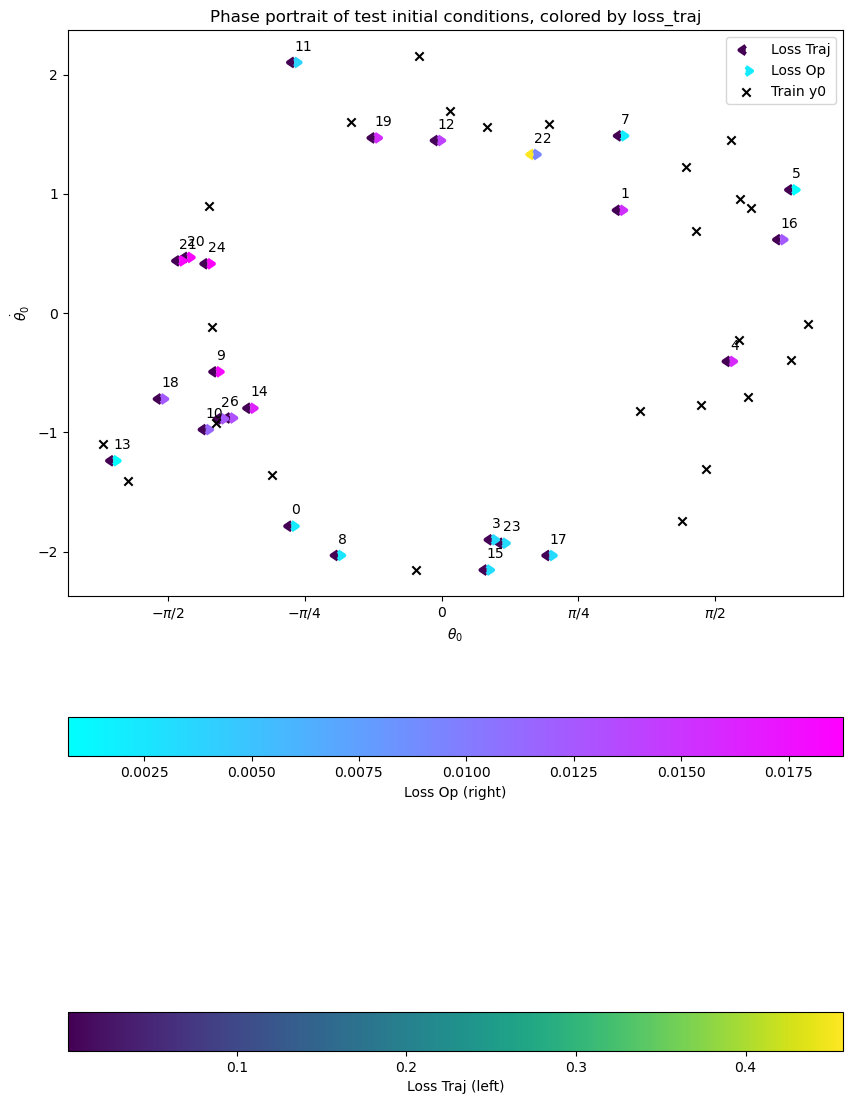

In [42]:
viz_losses_regimes(results_sc22, y0)

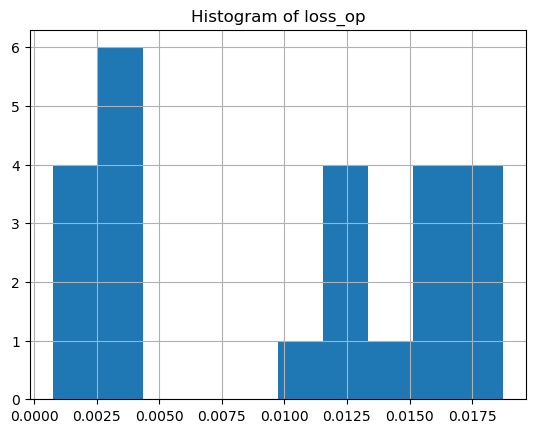

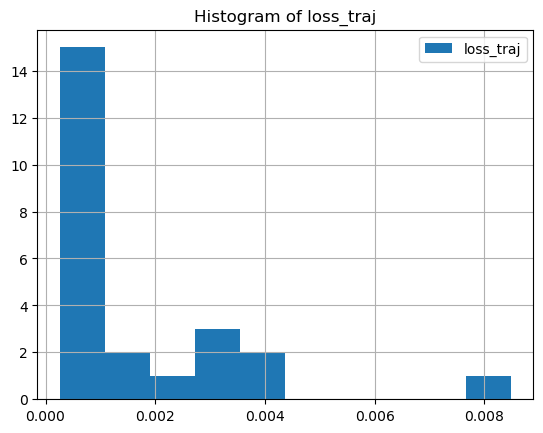

In [43]:
results_sc22_without22["loss_op"].hist(label="loss_op")
plt.title("Histogram of loss_op")
plt.show()
plt.figure()
results_sc22_without22["loss_traj"].hist(label="loss_traj")
plt.title("Histogram of loss_traj")
plt.legend()

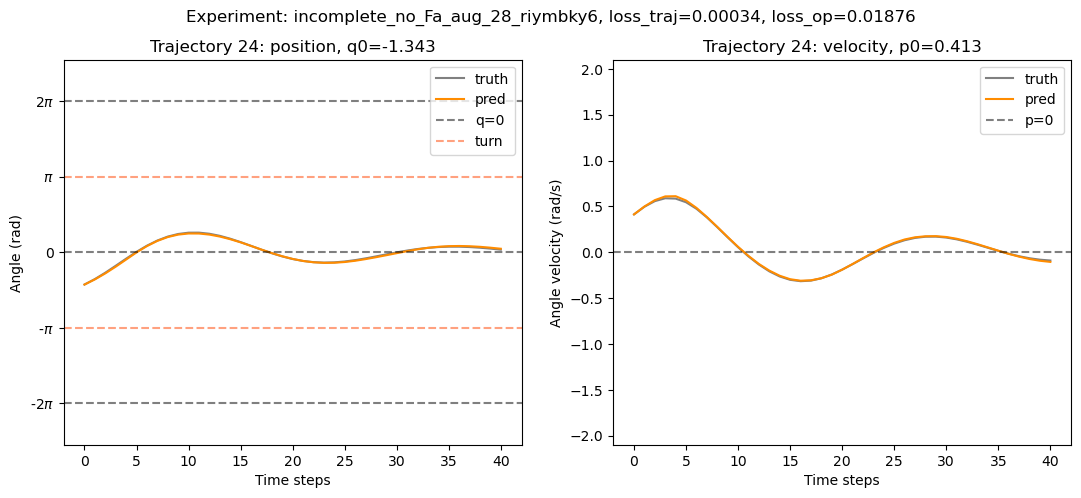

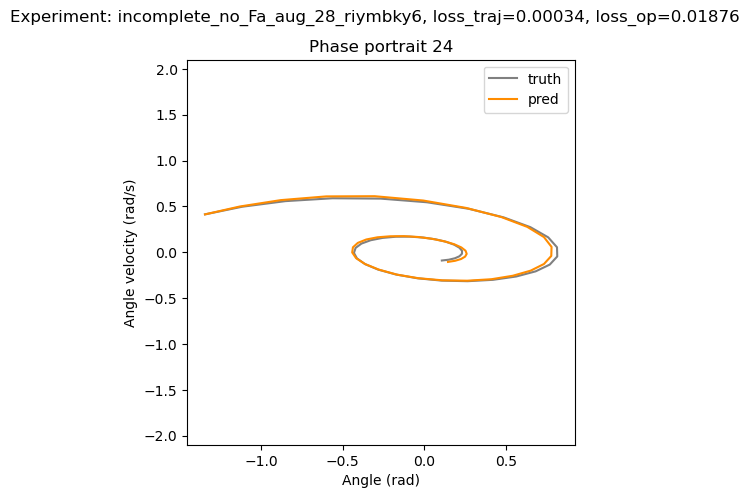

(None, None)

In [24]:
plot_trajectory(results_sc22, exp_name_sc22, 24), plot_phase_trajectory(results_sc22, exp_name_sc22, 24)

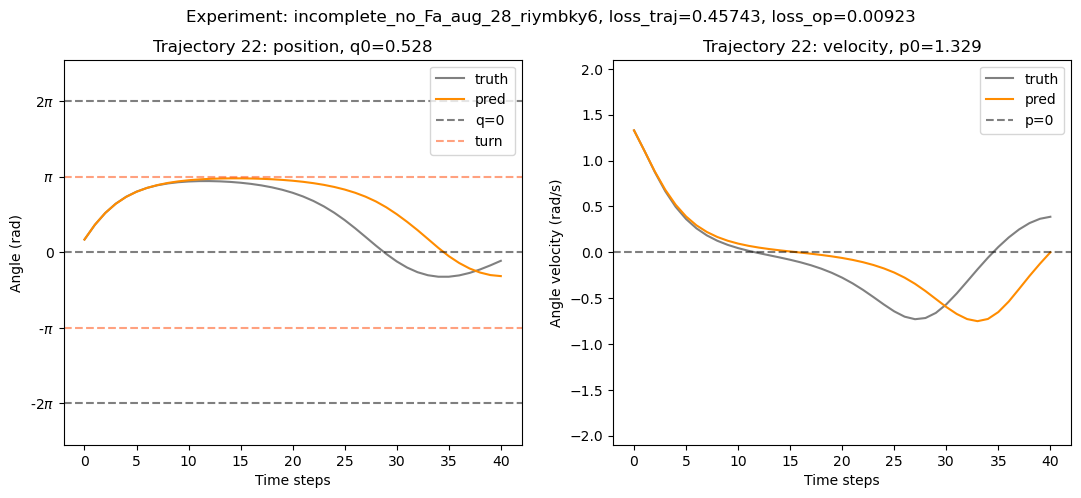

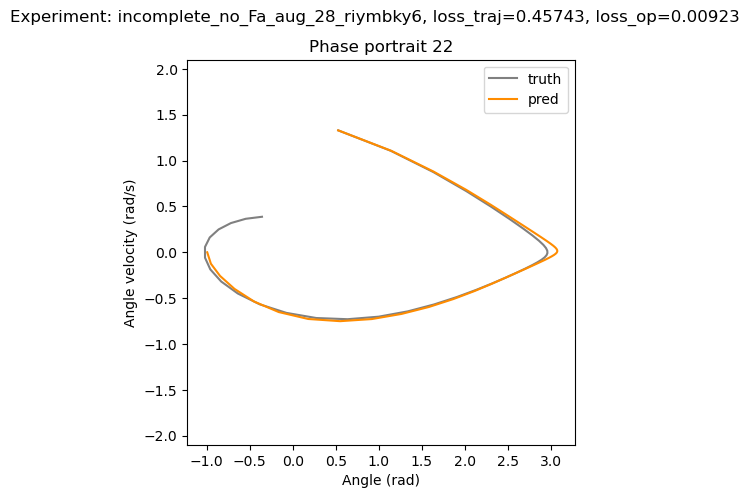

(None, None)

In [45]:
plot_trajectory(results_sc22, exp_name_sc22, 22), plot_phase_trajectory(results_sc22, exp_name_sc22, 22)

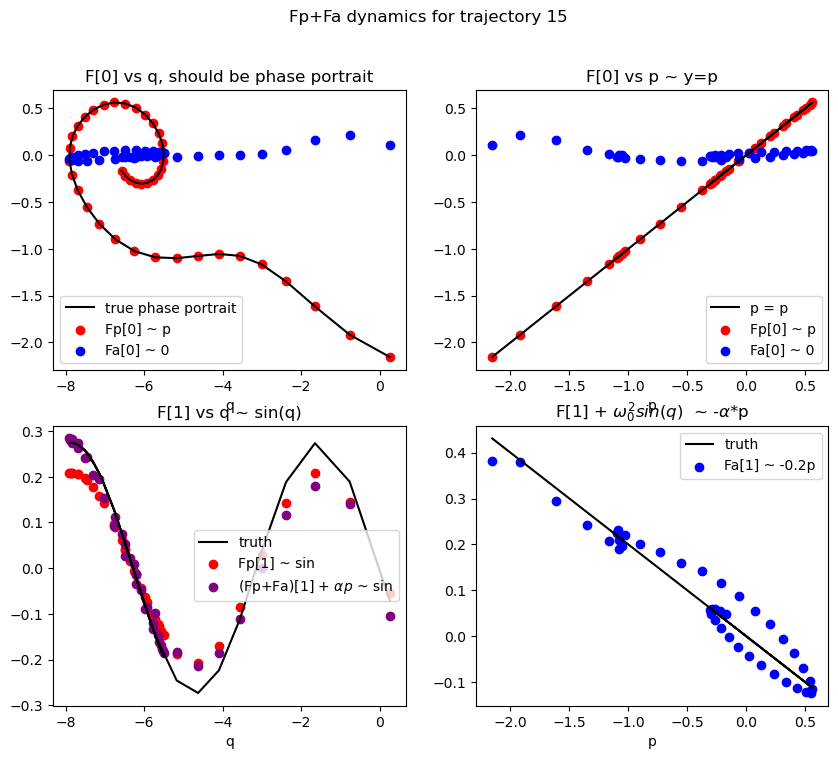

In [101]:
import jax.numpy as jnp
plot_Fp_Fa_out(results_sc22_fa, 15)

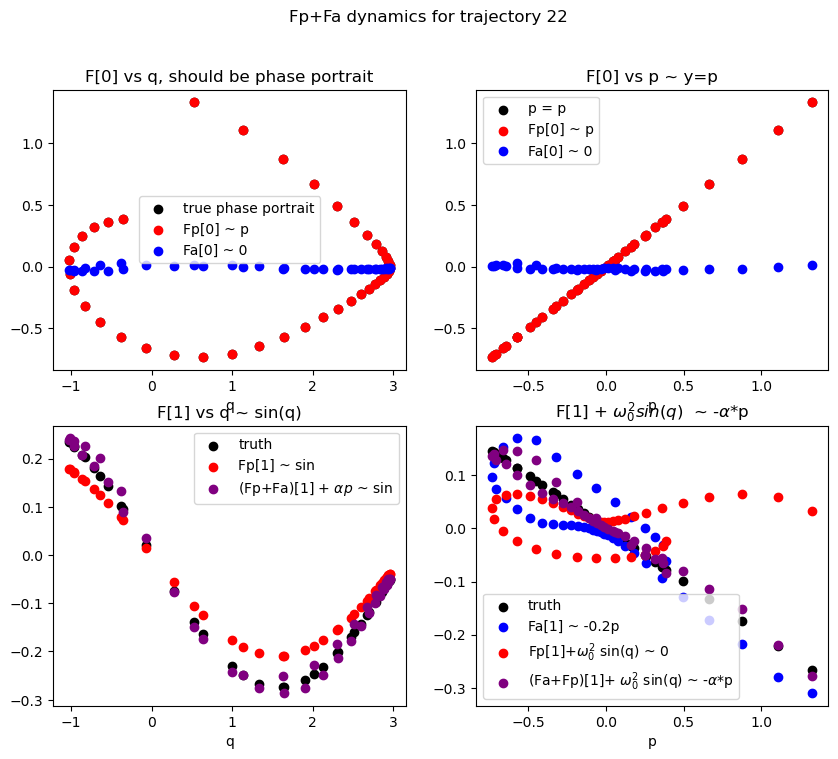

In [103]:
plot_Fp_Fa_out(results_sc22_fa, 22)

0.3759573102178561

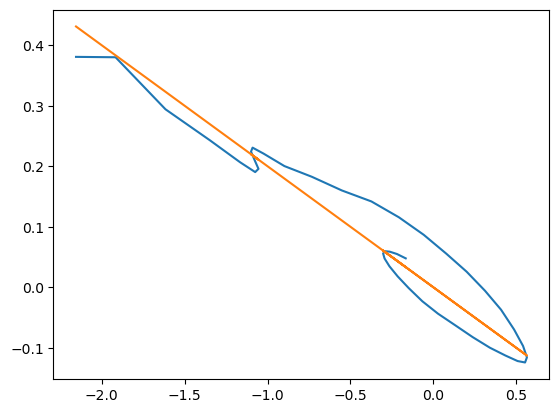

In [152]:
plt.plot(np.array(results_sc22_fa["states"][15])[:,1], np.array(results_sc22_fa["Fa"][15])[:,1])
plt.plot(np.array(results_sc22_fa["states"][15])[:,1], -0.2* np.array(results_sc22_fa["states"][15])[:,1])
np.mean(np.abs(np.array(results_sc22_fa["Fa"][k])[:,1]/np.array(results_sc22_fa["states"][k])[:,1]))


0.7252188921661014

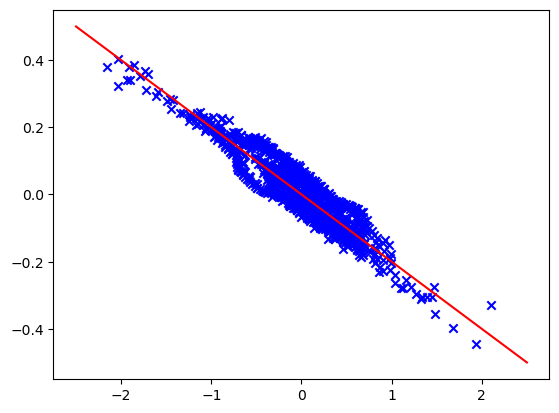

In [160]:
results_sc22_fa
#plt.plot(np.array(results_sc22_fa["Fa"][15])[:,0])
points = []
for k in range(25):
    plt.scatter(np.array(results_sc22_fa["states"][k])[:,1], np.array(results_sc22_fa["Fa"][k])[:,1], color="blue", marker='x')
    points.append(np.mean(np.abs(np.array(results_sc22_fa["Fa"][k])[:,1]/np.array(results_sc22_fa["states"][k])[:,1] - (-0.2))))
plt.plot(np.arange(-2.5, 3.5), -0.2 * np.arange(-2.5, 3.5), color="red")
np.mean(points)





Text(0, 0.2, '$R^2$ score: 0.97995')

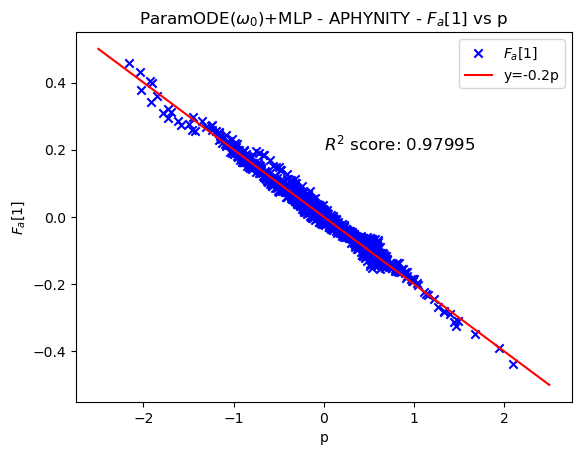

In [174]:
results_sc2_l2_opt_fa
points = []
point_list = []
truth_list = []
for k in range(25):
    point_list.append(np.array(results_sc2_l2_opt_fa["Fa"][k])[:,1])
    truth_list.append(np.array(results_sc2_l2_opt_fa["states"][k])[:,1])
    if k==1: 
        plt.scatter(np.array(results_sc2_l2_opt_fa["states"][k])[:,1], np.array(results_sc2_l2_opt_fa["Fa"][k])[:,1], color="blue", marker='x', label=r"$F_a$[1]")
    else: 
        plt.scatter(np.array(results_sc2_l2_opt_fa["states"][k])[:,1], np.array(results_sc2_l2_opt_fa["Fa"][k])[:,1], color="blue", marker='x')
    points.append(np.mean(np.abs(np.array(results_sc2_l2_opt_fa["Fa"][k])[:,1]/np.array(results_sc2_l2_opt_fa["states"][k])[:,1])))
plt.plot(np.arange(-2.5, 3.5), -0.2 * np.arange(-2.5, 3.5), color="red", label = "y=-0.2p")

# R2
import sklearn
from sklearn.metrics import r2_score
point_list = np.array(point_list).flatten()
truth_list = np.array(truth_list).flatten()
r2_score(-0.2 * truth_list, point_list)

plt.legend()
plt.xlabel("p")
plt.ylabel(r"$F_a[1]$")
plt.title(r"ParamODE($\omega_0$)+MLP - APHYNITY - $F_a$[1] vs p")
# add r2 score above points scattered
plt.text(0, 0.2, rf"$R^2$ score: {round(r2_score(-0.2 * truth_list, point_list), 5)}", fontsize=12)



Text(0, 0.2, '$R^2$ score: 0.8578')

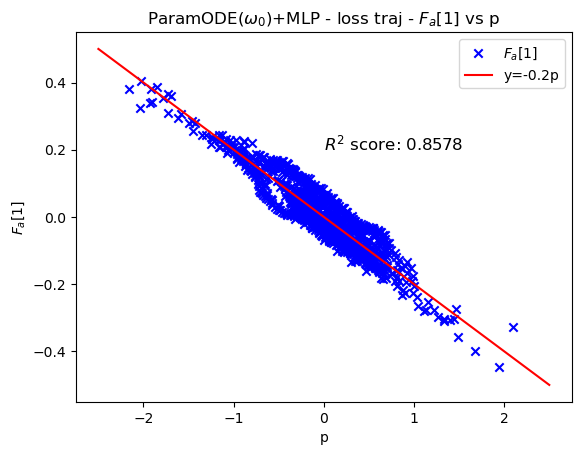

In [177]:
results_sc2_l2_opt_fa
points = []
point_list = []
truth_list = []
for k in range(25):
    point_list.append(np.array(results_sc22_fa["Fa"][k])[:,1])
    truth_list.append(np.array(results_sc22_fa["states"][k])[:,1])
    if k==1: 
        plt.scatter(np.array(results_sc22_fa["states"][k])[:,1], np.array(results_sc22_fa["Fa"][k])[:,1], color="blue", marker='x', label=r"$F_a$[1]")
    else: 
        plt.scatter(np.array(results_sc22_fa["states"][k])[:,1], np.array(results_sc22_fa["Fa"][k])[:,1], color="blue", marker='x')
    #points.append(np.mean(np.abs(np.array(results_sc22_fa[k])[:,1]/np.array(results_sc22_fa["states"][k])[:,1])))
plt.plot(np.arange(-2.5, 3.5), -0.2 * np.arange(-2.5, 3.5), color="red", label = "y=-0.2p")

# R2
import sklearn
from sklearn.metrics import r2_score
point_list = np.array(point_list).flatten()
truth_list = np.array(truth_list).flatten()
r2_score(-0.2 * truth_list, point_list)

plt.legend()
plt.xlabel("p")
plt.ylabel(r"$F_a[1]$")
plt.title(r"ParamODE($\omega_0$)+MLP - loss traj - $F_a$[1] vs p")
# add r2 score above points scattered
plt.text(0, 0.2, rf"$R^2$ score: {round(r2_score(-0.2 * truth_list, point_list), 5)}", fontsize=12)



## SC3

In [26]:
path_sc3="/Users/mayajanvier/jax-phynity/data/sanity_checks2/none_aug_24_of0iieil/model_3.309e-02.json"
results_sc3, exp_name_sc3, val_loss_sc3 = load_results(path_sc3)
exp_name_sc3, val_loss_sc3

('none_aug_24_of0iieil', 3.309)

In [27]:
results_sc3["loss_traj"].mean()

0.4084315770026293

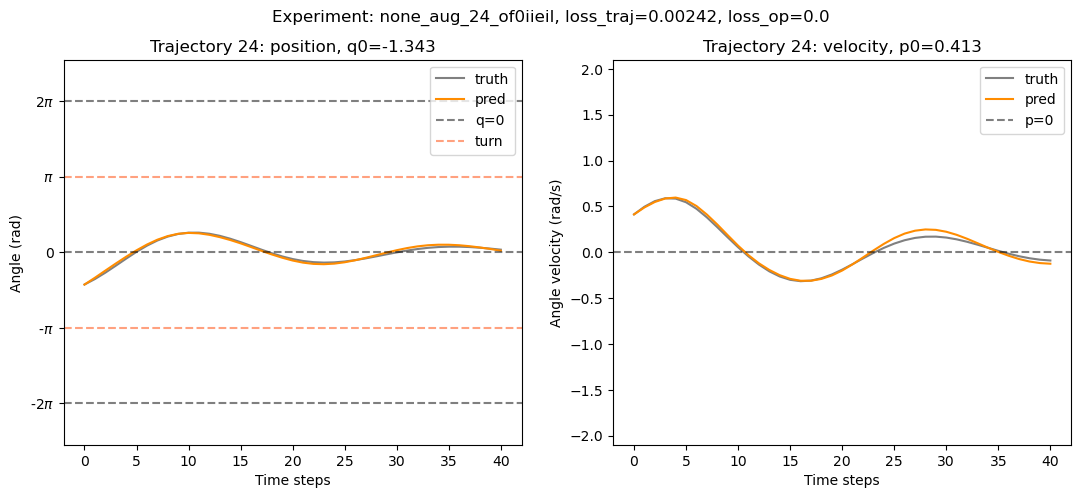

In [49]:
plot_trajectory(results_sc3, exp_name_sc3, 24)

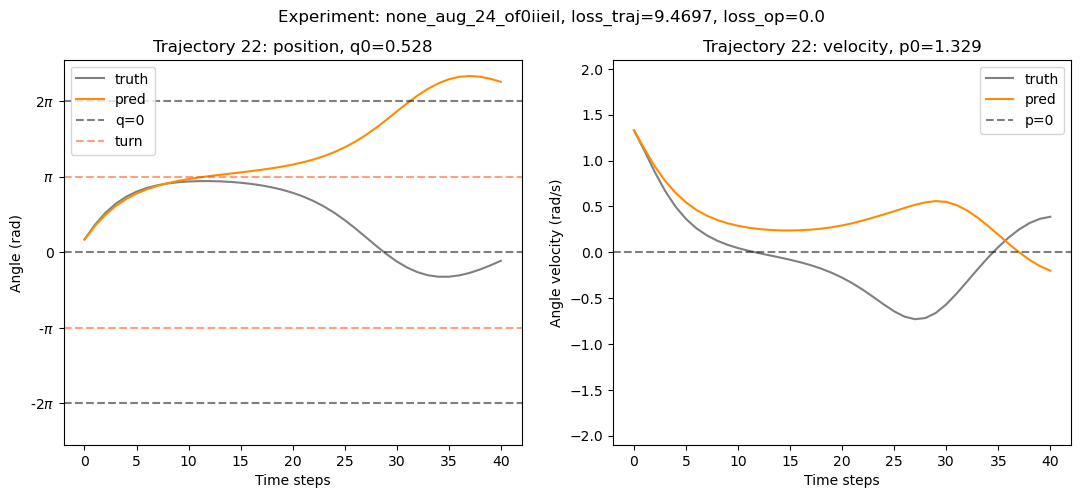

In [50]:
plot_trajectory(results_sc3, exp_name_sc3, 22)

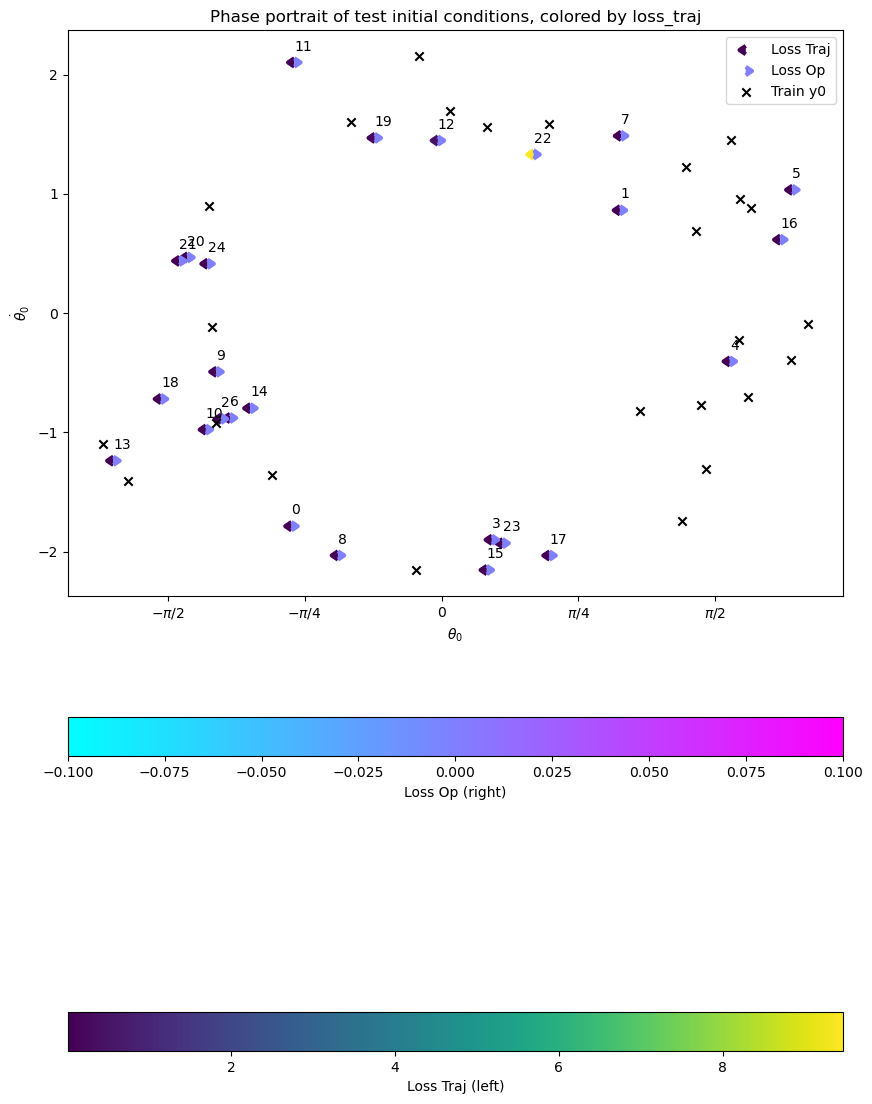

In [51]:
viz_losses_regimes(results_sc3, y0)

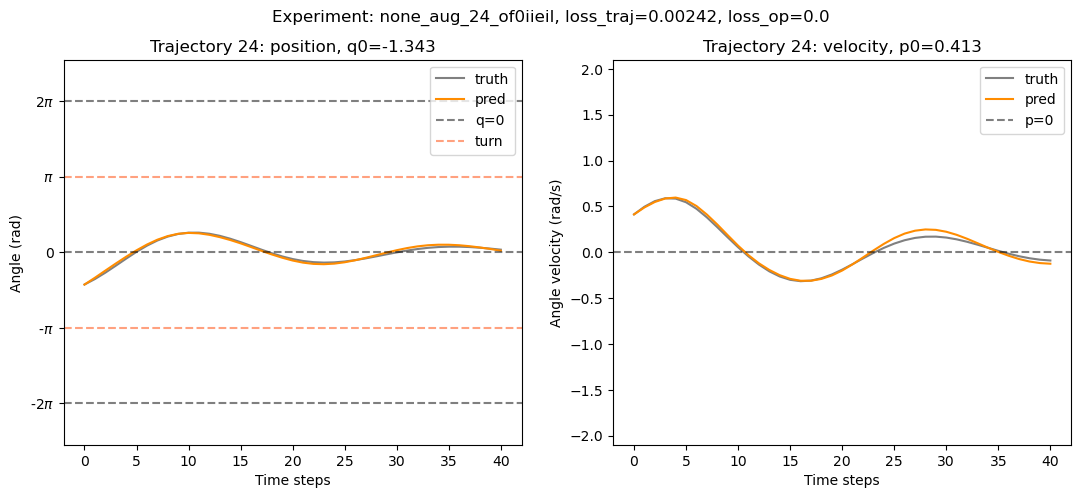

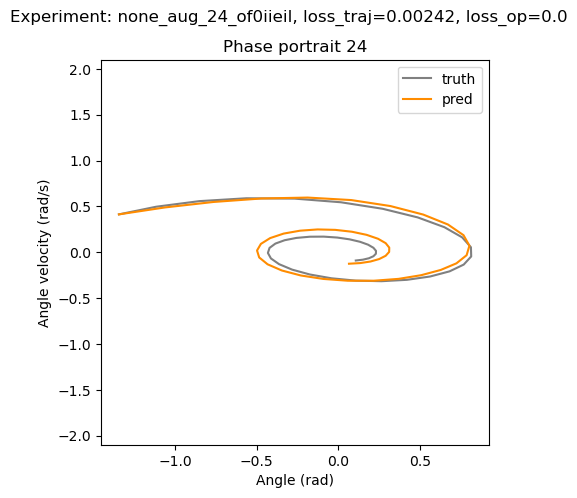

(None, None)

In [52]:
plot_trajectory(results_sc3, exp_name_sc3, 24), plot_phase_trajectory(results_sc3, exp_name_sc3, 24)

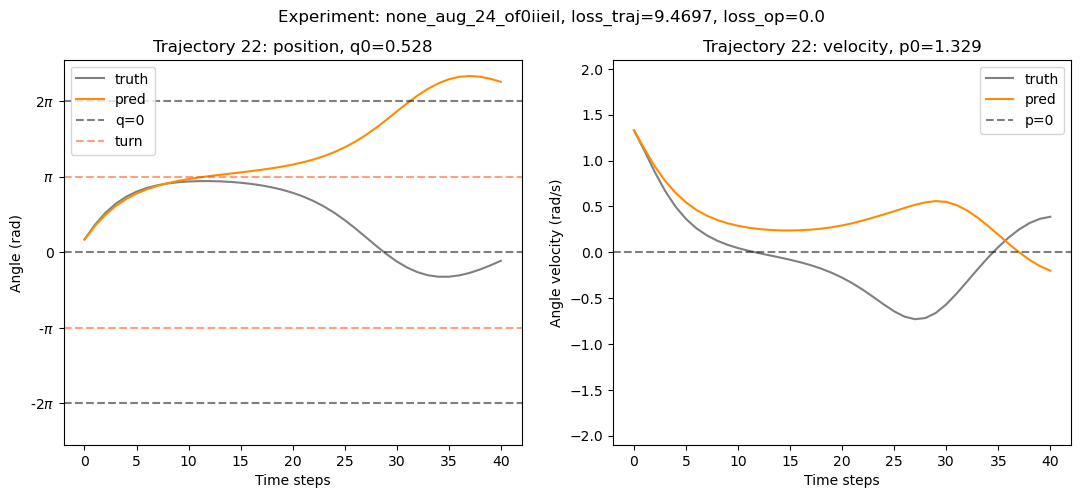

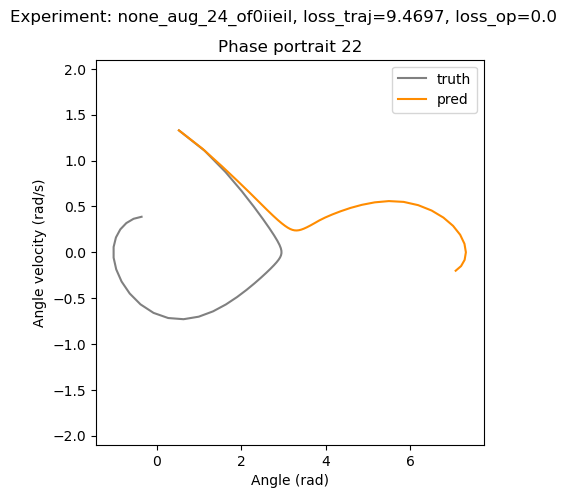

(None, None)

In [53]:
plot_trajectory(results_sc3, exp_name_sc3, 22), plot_phase_trajectory(results_sc3, exp_name_sc3, 22)

### Additional figures for presentation


In [54]:
results_sc22["loss_traj"].drop(22).mean(), results_sc2_l2_opt["loss_traj"].drop(22).mean()

(0.0015444556641639586, 0.003206990291800605)

In [74]:
mini, maxi

(8.647215872770177e-05, 2.973688602447509)

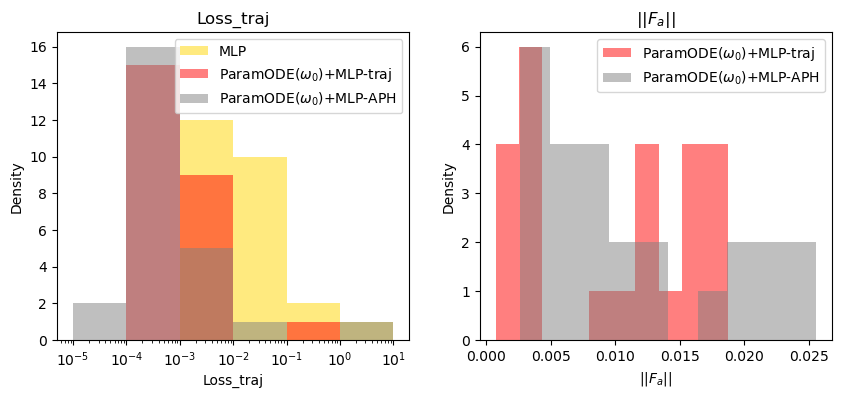

In [92]:
# histogram of losses
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
colors = ["gold", "red", "gray"]
labels = ["MLP",r"ParamODE($\omega_0$)+MLP-traj", r"ParamODE($\omega_0$)+MLP-APH"]
mini, maxi = min(results_sc22["loss_traj"].min(), results_sc2_l2_opt["loss_traj"].min()), max(results_sc22["loss_traj"].max(), results_sc2_l2_opt["loss_traj"].max())
for i, res in enumerate([results_sc3, results_sc22, results_sc2_l2_opt]):
    res["loss_traj"].plot.hist(ax=ax[0], color=colors[i], alpha=0.5, label=labels[i], bins=[0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1,10], histtype="barstacked")
    if i !=0:
        res["loss_op"].plot.hist(ax=ax[1], color=colors[i], alpha=0.5, label=labels[i])
ax[1].set_title(r"||$F_a$||")
ax[1].set_xlabel(r"||$F_a$||")
ax[1].set_ylabel("Density")
ax[0].set_title("Loss_traj")
ax[0].set_xlabel("Loss_traj")
ax[0].set_ylabel("Density")
ax[0].set_xscale("log")
ax[0].legend()
ax[1].legend()
plt.legend()
plt.show()

In [95]:
results_sc3["loss_traj"].mean(), results_sc22["loss_traj"].mean(), results_sc2_l2_opt["loss_traj"].mean()

(0.4084315770026293, 0.019779989697271443, 0.12202625477802893)

In [100]:
omega_22 = 0.2089155912399292 
omega_22_T0 = 2*np.pi/np.sqrt(omega_22)
omega_22_T0

omega_2_opt = 0.2598634362220764
omega_2_opt_T0 = 2*np.pi/np.sqrt(omega_2_opt)
omega_2_opt_T0

12.32557758902149

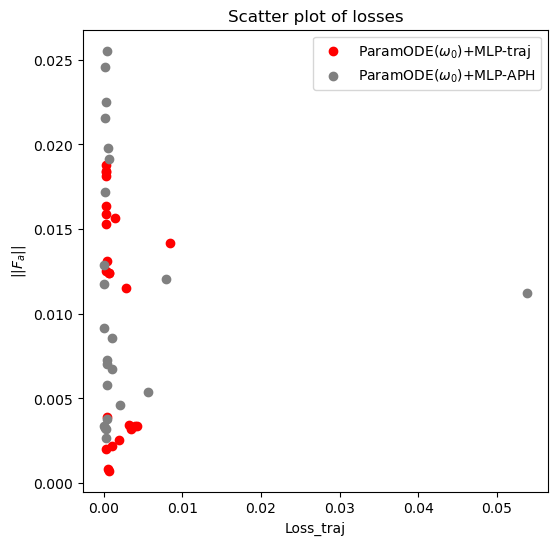

In [62]:
# scatter plot of losses traj and op
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
plt.scatter(results_sc22["loss_traj"].drop(22), results_sc22["loss_op"].drop(22), label="ParamODE($\omega_0$)+MLP-traj", color="red")
plt.scatter(results_sc2_l2_opt["loss_traj"].drop(22), results_sc2_l2_opt["loss_op"].drop(22), label="ParamODE($\omega_0$)+MLP-APH", color="grey")
plt.xlabel("Loss_traj")
plt.ylabel(r"||$F_a$||")
plt.title("Scatter plot of losses")
plt.legend()
plt.show()

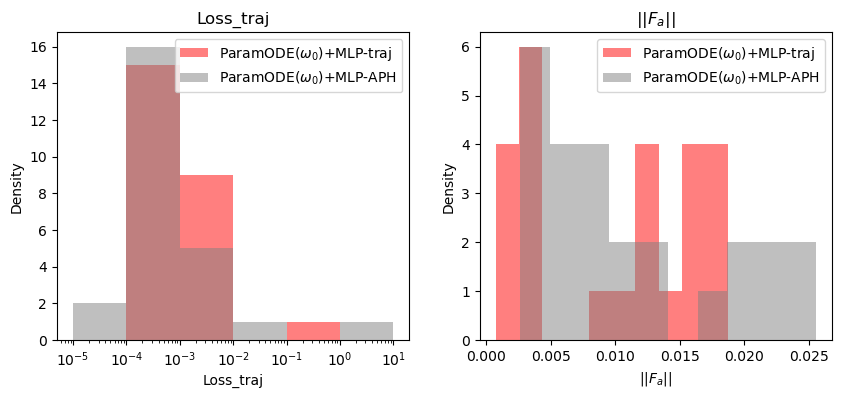

In [89]:
# histogram of losses
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
colors = [ "red", "grey"]
labels = [r"ParamODE($\omega_0$)+MLP-traj", r"ParamODE($\omega_0$)+MLP-APH"]
for i, res in enumerate([ results_sc22, results_sc2_l2_opt]):
    res["loss_traj"].plot.hist(ax=ax[0], color=colors[i], alpha=0.5, label=labels[i], bins=[0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1,10])
    res["loss_op"].plot.hist(ax=ax[1], color=colors[i], alpha=0.5, label=labels[i])
ax[1].set_title(r"||$F_a$||")
ax[1].set_xlabel(r"||$F_a$||")
ax[1].set_ylabel("Density")
ax[0].set_title("Loss_traj")
ax[0].set_xlabel("Loss_traj")
ax[0].set_ylabel("Density")
ax[0].set_xscale("log")
ax[0].legend()
ax[1].legend()
plt.legend()
plt.show()

# Final results and figures
Final models are in `data/lipschitz`

In [321]:
# load results 
path_sc2_bis = "/Users/mayajanvier/jax-phynity/data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04.json"
results_sc2_bis, exp_name_sc2_bis, val_loss_sc2_bis = load_results(path_sc2_bis)
results_sc2_bis_fa = pd.read_json("/Users/mayajanvier/jax-phynity/data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04_Fa.json").T
results_sc2_bis_fa["Fa[0]"] = results_sc2_bis_fa["Fa"].apply(lambda x: np.array(x)[:,0])
results_sc2_bis_fa["Fa[1]"] = results_sc2_bis_fa["Fa"].apply(lambda x: np.array(x)[:,1])

path_sc22_bis = "/Users/mayajanvier/jax-phynity/data/lipschitz/incomplete_no_Fa_aug_20_ps3fe9eb/model_4.466e-03.json"
path_sc22_bis_fa = "/Users/mayajanvier/jax-phynity/data/lipschitz/incomplete_no_Fa_aug_20_ps3fe9eb/model_4.466e-03_Fa.json"
results_sc22_bis, _,_ = load_results(path_sc22_bis)
results_sc22_bis_fa = pd.read_json(path_sc22_bis_fa).T
results_sc22_bis_fa["Fa[0]"] = results_sc22_bis_fa["Fa"].apply(lambda x: np.array(x)[:,1])
results_sc22_bis_fa["Fa[1]"] = results_sc22_bis_fa["Fa"].apply(lambda x: np.array(x)[:,1]) 

path_sc3_bis = "/Users/mayajanvier/jax-phynity/data/lipschitz/none_aug_19_yt8wqw57/model_3.270e-02.json"
results_sc3_bis, exp_name_sc3_bis, val_loss_sc3_bis = load_results(path_sc3_bis)


ValueError: Trailing data

In [328]:
# get mean log MSE and confidence intervals
results_sc4, _,_ = load_results("/Users/mayajanvier/jax-phynity/data/lipschitz/none_Fa_aug_31_92x54p4c/model_3.464e-01.json")
results_sc4["log_mse_traj"] = results_sc4.apply(lambda x: np.log(x["loss_traj"]), axis=1)
results_sc4_bis, _,_ = load_results("/Users/mayajanvier/jax-phynity/data/lipschitz/none_Fa_aug_33_e6ynty14/model_1.030e-01.json")
results_sc4_bis["log_mse_traj"] = results_sc4_bis.apply(lambda x: np.log(x["loss_traj"]), axis=1)
results_sc4_bis["log_mse_traj"].mean()

results_sc2_bis["log_mse_traj"] =results_sc2_bis.apply(lambda x: np.log(x["loss_traj"]), axis=1)
results_sc22_bis["log_mse_traj"] =results_sc22_bis.apply(lambda x: np.log(x["loss_traj"]), axis=1)
results_sc3_bis["log_mse_traj"] =results_sc3_bis.apply(lambda x: np.log(x["loss_traj"]), axis=1)

from scipy import stats
from scipy.stats import t

def confidence_interval(data):
    interv = t.interval(0.95, len(data)-1, loc=np.mean(data), scale=stats.sem(data))
    return np.mean(data), interv 

In [329]:
print(confidence_interval(results_sc4_bis["log_mse_traj"]))
print(confidence_interval(results_sc2_bis["log_mse_traj"]))
print(confidence_interval(results_sc22_bis["log_mse_traj"]))
print(confidence_interval(results_sc3_bis["log_mse_traj"]))

(-3.1294783727249462, (-3.9720334971200417, -2.2869232483298507))
(-7.800657000923796, (-8.510490327503776, -7.090823674343817))
(-7.0552334963486665, (-7.73194936049921, -6.378517632198123))
(-4.263344832159258, (-5.055347072233168, -3.471342592085348))


In [363]:
-7.86-0.6, -7.86+0.6    # true aph
-2.84-0.7, -2.84+0.7    # true neuralode

(-3.54, -2.1399999999999997)

In [362]:
# student t test to determine best 
from scipy import stats
from scipy.stats import ttest_ind
def t_test(data1, data2):
    t_stat, p_value = stats.ttest_ind(data1, data2)
    return t_stat, p_value
print(t_test(results_sc22_bis["log_mse_traj"], results_sc2_bis["log_mse_traj"]))


(1.5687267547290171, 0.12328109258238995)


## 1. Simulation

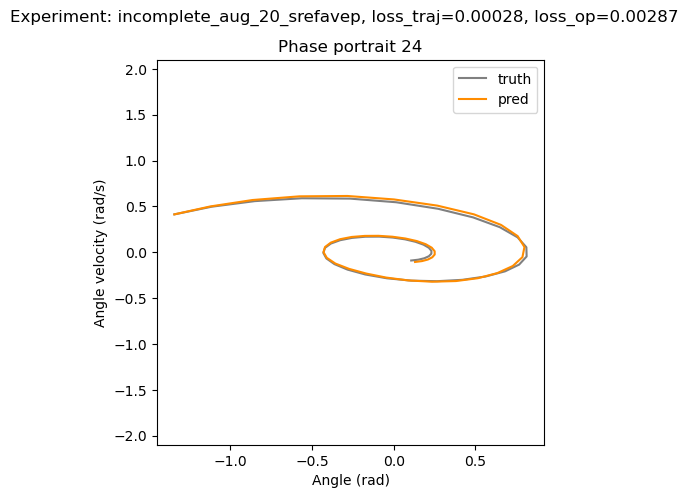

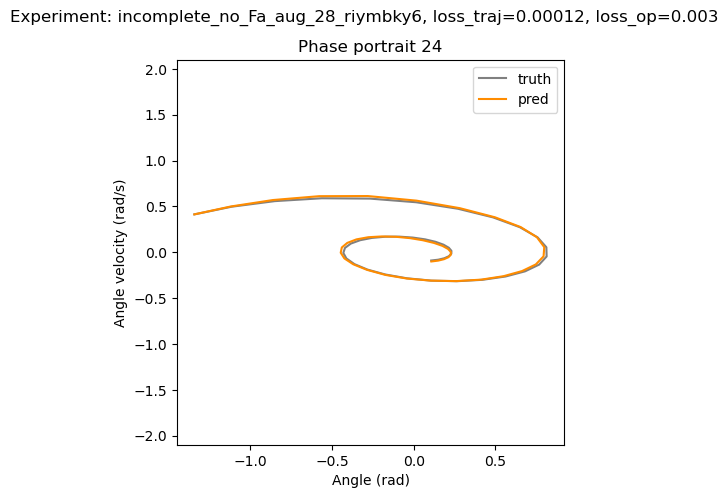

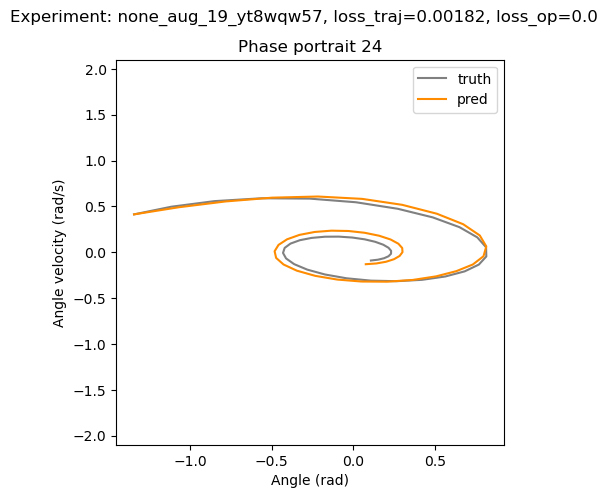

In [324]:
plot_phase_trajectory(results_sc2_bis, exp_name_sc2_bis, 24)
plot_phase_trajectory(results_sc22_bis, exp_name_sc22, 24)
plot_phase_trajectory(results_sc3_bis, exp_name_sc3_bis, 24)

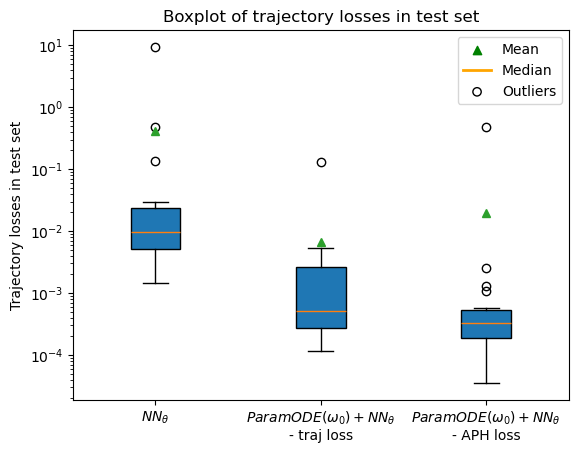

In [320]:
# boxplot meilleur

losses_traj = [
    results_sc3_bis["loss_traj"],
    results_sc22_bis["loss_traj"],
    results_sc2_bis["loss_traj"],
]
labels = [r'$NN_{\theta}$', r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- traj loss', r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- APH loss']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel('Trajectory losses in test set')
ax.set_yscale('log')

# orientation en biais
bplot = ax.boxplot(losses_traj,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   showmeans=True)  # will be used to label x-ticks
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend, outlier_legend], loc='upper right')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title("Boxplot of trajectory losses in test set")
plt.show()

## 2.1 Interpretability: Impact of the penalisation on the learned $\omega_0$

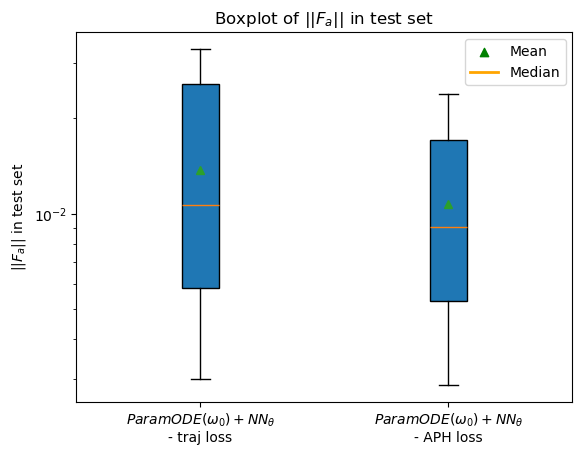

In [316]:
# boxplot meilleur

losses_Fa = [
    #results_sc3_bis["loss_op"],
    results_sc22_bis["loss_op"],
    results_sc2_bis["loss_op"],
]
labels = [r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- traj loss', r'$ParamODE(\omega_0)+NN_\theta$'+'\n'+ '- APH loss']
#colors = ['peachpuff', 'orange', 'tomato']

fig, ax = plt.subplots()
ax.set_ylabel(r'$||F_a||$ in test set')
ax.set_yscale('log')

# orientation en biais
bplot = ax.boxplot(losses_Fa,
                   patch_artist=True,  # fill with color
                   tick_labels=labels,
                   showmeans=True)  # will be used to label x-ticks
# dummy legend
mean_legend = plt.scatter([], [], color='green', marker='^', label='Mean')
median_legend = plt.Line2D([0], [0], color='orange', linewidth=2, label='Median')
#outlier_legend = plt.scatter([],[], marker= 'o',edgecolors='black', facecolors='none', label='Outliers')

ax.legend(handles=[mean_legend, median_legend], loc='upper right')
# fill with colors
# for patch, color in zip(bplot['boxes'], colors):
#     patch.set_facecolor(color)
plt.title(r"Boxplot of $||F_a||$ in test set")
plt.show()

In [348]:
confidence_interval(results_sc22_bis["loss_op"])[0], confidence_interval(results_sc22_bis["loss_op"])[1] - confidence_interval(results_sc22_bis["loss_op"])[0]

(0.013704747082665163, array([-0.00422413,  0.00422413]))

In [349]:
confidence_interval(results_sc2_bis["loss_op"])[0], confidence_interval(results_sc2_bis["loss_op"])[1] - confidence_interval(results_sc2_bis["loss_op"])[0]

(0.01075162995606612, array([-0.00296051,  0.00296051]))

In [358]:
# get ||F_a|| from paper as sum 

Fa_sc22 = 0
Fa_sc2 = 0
for iteration, data in enumerate(test,0):
    states = jnp.array(data['states'])
    y_in = rearrange(states, 'b nc T -> (b T) nc')
    aug_deriv22 = jax.vmap(model_sc22.model_aug)(y_in)
    aug_deriv2 = jax.vmap(model_sc2.model_aug)(y_in)
    #aug_deriv22 = rearrange(aug_deriv22, '(b T) nc -> b nc T', b=states.shape[0])
    #aug_deriv2 = rearrange(aug_deriv2, '(b T) nc -> b nc T', b=states.shape[0])
    #Fa_sc22 +=  (jnp.linalg.norm(aug_deriv22, axis=1) ** 2).sum()
    #Fa_sc2 += (jnp.linalg.norm(aug_deriv2, axis=1) ** 2).sum()
    Fa_sc22 += jnp.sum(jnp.abs(aug_deriv22)**2) 
    Fa_sc2 += jnp.sum(aug_deriv2**2)
Fa_sc22 , Fa_sc2 

(Array(14.047367, dtype=float32), Array(11.020421, dtype=float32))

In [357]:
jnp.sum(states**2)

Array(12.881987, dtype=float32)

In [360]:
om22 = jnp.sqrt(model_sc22.model_phy.omega0_square)
om2 = jnp.sqrt(model_sc2.model_phy.omega0_square)
true_om = 2*np.pi/12
np.abs(om22- true_om)/true_om, np.abs(om2 - 2*np.pi/12)/true_om

(0.12410060986035894, 0.02465311246321636)

## 2.2 Interpretability: does the NN recover $\alpha$

Text(0, 0.2, '$R^2$ score: 0.88924')

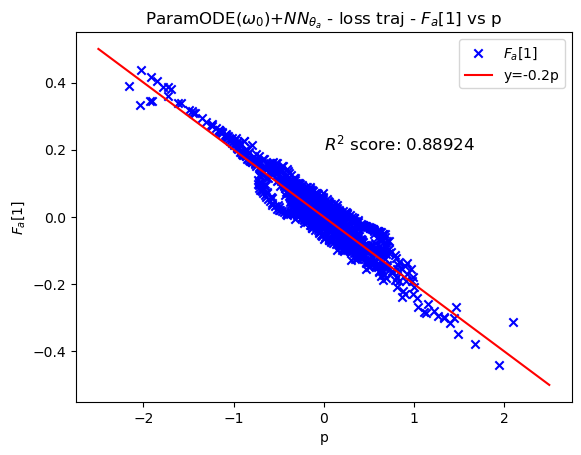

In [322]:
points = []
point_list = []
truth_list = []
for k in range(25):
    point_list.append(np.array(results_sc22_bis_fa["Fa"][k])[:,1])
    truth_list.append(np.array(results_sc22_bis_fa["states"][k])[:,1])
    if k==1: 
        plt.scatter(np.array(results_sc22_bis_fa["states"][k])[:,1], np.array(results_sc22_bis_fa["Fa"][k])[:,1], color="blue", marker='x', label=r"$F_a$[1]")
    else: 
        plt.scatter(np.array(results_sc22_bis_fa["states"][k])[:,1], np.array(results_sc22_bis_fa["Fa"][k])[:,1], color="blue", marker='x')
    #points.append(np.mean(np.abs(np.array(results_sc22_fa[k])[:,1]/np.array(results_sc22_fa["states"][k])[:,1])))
plt.plot(np.arange(-2.5, 3.5), -0.2 * np.arange(-2.5, 3.5), color="red", label = "y=-0.2p")

# R2
import sklearn
from sklearn.metrics import r2_score
point_list = np.array(point_list).flatten()
truth_list = np.array(truth_list).flatten()
r2_score(-0.2 * truth_list, point_list)

plt.legend()
plt.xlabel("p")
plt.ylabel(r"$F_a[1]$")
plt.title(r"ParamODE($\omega_0$)+$NN_{\theta_a}$ - loss traj - $F_a$[1] vs p")
# add r2 score above points scattered
plt.text(0, 0.2, rf"$R^2$ score: {round(r2_score(-0.2 * truth_list, point_list), 5)}", fontsize=12)



Text(0, 0.2, '$R^2$ score: 0.98434')

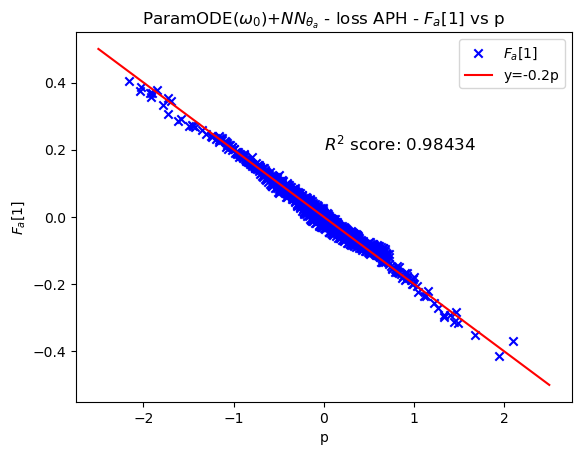

In [323]:
points = []
point_list = []
truth_list = []
for k in range(25):
    point_list.append(np.array(results_sc2_bis_fa["Fa"][k])[:,1])
    truth_list.append(np.array(results_sc2_bis_fa["states"][k])[:,1])
    if k==1: 
        plt.scatter(np.array(results_sc2_bis_fa["states"][k])[:,1], np.array(results_sc2_bis_fa["Fa"][k])[:,1], color="blue", marker='x', label=r"$F_a$[1]")
    else: 
        plt.scatter(np.array(results_sc2_bis_fa["states"][k])[:,1], np.array(results_sc2_bis_fa["Fa"][k])[:,1], color="blue", marker='x')
    #points.append(np.mean(np.abs(np.array(results_sc22_fa[k])[:,1]/np.array(results_sc22_fa["states"][k])[:,1])))
plt.plot(np.arange(-2.5, 3.5), -0.2 * np.arange(-2.5, 3.5), color="red", label = "y=-0.2p")

# R2
import sklearn
from sklearn.metrics import r2_score
point_list = np.array(point_list).flatten()
truth_list = np.array(truth_list).flatten()
r2_score(-0.2 * truth_list, point_list)

plt.legend()
plt.xlabel("p")
plt.ylabel(r"$F_a[1]$")
plt.title(r"ParamODE($\omega_0$)+$NN_{\theta_a}$ - loss APH - $F_a$[1] vs p")
# add r2 score above points scattered
plt.text(0, 0.2, rf"$R^2$ score: {round(r2_score(-0.2 * truth_list, point_list), 5)}", fontsize=12)



## 3.1 Generalization: Errors on RHS (dynamics) on larger domain

SC2: min_op=l2, $\lambda_0=10$, $\tau_2=100$

Final omega: 0.2598634362220764, Final alpha: 0.0

Loss_op = 1.1e-2

In [251]:
train_states = np.array(train_data["states"])
q_min, q_max = train_states[:,0,:].min(), train_states[:,0,:].max()
p_min, p_max = train_states[:,1,:].min(), train_states[:,1,:].max()
q_min, q_max, p_min, p_max

(-8.036385, 7.945931, -2.1586595, 2.155582)

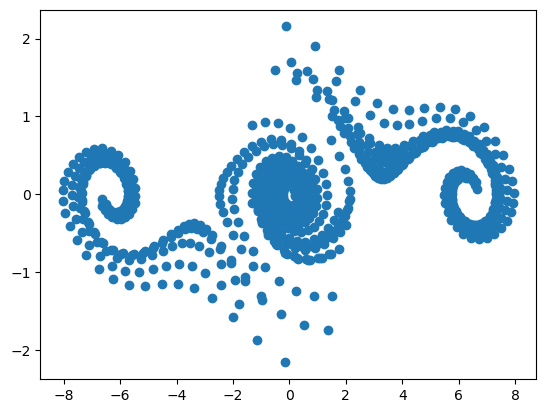

In [252]:
plt.scatter(train_states[:,0,:], train_states[:,1,:])

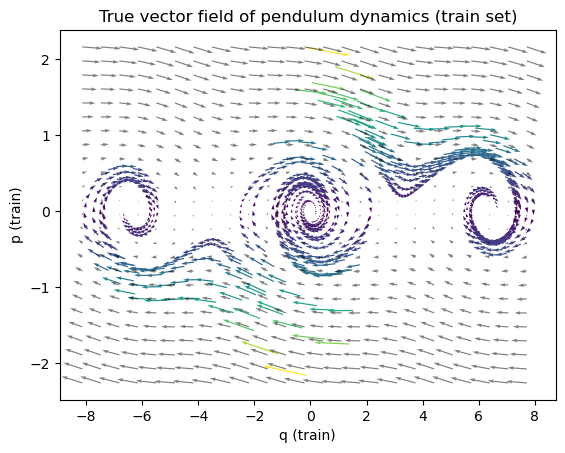

In [253]:
# plot true vector field of pendulum dynamics
def gradient(q,p):
    dq = p
    dp = - (2*np.pi/12)**2 * np.sin(q) - 0.2 * p
    return dq, dp


#ax.quiver(Q[skip], P[skip], dQ[skip], dP[skip])
fig, ax = plt.subplots()
q_train, p_train = train_states[:,0,:], train_states[:,1,:]
dq_train, dp_train = gradient(q_train, p_train)

q = np.linspace(q_min-0.1, q_max+0.1, 50)
p = np.linspace(p_min-0.1, p_max+0.1, 50)
Q, P = np.meshgrid(q, p)
dQ, dP = gradient(Q, P)
skip = (slice(None, None, 2), slice(None, None, 2))
#ax.scatter(q_train, p_train, marker="x", color="black", label="train")
# color by norm of vector
ax.quiver(q_train, p_train, dq_train, dp_train, np.abs(p_train), label="true vector field")
ax.quiver(Q[skip], P[skip], dQ[skip], dP[skip], color="black", label="true vector field", alpha=0.5)
ax.set_xlabel("q (train)")
ax.set_ylabel("p (train)")
plt.title("True vector field of pendulum dynamics (train set)")
plt.show()



In [254]:
# one vector for all test data
for i, test_data in enumerate(test):
    if i == 0:
        test_states = np.array(test_data["states"])
    else:
        test_states = np.concatenate((test_states, np.array(test_data["states"])))
test_states.shape

(25, 2, 41)

In [256]:
for index in range(24):
    if index == 0:
        q_pred, p_pred = np.array(results_sc2_l2_opt["pred"][index])[0,:], np.array(results_sc2_l2_opt["pred"][index])[1,:]
    else:
        q_pred = np.concatenate((q_pred, np.array(results_sc2_l2_opt["pred"][index])[0,:]))
        p_pred = np.concatenate((p_pred, np.array(results_sc2_l2_opt["pred"][index])[1,:]))
q_pred.shape, p_pred.shape

((984,), (984,))

In [249]:
# load model 
import json 
from networks import *
import jax
import equinox as eqx
from datasets import *
import os
from forecasters import *

def load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method):
    model_path = os.path.join(data_path, f"{exp_name}/{model_name}")
    print(model_path)
    if dataset_name == 'pendulum':
        if model_phy_option == 'incomplete':
            model_phy = PendulumParamPDE(is_damped=False)
        elif model_phy_option == 'complete':
            model_phy = PendulumParamPDE(is_damped=True)
        elif model_phy_option == 'true':
            model_phy = PendulumParamPDE(is_damped=True, params=test.dataset.params)
        elif model_phy_option == 'none':
            model_phy = PendulumParamPDE(is_damped=False) # mock model for eqx compatibility
        elif model_phy_option == 'incomplete_no_Fa':
            model_phy = PendulumParamPDE(is_damped=False)

        with open(model_path, "rb") as f:
            hyperparams = json.loads(f.readline().decode())
            mkey = jax.random.PRNGKey(0)
            model_aug = MLP(key=mkey, state_c=2, hidden=200)
            net = Forecaster(
                model_phy=model_phy,
                model_aug=model_aug,
                is_augmented=model_aug_option,
                is_phy=model_phy_option,
                dt=test.dataset.dt,
                num_steps=test.dataset.num_steps,
                integration_method=integration_method,
            )
            model = eqx.tree_deserialise_leaves(f, net)

    with open(os.path.join(data_path, f'{exp_name}/hyperparameters.json'), 'r') as f:
        min_op = json.load(f)['min_op']
    _lambda = hyperparams['lambda']
    print(min_op)
    return model, _lambda, min_op

In [250]:
## Param ODE +MLP aph
exp_name = 'incomplete_aug_20_srefavep'
model_name = 'model_4.321e-04.eqx'
data_path = 'data/lipschitz'
model_phy_option = 'incomplete'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
model_sc2, _lambda, min_op = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method)
F_sc2 = model_sc2.derivative_estimator

## Param ODE+mlp traj 
exp_name = 'incomplete_no_Fa_aug_20_ps3fe9eb'
model_name = 'model_4.466e-03.eqx'
data_path = 'data/lipschitz'
model_phy_option = 'incomplete_no_Fa'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
model_sc22, _lambda, min_op = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method)
F_sc22 = model_sc22.derivative_estimator

## MLP traj
exp_name = 'none_aug_19_yt8wqw57'
model_name = 'model_3.270e-02.eqx'
data_path = 'data/lipschitz'
model_phy_option = 'none'
model_aug_option = True
dataset_name = 'pendulum'
integration_method = 'RK4'
model_sc3, _lambda, min_op = load_model(data_path, model_name, exp_name, model_phy_option, model_aug_option, integration_method)
F_sc3 = model_sc3.derivative_estimator

data/lipschitz/incomplete_aug_20_srefavep/model_4.321e-04.eqx
l2
data/lipschitz/incomplete_no_Fa_aug_20_ps3fe9eb/model_4.466e-03.eqx
l2
data/lipschitz/none_aug_19_yt8wqw57/model_3.270e-02.eqx
none


In [257]:
q = np.linspace(-10, 10, 100)
p = np.linspace(-10, 10, 100)
Q, P = np.meshgrid(q, p)
dQ, dP = gradient(Q, P)
skip = (slice(None, None, 5), slice(None, None, 5))

Q_r, P_r = Q.ravel(), P.ravel()
S_in = np.stack([Q_r, P_r], axis=1)
T_in = np.zeros(S_in.shape[0])


In [263]:
def F_inc(q,p):
    return p, - (2*np.pi/12)**2 * np.sin(q)

In [264]:
def F_pred(F, S_in, T_in):
    dQ_pred, dP_pred = jax.vmap(F)(S_in, T_in)[:,0], jax.vmap(F)(S_in, T_in)[:,1]
    return np.reshape(dQ_pred, Q.shape), np.reshape(dP_pred, P.shape)

dQ_pred_sc2, dP_pred_sc2 = F_pred(F_sc2, S_in, T_in)
dQ_pred_sc22, dP_pred_sc22 = F_pred(F_sc22, S_in, T_in)
dQ_pred_sc3, dP_pred_sc3 = F_pred(F_sc3, S_in, T_in)
dQ_inc, dP_inc = F_inc(Q,P)

/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_1365/46461409.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0, 1].legend()
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_1365/46461409.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend()
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_1365/46461409.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2, 1].legend()
/var/folders/hd/6gcp429169ldrntwtps0b1_m0000gp/T/ipykernel_1365/46461409.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an under

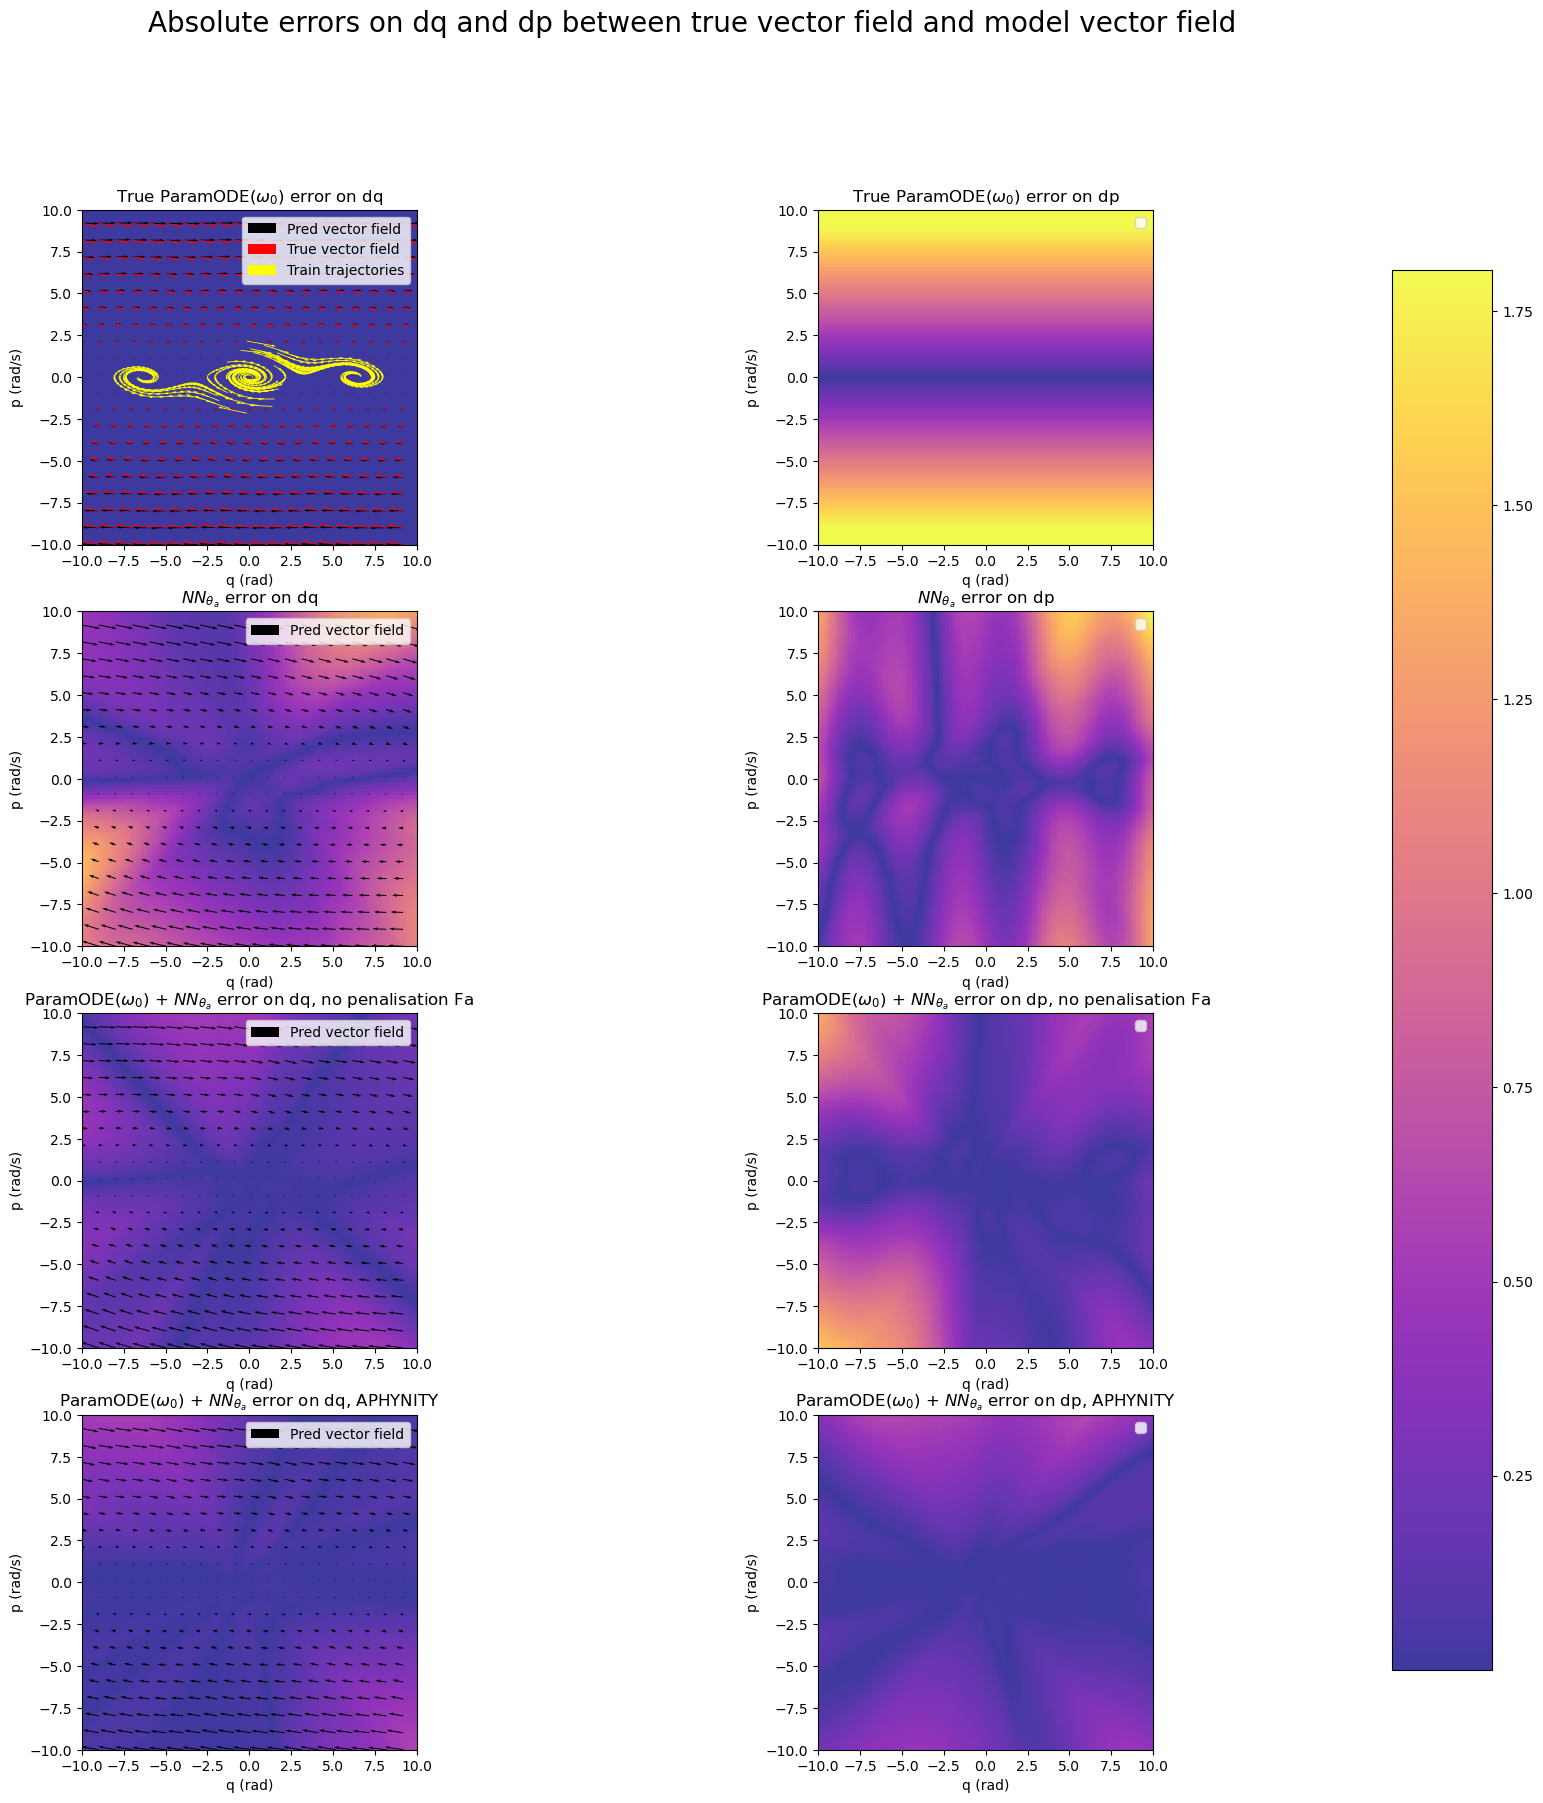

In [271]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 2, figsize=(20, 20))

# Compute error values
errorQ = np.abs(dQ_pred_sc2 - dQ)
errorP = np.abs(dP_pred_sc2 - dP)
errorQ22 = np.abs(dQ_pred_sc22 - dQ)
errorP22 = np.abs(dP_pred_sc22 - dP)
errorQ_mlp = np.abs(dQ_pred_sc3 - dQ)
errorP_mlp = np.abs(dP_pred_sc3 - dP)

vmin, vmax = min([np.min(errorQ), np.min(errorP), np.min(errorQ_mlp), np.min(errorP_mlp)]), \
             max([np.max(errorQ), np.max(errorP), np.max(errorQ_mlp), np.max(errorP_mlp)])

skip = (slice(None, None, 5), slice(None, None, 5))

### True incomplete dynamics
ax[0, 0].quiver(Q[skip], P[skip], dQ_inc[skip], dP_inc[skip], label="Pred vector field")
ax[0, 0].quiver(Q[skip], P[skip], dQ[skip], dP[skip], color="red", label="True vector field")
ax[0, 0].quiver(q_train, p_train, dq_train, dp_train, label="Train trajectories", color='yellow')
im = ax[0, 0].imshow(np.abs(dQ_inc - dQ), extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)
im2 = ax[0, 1].imshow(np.abs(dP_inc - dP), extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)

ax[0, 0].set_xlabel("q (rad)")
ax[0, 0].set_ylabel("p (rad/s)")
ax[0, 1].set_xlabel("q (rad)")
ax[0, 1].set_ylabel("p (rad/s)")
ax[0, 0].set(aspect=1, title=r"True ParamODE($\omega_0$) error on dq")
ax[0, 1].set(aspect=1, title=r"True ParamODE($\omega_0$) error on dp")
ax[0, 0].legend()
ax[0, 1].legend()

### MLP alone
ax[1, 0].quiver(Q[skip], P[skip], dQ_pred_sc3[skip], dP_pred_sc3[skip], label="Pred vector field")
im = ax[1, 0].imshow(errorQ_mlp, extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)
im2 = ax[1, 1].imshow(errorP_mlp, extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)
ax[1, 0].set_xlabel("q (rad)")
ax[1, 0].set_ylabel("p (rad/s)")
ax[1, 1].set_xlabel("q (rad)")
ax[1, 1].set_ylabel("p (rad/s)")
ax[1, 0].set(aspect=1, title=r"$NN_{\theta_a}$ error on dq")
ax[1, 1].set(aspect=1, title=r"$NN_{\theta_a}$ error on dp")
ax[1, 0].legend()
ax[1, 1].legend()

### SC2.2
ax[2, 0].quiver(Q[skip], P[skip], dQ_pred_sc22[skip], dP_pred_sc22[skip], label="Pred vector field")
im = ax[2, 0].imshow(errorQ22, extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)
im2 = ax[2, 1].imshow(errorP22, extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)

ax[2, 0].set_xlabel("q (rad)")
ax[2, 0].set_ylabel("p (rad/s)")
ax[2, 1].set_xlabel("q (rad)")
ax[2, 1].set_ylabel("p (rad/s)")
ax[2, 0].set(aspect=1, title=r"ParamODE($\omega_0$) + $NN_{\theta_a}$ error on dq, no penalisation Fa")
ax[2, 1].set(aspect=1, title=r"ParamODE($\omega_0$) + $NN_{\theta_a}$ error on dp, no penalisation Fa")
ax[2, 0].legend()
ax[2, 1].legend()

### APHYNITY
ax[3, 0].quiver(Q[skip], P[skip], dQ_pred_sc2[skip], dP_pred_sc2[skip], label="Pred vector field")
im = ax[3, 0].imshow(errorQ, extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)
im2 = ax[3, 1].imshow(errorP, extent=[Q.min(), Q.max(), P.min(), P.max()], cmap="plasma", alpha=0.8, vmin=vmin, vmax=vmax)

ax[3, 0].set_xlabel("q (rad)")
ax[3, 0].set_ylabel("p (rad/s)")
ax[3, 1].set_xlabel("q (rad)")
ax[3, 1].set_ylabel("p (rad/s)")
ax[3, 0].set(aspect=1, title=r"ParamODE($\omega_0$) + $NN_{\theta_a}$ error on dq, APHYNITY")
ax[3, 1].set(aspect=1, title=r"ParamODE($\omega_0$) + $NN_{\theta_a}$ error on dp, APHYNITY")
ax[3, 0].legend()
ax[3, 1].legend()



fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)
fig.suptitle("Absolute errors on dq and dp between true vector field and model vector field", fontsize=20) 

plt.show()


In [269]:
L = np.sqrt(1+ (2*np.pi/12)**4 + 0.2**2)
L_bis = np.sqrt(1+ (2*np.pi/12)**4) + 0.2
L,L_bis, max(np.sqrt(1+ (2*np.pi/12)**4), 0.2)

(1.0560119959898109, 1.2368998677183753, 1.0368998677183754)

### Flowiz

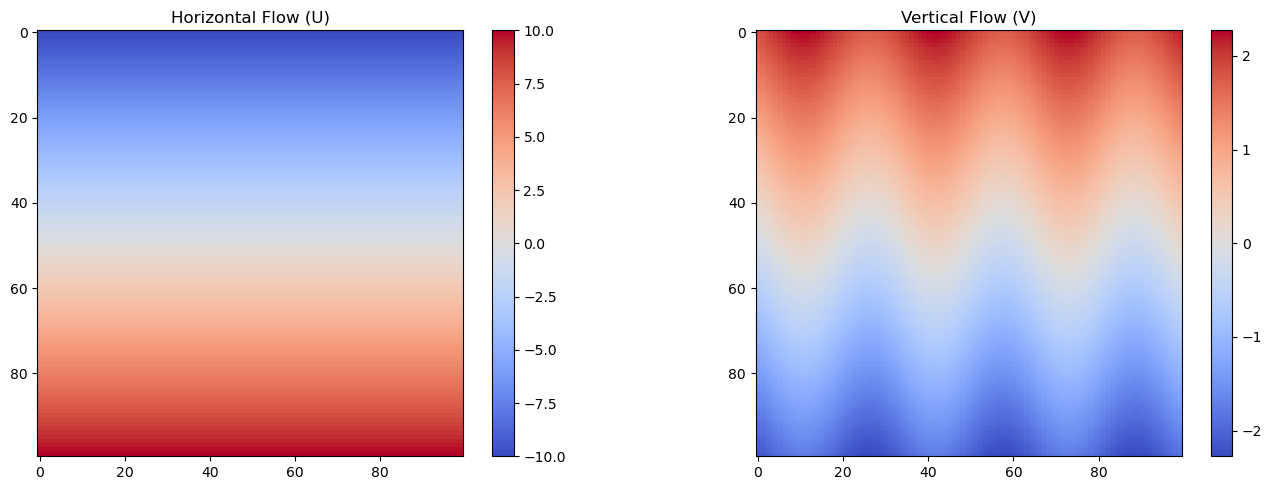

In [95]:
import flowiz as fz
#fz.convert_from_flow(np.vstack([dQ,dP]), mode='UV')
flow_field = np.stack([dQ, dP], axis=-1)
flow_image = fz.convert_from_flow(flow_field, mode='UV')

f, axarr = plt.subplots(1,2)
f.set_size_inches(15, 5)

im1 = axarr[0].imshow(flow_field[..., 0], cmap="coolwarm")
axarr[0].set_title('Horizontal Flow (U)')
plt.colorbar(im1, ax=axarr[0], fraction=0.046, pad=0.04)  # Add colorbar

# Plot vertical flow (V)
im2 = axarr[1].imshow(flow_field[..., 1], cmap="coolwarm")
axarr[1].set_title('Vertical Flow (V)')
plt.colorbar(im2, ax=axarr[1], fraction=0.046, pad=0.04)  # Add colorbar
plt.tight_layout()
plt.show()



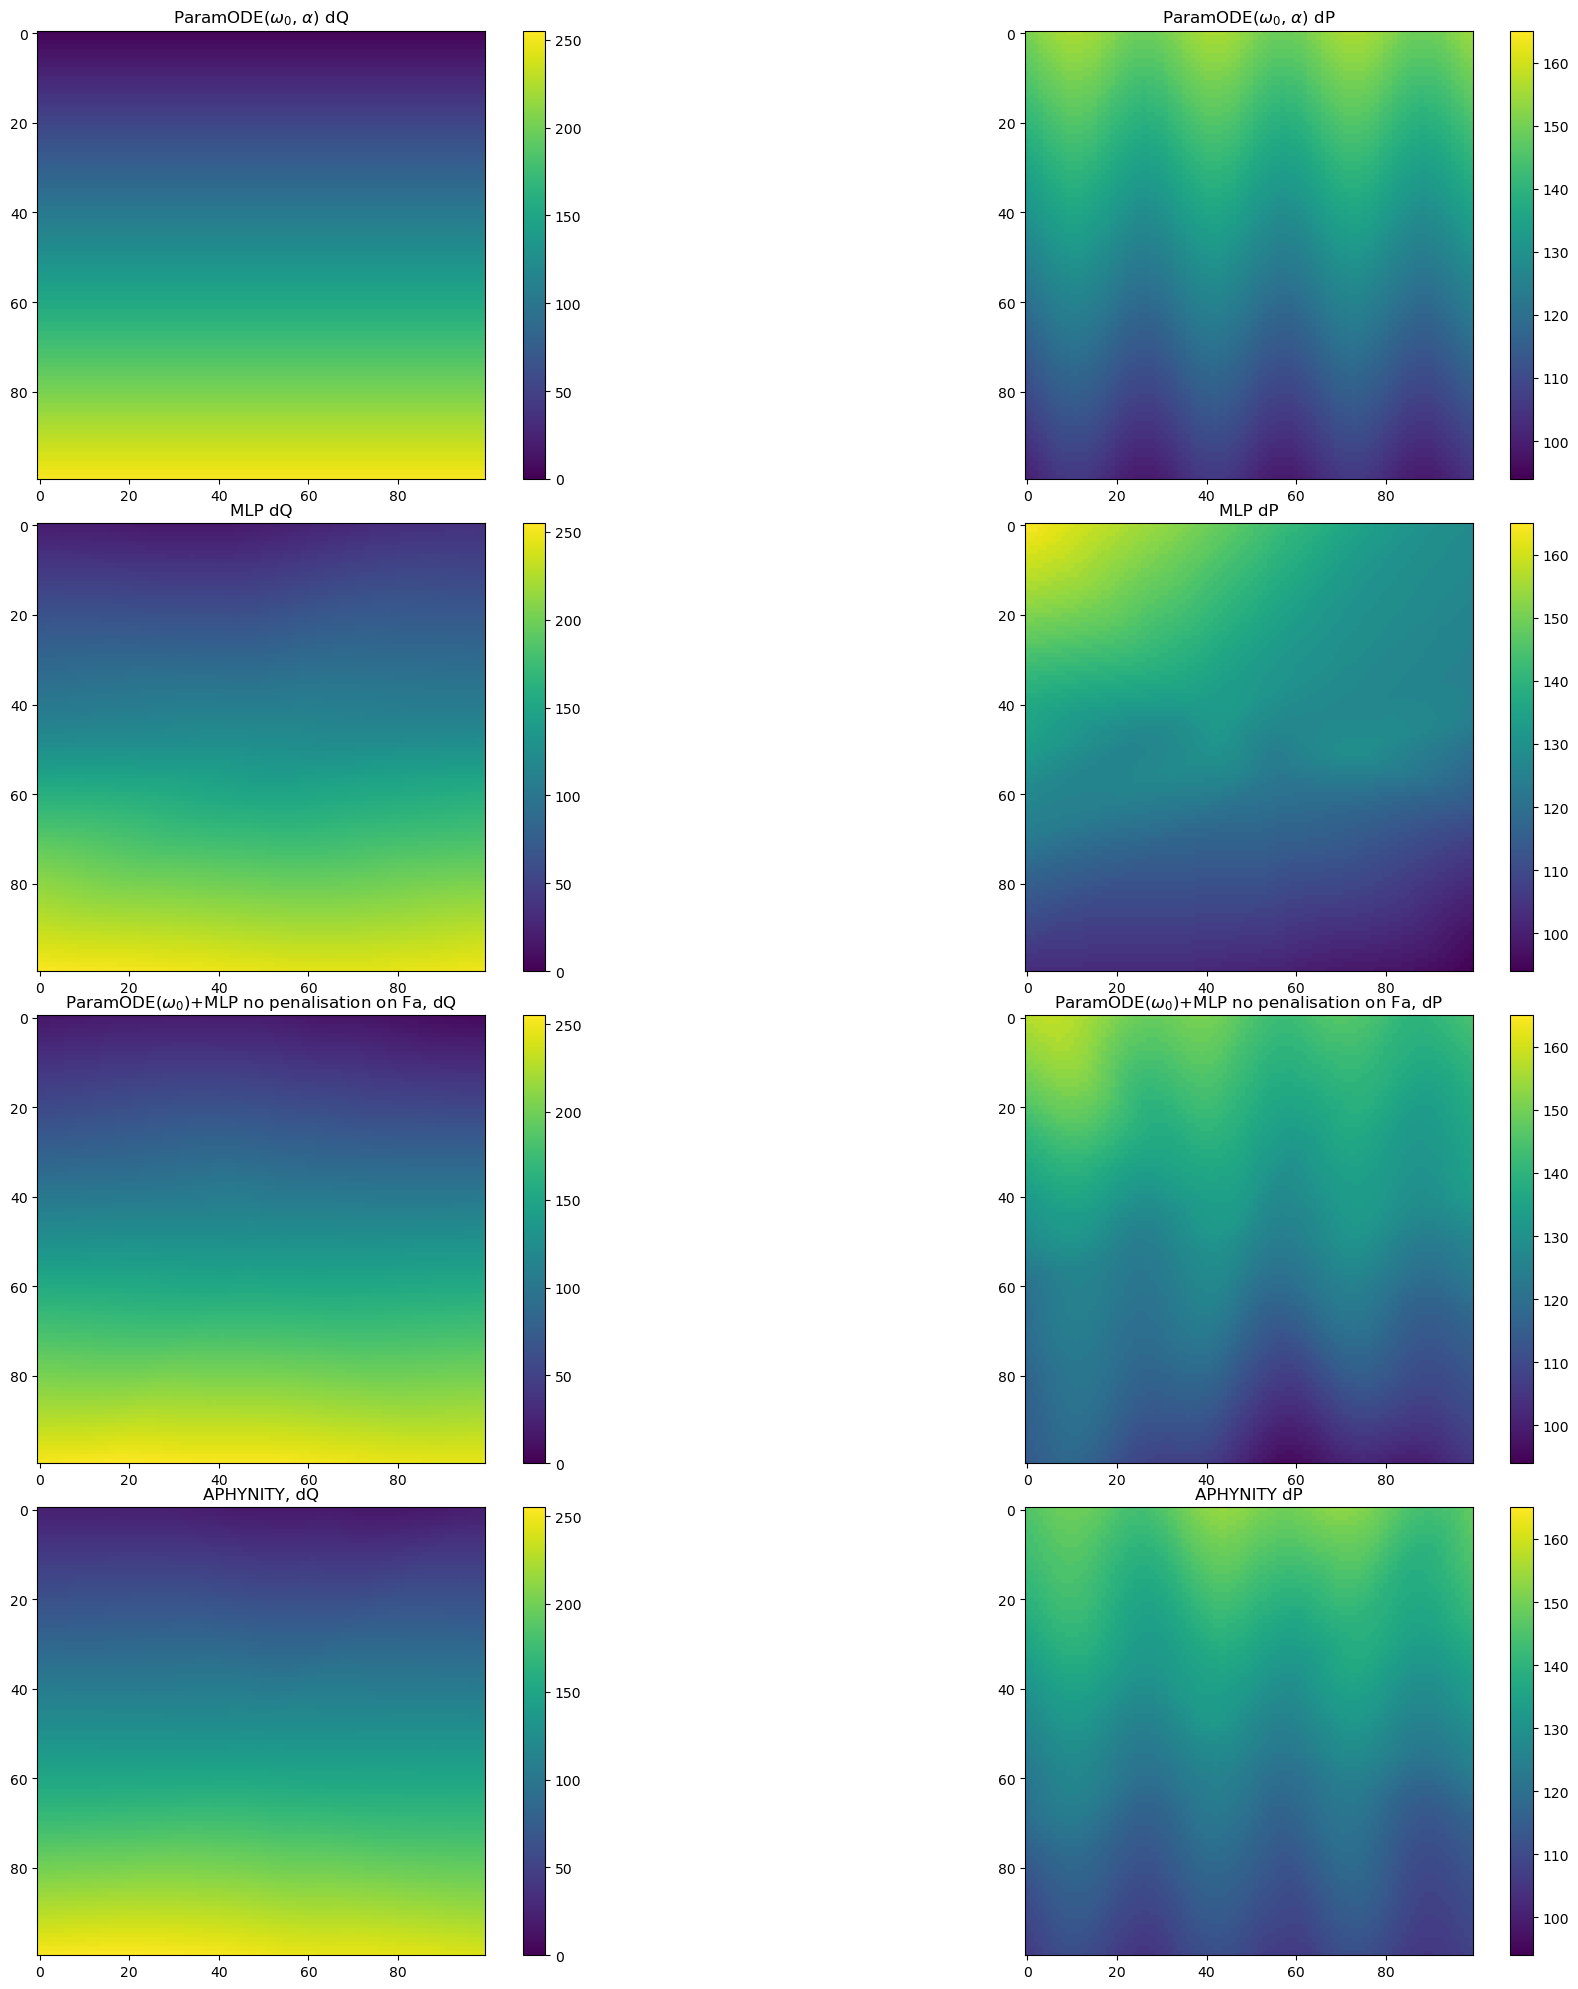

In [101]:

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 2, figsize=(20, 20))

# Compute flows 
flow_comp = fz.convert_from_flow(np.stack([dQ, dP], axis=-1), mode='UV') #true
flow_inc = fz.convert_from_flow(np.stack([dQ_inc, dP_inc], axis=-1), mode='UV') #true incomplete
flow_pred = fz.convert_from_flow(np.stack([dQ_pred, dP_pred], axis=-1), mode='UV') #aphynity
flow_pred_mlp = fz.convert_from_flow(np.stack([dQ_pred_mlp, dP_pred_mlp], axis=-1), mode='UV') #mlp
flow_pred_nofa = fz.convert_from_flow(np.stack([dQ_pred_nofa, dP_pred_nofa], axis=-1), mode='UV') #sc2.2


vminQ, vmaxQ = min([np.min(flow_comp[..., 0]), np.min(flow_inc[..., 0]), np.min(flow_pred[..., 0]), np.min(flow_pred_mlp[..., 0]), np.min(flow_pred_nofa[..., 0])]), \
                max([np.max(flow_comp[..., 0]), np.max(flow_inc[..., 0]), np.max(flow_pred[..., 0]), np.max(flow_pred_mlp[..., 0]), np.max(flow_pred_nofa[..., 0])])

vminP, vmaxP = min([np.min(flow_comp[..., 1]), np.min(flow_inc[..., 1]), np.min(flow_pred[..., 1]), np.min(flow_pred_mlp[..., 1]), np.min(flow_pred_nofa[..., 1])]), \
                max([np.max(flow_comp[..., 1]), np.max(flow_inc[..., 1]), np.max(flow_pred[..., 1]), np.max(flow_pred_mlp[..., 1]), np.max(flow_pred_nofa[..., 1])])


### True incomplete dynamics
im1 = ax[0, 0].imshow(flow_comp[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[0, 1].imshow(flow_comp[..., 1], vmin=vminP, vmax=vmaxP)
ax[0, 0].set_title(r'ParamODE($\omega_0$, $\alpha$) dQ')
ax[0, 1].set_title(r'ParamODE($\omega_0$, $\alpha$) dP')
plt.colorbar(im1, ax=ax[0,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[0,1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()

### MLP alone
im1 = ax[1, 0].imshow(flow_pred_mlp[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[1, 1].imshow(flow_pred_mlp[..., 1], vmin=vminP, vmax=vmaxP)
ax[1, 0].set_title(r'MLP dQ')
ax[1, 1].set_title('MLP dP')
plt.colorbar(im1, ax=ax[1,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[1,1], fraction=0.046, pad=0.04)  # Add colorbar

### SC2.2
im1 = ax[2, 0].imshow(flow_pred_nofa[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[2, 1].imshow(flow_pred_nofa[..., 1], vmin=vminP, vmax=vmaxP)
ax[2, 0].set_title(r'ParamODE($\omega_0$)+MLP no penalisation on Fa, dQ')
ax[2, 1].set_title(r'ParamODE($\omega_0$)+MLP no penalisation on Fa, dP')
plt.colorbar(im1, ax=ax[2,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[2,1], fraction=0.046, pad=0.04)  #

### APHYNITY
im1 = ax[3, 0].imshow(flow_pred[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[3, 1].imshow(flow_pred[..., 1], vmin=vminP, vmax=vmaxP)
ax[3, 0].set_title(r'APHYNITY, dQ')
ax[3, 1].set_title('APHYNITY dP')
plt.colorbar(im1, ax=ax[3,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[3,1], fraction=0.046, pad=0.04)  #
plt.title("Fields of dQ, dP for different models")
plt.show()



In [107]:
flow_comp = fz.convert_from_flow(np.stack([dQ, dP], axis=-1)) #true

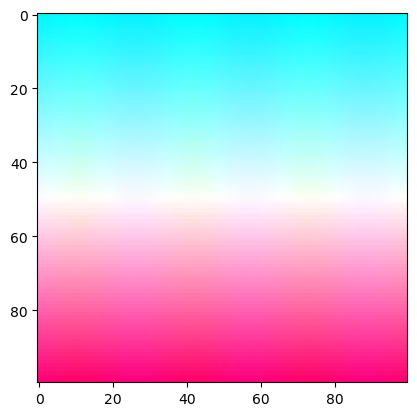

In [109]:
plt.imshow(flow_comp)

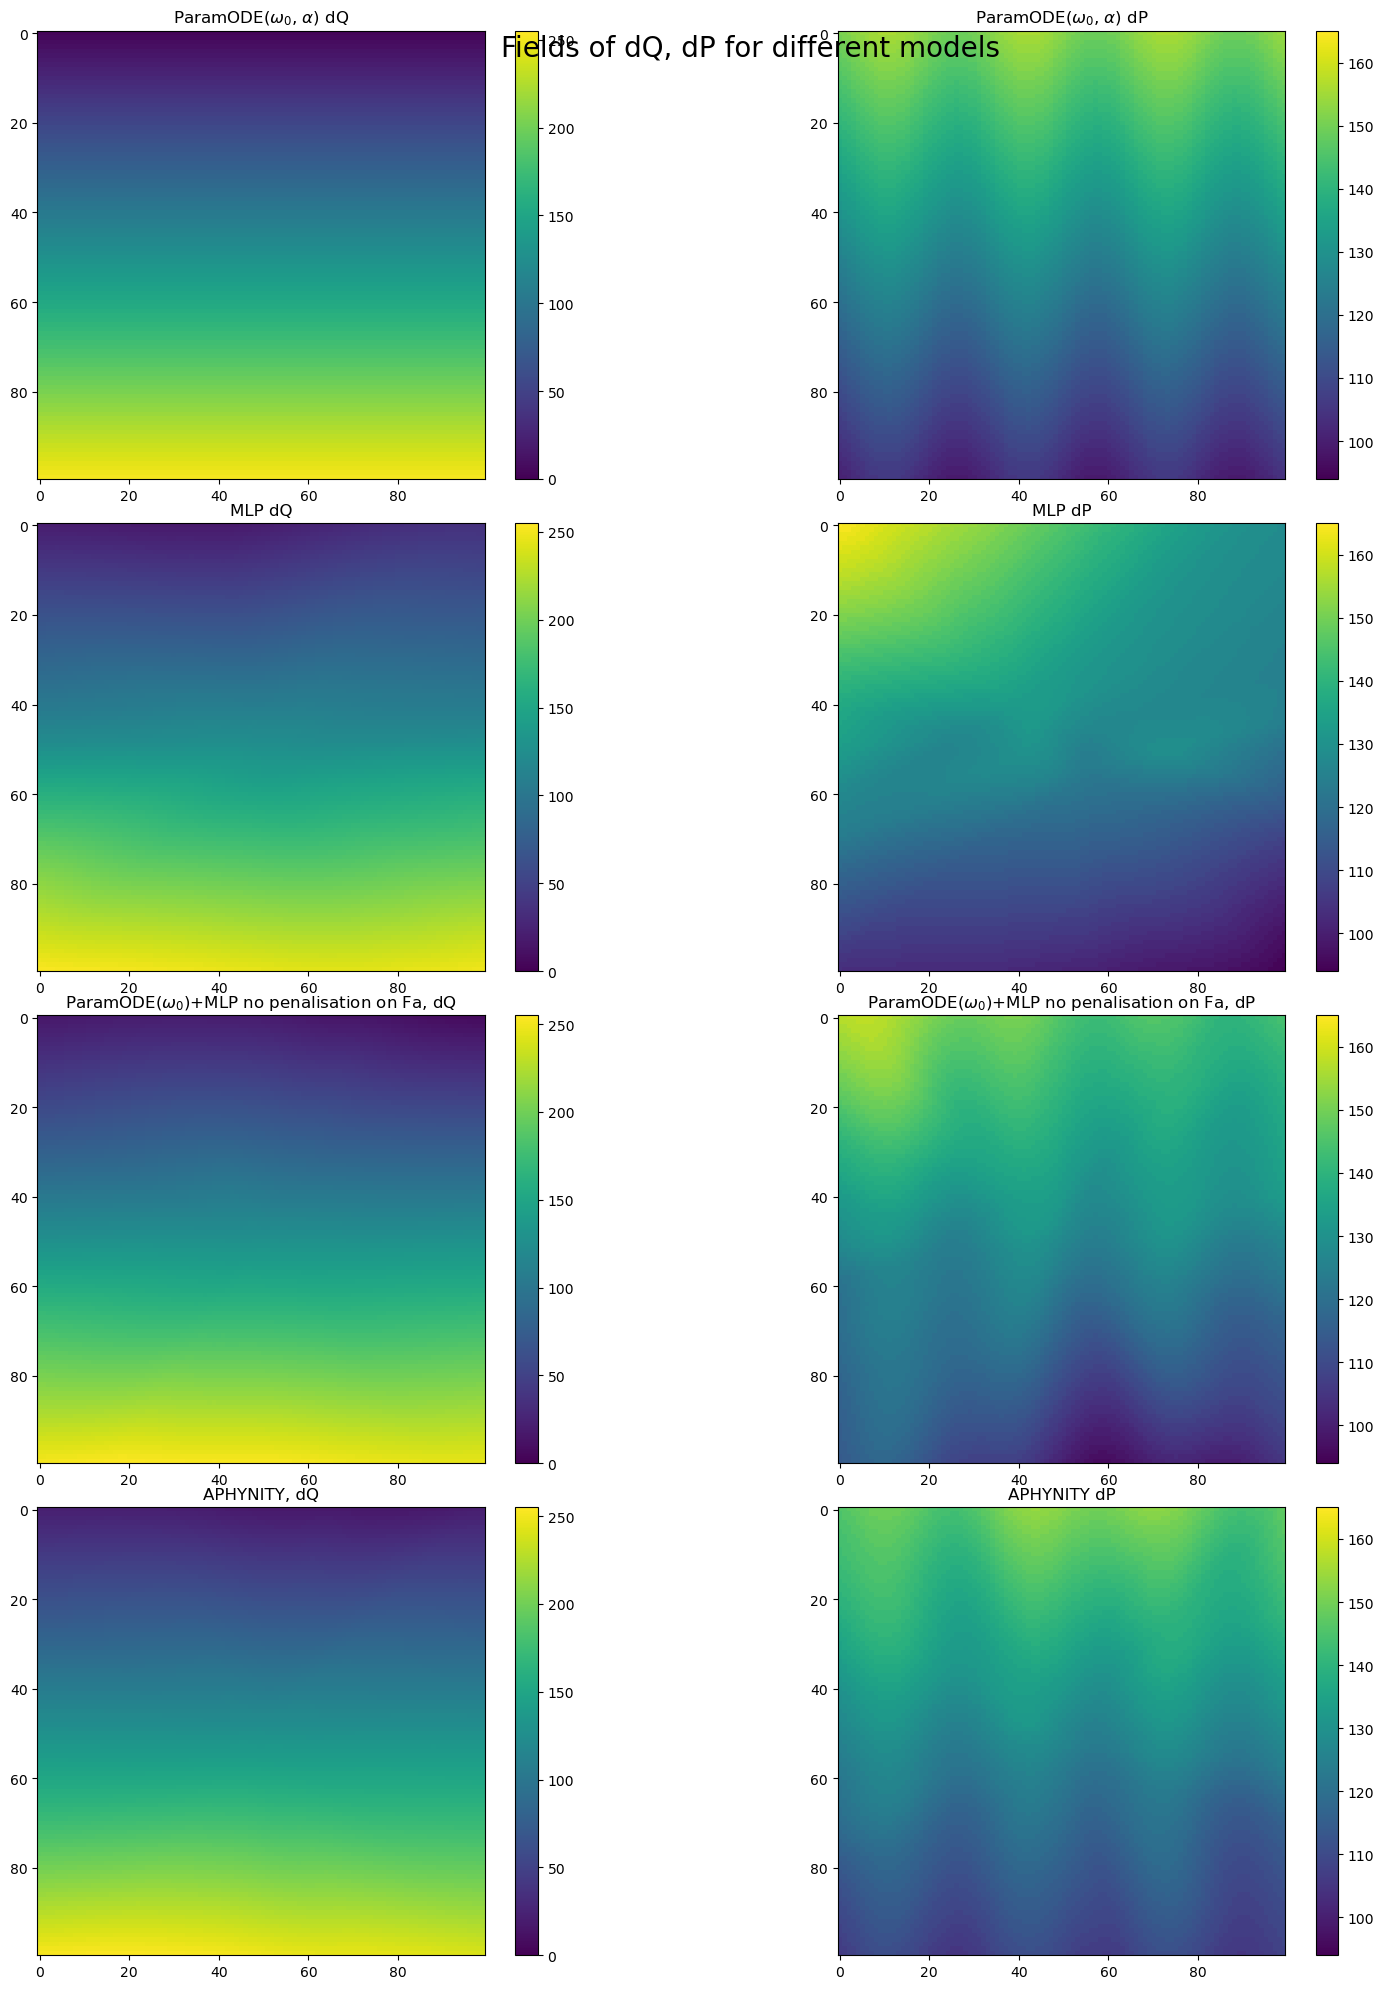

In [104]:

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(4, 2, figsize=(20, 20))

# Compute flows 
flow_comp = fz.convert_from_flow(np.stack([dQ, dP], axis=-1), mode='UV') #true
flow_inc = fz.convert_from_flow(np.stack([dQ_inc, dP_inc], axis=-1), mode='UV') #true incomplete
flow_pred = fz.convert_from_flow(np.stack([dQ_pred, dP_pred], axis=-1), mode='UV') #aphynity
flow_pred_mlp = fz.convert_from_flow(np.stack([dQ_pred_mlp, dP_pred_mlp], axis=-1), mode='UV') #mlp
flow_pred_nofa = fz.convert_from_flow(np.stack([dQ_pred_nofa, dP_pred_nofa], axis=-1), mode='UV') #sc2.2


vminQ, vmaxQ = min([np.min(flow_comp[..., 0]), np.min(flow_inc[..., 0]), np.min(flow_pred[..., 0]), np.min(flow_pred_mlp[..., 0]), np.min(flow_pred_nofa[..., 0])]), \
                max([np.max(flow_comp[..., 0]), np.max(flow_inc[..., 0]), np.max(flow_pred[..., 0]), np.max(flow_pred_mlp[..., 0]), np.max(flow_pred_nofa[..., 0])])

vminP, vmaxP = min([np.min(flow_comp[..., 1]), np.min(flow_inc[..., 1]), np.min(flow_pred[..., 1]), np.min(flow_pred_mlp[..., 1]), np.min(flow_pred_nofa[..., 1])]), \
                max([np.max(flow_comp[..., 1]), np.max(flow_inc[..., 1]), np.max(flow_pred[..., 1]), np.max(flow_pred_mlp[..., 1]), np.max(flow_pred_nofa[..., 1])])


### True incomplete dynamics
im1 = ax[0, 0].imshow(flow_comp[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[0, 1].imshow(flow_comp[..., 1], vmin=vminP, vmax=vmaxP)
ax[0, 0].set_title(r'ParamODE($\omega_0$, $\alpha$) dQ')
ax[0, 1].set_title(r'ParamODE($\omega_0$, $\alpha$) dP')
plt.colorbar(im1, ax=ax[0,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[0,1], fraction=0.046, pad=0.04)  # Add colorbar

plt.tight_layout()

### MLP alone
im1 = ax[1, 0].imshow(flow_pred_mlp[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[1, 1].imshow(flow_pred_mlp[..., 1], vmin=vminP, vmax=vmaxP)
ax[1, 0].set_title(r'MLP dQ')
ax[1, 1].set_title('MLP dP')
plt.colorbar(im1, ax=ax[1,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[1,1], fraction=0.046, pad=0.04)  # Add colorbar

### SC2.2
im1 = ax[2, 0].imshow(flow_pred_nofa[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[2, 1].imshow(flow_pred_nofa[..., 1], vmin=vminP, vmax=vmaxP)
ax[2, 0].set_title(r'ParamODE($\omega_0$)+MLP no penalisation on Fa, dQ')
ax[2, 1].set_title(r'ParamODE($\omega_0$)+MLP no penalisation on Fa, dP')
plt.colorbar(im1, ax=ax[2,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[2,1], fraction=0.046, pad=0.04)  #

### APHYNITY
im1 = ax[3, 0].imshow(flow_pred[..., 0], vmin=vminQ, vmax=vmaxQ)
im2 = ax[3, 1].imshow(flow_pred[..., 1], vmin=vminP, vmax=vmaxP)
ax[3, 0].set_title(r'APHYNITY, dQ')
ax[3, 1].set_title('APHYNITY dP')
plt.colorbar(im1, ax=ax[3,0], fraction=0.046, pad=0.04)  # Add colorbar
plt.colorbar(im2, ax=ax[3,1], fraction=0.046, pad=0.04)  #
fig.subplots_adjust(right=0.8)

#fig.suptitle("Fields of dQ, dP for different models", fontsize=20)
plt.show()

